📊 Modeling Guide – Where to Start

🎯 1. Problem Summary
- Task: Binary classification
- Target: oks_target_variable (whether patient improvement > 7 points)
- Class Imbalance: ~5:1 ratio (majority class dominates)
- Data: Fully preprocessed, no missing values, ready for modeling

🔧 2. Handling Class Imbalance
- You have several options:
✅ Option A: Class Weights (Recommended first approach)

- Use class_weight='balanced' in your classifier
- No need to modify data
- Works with: LogisticRegression, RandomForest, XGBoost, etc.

✅ Option B: Resampling (SMOTE)

- Apply SMOTE only to training data inside cross-validation
- Use imblearn.pipeline.Pipeline to prevent data leakage
- Best for smaller datasets

✅ Option C: Threshold Tuning

- Train normally, then adjust decision threshold
- Optimize for your preferred metric (F1, recall, precision)


📈 3. Evaluation Metrics
Given class imbalance, DO NOT rely solely on accuracy. Focus on:
Primary Metrics

- F1-Score (balance between precision and recall)
- ROC-AUC (overall discrimination ability)
- Precision-Recall AUC (better for imbalanced data)

Secondary Metrics

- Recall (if you want to catch all positive cases)
- Precision (if false positives are costly)
- Confusion Matrix (understand errors)


🧪 4. Model Selection Strategy
Baseline Models (Start here)

- Logistic Regression (class_weight='balanced')
- Random Forest (class_weight='balanced')
- Dummy Classifier (minimum performance)

Advanced Models (After baseline)

- XGBoost or LightGBM (handle categorical features well)
- CatBoost (native categorical support)
- Ensemble methods (stacking, voting)


🔄 5. Cross-Validation Strategy

- Use StratifiedKFold (5–10 folds)
- Maintains class distribution in each fold
- Report mean ± std of metrics

Important:

- If using SMOTE, apply it inside each CV fold
- Use imblearn.pipeline.Pipeline to prevent leakage


🎛️ 6. Hyperparameter Tuning
- Step 1: Train baseline models with default parameters
- Step 2: Use GridSearchCV or RandomizedSearchCV
- Step 3: Focus on models that performed best in baseline
Key Parameters to Tune
Random Forest
- Plain Textn_estimators: [100, 200, 500]max_depth: [10, 20, None]min_samples_split: [2, 5, 10]class_weight: ['balanced']Show more lines
XGBoost
- Plain Textn_estimators: [100, 200, 500]learning_rate: [0.01, 0.1, 0.3]max_depth: [3, 5, 7]scale_pos_weight: [calculated from class ratio]Show more lines

📊 7. Feature Engineering (Optional)

Feature Interactions:
- Example: age_band * heart_disease
Feature Selection:
- Use feature importance from tree-based models
- Try Recursive Feature Elimination (RFE)
Categorical Encoding:

- One-Hot Encoding for low-cardinality features
- Target Encoding for high-cardinality features (e.g., provider_code)

⚠️ 8. Important Reminders
- ✅ Use stratified cross-validation
- ✅ Focus on F1/ROC-AUC, not just accuracy
- ✅ Handle class imbalance (class weights or SMOTE)
- ✅ Evaluate on test set ONLY ONCE at the end
- ✅ Save your best model with joblib
- ❌ Touch the test set during model development
- ❌ Use SMOTE before train-test split
- ❌ Rely on accuracy alone for imbalanced data
- ❌ Forget to set random_state for reproducibility
- ❌ Oversample test data

# Encoded data

In [2]:
# Load encoded data
import pandas as pd
X_train_final_encoded = pd.read_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet').squeeze()
print("✓ Encoded data loaded successfully")

✓ Encoded data loaded successfully


In [4]:
X_train_final_encoded.head(5)

,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_disability,heart_disease,high_bp,stroke,circulation,...,t0_living_arrangements_2.0,t0_living_arrangements_4.0,Region_East of England,Region_London,Region_North East,Region_North West,Region_South East,Region_South West,Region_West Midlands,Region_Yorkshire and The Humber
0,0.0,0.0,0,2.0,0.0,0.0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0,3.0,0.0,1.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0,2.0,0.0,0.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [5]:
X_train_final_encoded.columns.tolist()

['gender',
 't0_assisted',
 't0_assisted_by',
 't0_symptom_period',
 't0_previous_surgery',
 't0_disability',
 'heart_disease',
 'high_bp',
 'stroke',
 'circulation',
 'lung_disease',
 'diabetes',
 'kidney_disease',
 'nervous_system',
 'liver_disease',
 'cancer',
 'depression',
 'arthritis',
 't0_mobility',
 't0_self_care',
 't0_activity',
 't0_discomfort',
 't0_anxiety',
 'oks_t0_pain',
 'oks_t0_night_pain',
 'oks_t0_washing',
 'oks_t0_transport',
 'oks_t0_walking',
 'oks_t0_standing',
 'oks_t0_limping',
 'oks_t0_kneeling',
 'oks_t0_work',
 'oks_t0_confidence',
 'oks_t0_shopping',
 'oks_t0_stairs',
 'oks_t0_score',
 'University Hospital',
 'independent_hospital',
 'comorbidity_count',
 'oks_pain_subscale',
 'oks_function_subscale',
 'oks_adl_subscale',
 'year_2017/18',
 'year_2018/19',
 'age_band_3',
 'age_band_4',
 'age_band_5',
 't0_living_arrangements_2.0',
 't0_living_arrangements_4.0',
 'Region_East of England',
 'Region_London',
 'Region_North East',
 'Region_North West',
 'Regi

Correlation matrix shape: (57, 57)

Highest correlations with each variable (top 5):

gender:
  oks_t0_kneeling: 0.338
  oks_t0_shopping: 0.192
  oks_t0_score: 0.190
  oks_function_subscale: 0.176
  oks_adl_subscale: 0.171

t0_assisted:
  t0_self_care: 0.173
  age_band_5: 0.173
  t0_disability: 0.136
  t0_discomfort: 0.124
  t0_anxiety: 0.119

t0_assisted_by:
  gender: nan
  t0_assisted: nan
  t0_symptom_period: nan
  t0_previous_surgery: nan
  t0_disability: nan

t0_symptom_period:
  age_band_3: 0.090
  gender: 0.080
  arthritis: 0.060
  t0_disability: 0.034
  comorbidity_count: 0.027

t0_previous_surgery:
  circulation: 0.032
  independent_hospital: 0.024
  oks_t0_limping: 0.024
  Region_London: 0.018
  year_2017/18: 0.016

t0_disability:
  t0_self_care: 0.302
  t0_activity: 0.241
  t0_discomfort: 0.240
  t0_anxiety: 0.223
  t0_mobility: 0.199

heart_disease:
  comorbidity_count: 0.344
  circulation: 0.096
  gender: 0.086
  high_bp: 0.080
  stroke: 0.075

high_bp:
  comorbidity_count

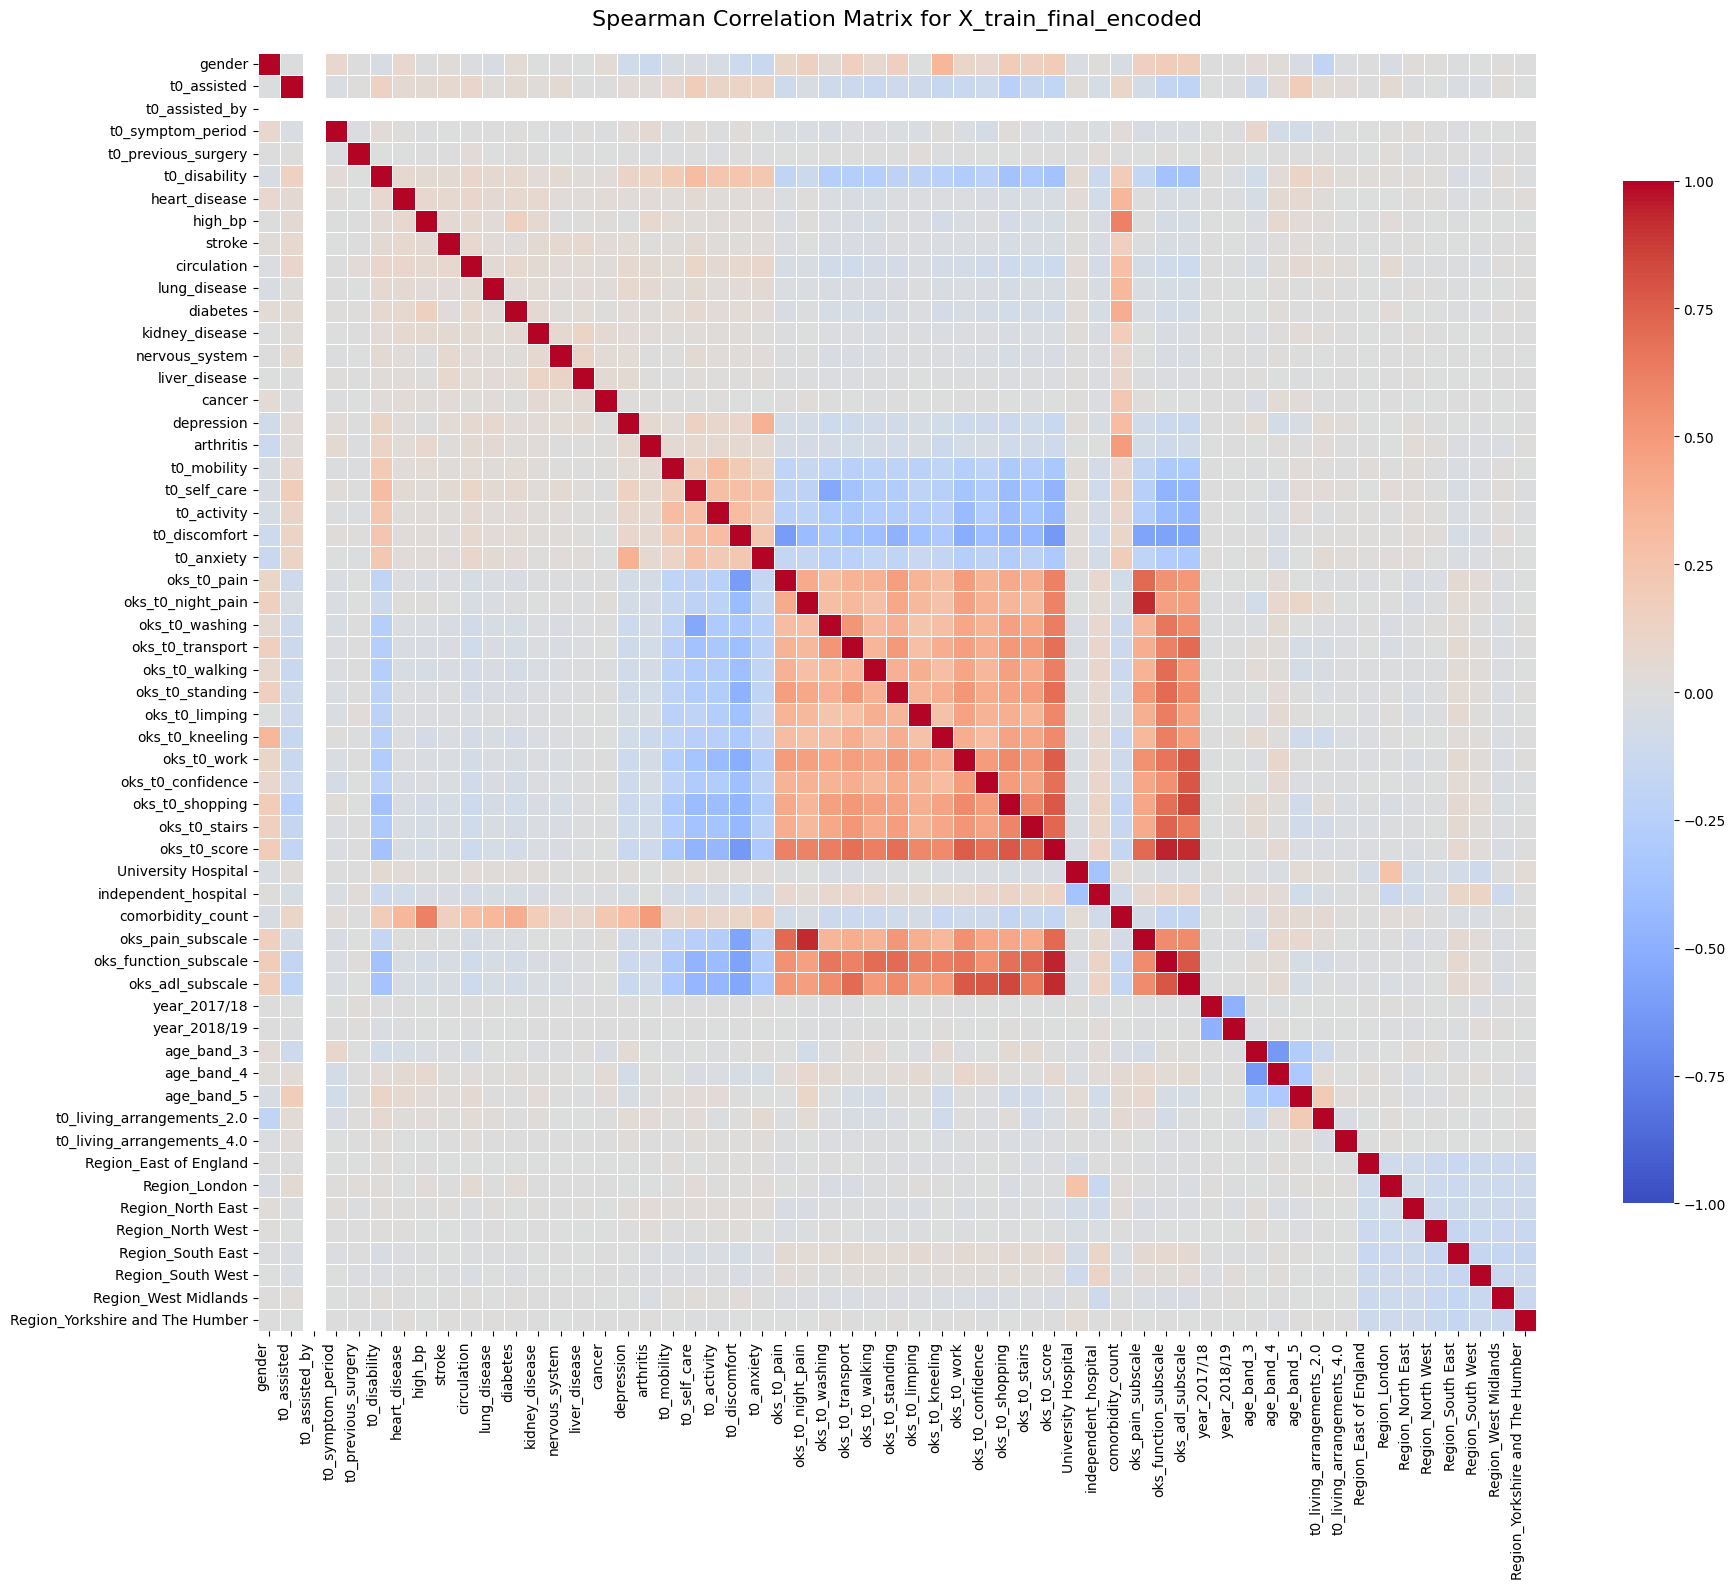


Highly correlated variable pairs (|correlation| > 0.7):
oks_t0_score <-> oks_function_subscale: 0.940
oks_t0_score <-> oks_adl_subscale: 0.924
oks_t0_night_pain <-> oks_pain_subscale: 0.923
oks_t0_shopping <-> oks_adl_subscale: 0.842
oks_function_subscale <-> oks_adl_subscale: 0.787
oks_t0_confidence <-> oks_adl_subscale: 0.785
oks_t0_shopping <-> oks_t0_score: 0.778
oks_t0_work <-> oks_adl_subscale: 0.775
oks_t0_work <-> oks_t0_score: 0.765
oks_t0_stairs <-> oks_function_subscale: 0.742
oks_t0_stairs <-> oks_t0_score: 0.725
oks_t0_pain <-> oks_pain_subscale: 0.714
oks_t0_score <-> oks_pain_subscale: 0.712
oks_t0_transport <-> oks_adl_subscale: 0.706
oks_t0_standing <-> oks_function_subscale: 0.704

Correlation Summary Statistics:
Mean absolute correlation: 0.094
Median absolute correlation: 0.028
Max correlation: 0.940
Min correlation: -0.630
Std of correlations: 0.179


In [6]:
# Correlation Analysis for X_train_final_encoded
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate Spearman correlation (works well with both continuous and binary variables)
correlation_matrix = X_train_final_encoded.corr(method='spearman')

print(f"Correlation matrix shape: {correlation_matrix.shape}")
print(f"\nHighest correlations with each variable (top 5):")
print("=" * 80)

# For each variable, show top 5 correlations (excluding self-correlation)
for col in X_train_final_encoded.columns[:10]:  # Show first 10 variables as example
    correlations = correlation_matrix[col].sort_values(ascending=False)
    # Exclude self-correlation
    top_correlations = correlations[correlations.index != col].head(5)
    print(f"\n{col}:")
    for idx, val in top_correlations.items():
        print(f"  {idx}: {val:.3f}")

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=False,  # Set to True if you want to see values (may be cluttered with 45 features)
            cmap='coolwarm', 
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Spearman Correlation Matrix for X_train_final_encoded', fontsize=16, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find highly correlated pairs (|correlation| > 0.7)
print("\n" + "=" * 80)
print("Highly correlated variable pairs (|correlation| > 0.7):")
print("=" * 80)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
        print(f"{pair['var1']} <-> {pair['var2']}: {pair['correlation']:.3f}")
else:
    print("No highly correlated pairs found (threshold = 0.7)")

# Summary statistics about correlations
print("\n" + "=" * 80)
print("Correlation Summary Statistics:")
print("=" * 80)
# Get upper triangle of correlation matrix (excluding diagonal)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
upper_triangle = correlation_matrix.where(mask)
all_correlations = upper_triangle.values.flatten()
all_correlations = all_correlations[~np.isnan(all_correlations)]

print(f"Mean absolute correlation: {np.abs(all_correlations).mean():.3f}")
print(f"Median absolute correlation: {np.median(np.abs(all_correlations)):.3f}")
print(f"Max correlation: {all_correlations.max():.3f}")
print(f"Min correlation: {all_correlations.min():.3f}")
print(f"Std of correlations: {all_correlations.std():.3f}")

# Logistic Regression Testing 

RUNNING ALL MODEL CONFIGURATIONS

▶ Training: LR - No weights...
  ✓ Val PR-AUC: 0.3728 | Gap: 0.0017 | Features: 56

▶ Training: LR - Balanced weights...
  ✓ Val PR-AUC: 0.3700 | Gap: 0.0015 | Features: 56

▶ Training: LR - SMOTE...


/Users/josschaffers/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/josschaffers/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/josschaffers/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/josschaffers

  ✓ Val PR-AUC: 0.3700 | Gap: 0.0017 | Features: 56

▶ Training: LR - LASSO (L1)...
  ✓ Val PR-AUC: 0.3728 | Gap: 0.0017 | Features: 54

▶ Training: LR - LASSO + Balanced...
  ✓ Val PR-AUC: 0.3701 | Gap: 0.0015 | Features: 54

OVERFITTING ANALYSIS (@ Threshold=0.5)
                       train_precision  val_precision  precision_gap  train_recall  val_recall  recall_gap overfit_flag
LR - No weights                 0.6554         0.6609        -0.0056        0.0799      0.0804     -0.0005         ✓ OK
LR - Balanced weights           0.2894         0.2882         0.0012        0.6059      0.6027      0.0032         ✓ OK
LR - SMOTE                      0.6442         0.6485        -0.0043        0.0808      0.0814     -0.0006         ✓ OK
LR - LASSO (L1)                 0.6558         0.6617        -0.0059        0.0799      0.0803     -0.0005         ✓ OK
LR - LASSO + Balanced           0.2894         0.2881         0.0013        0.6058      0.6026      0.0033         ✓ OK

VALIDATION PR

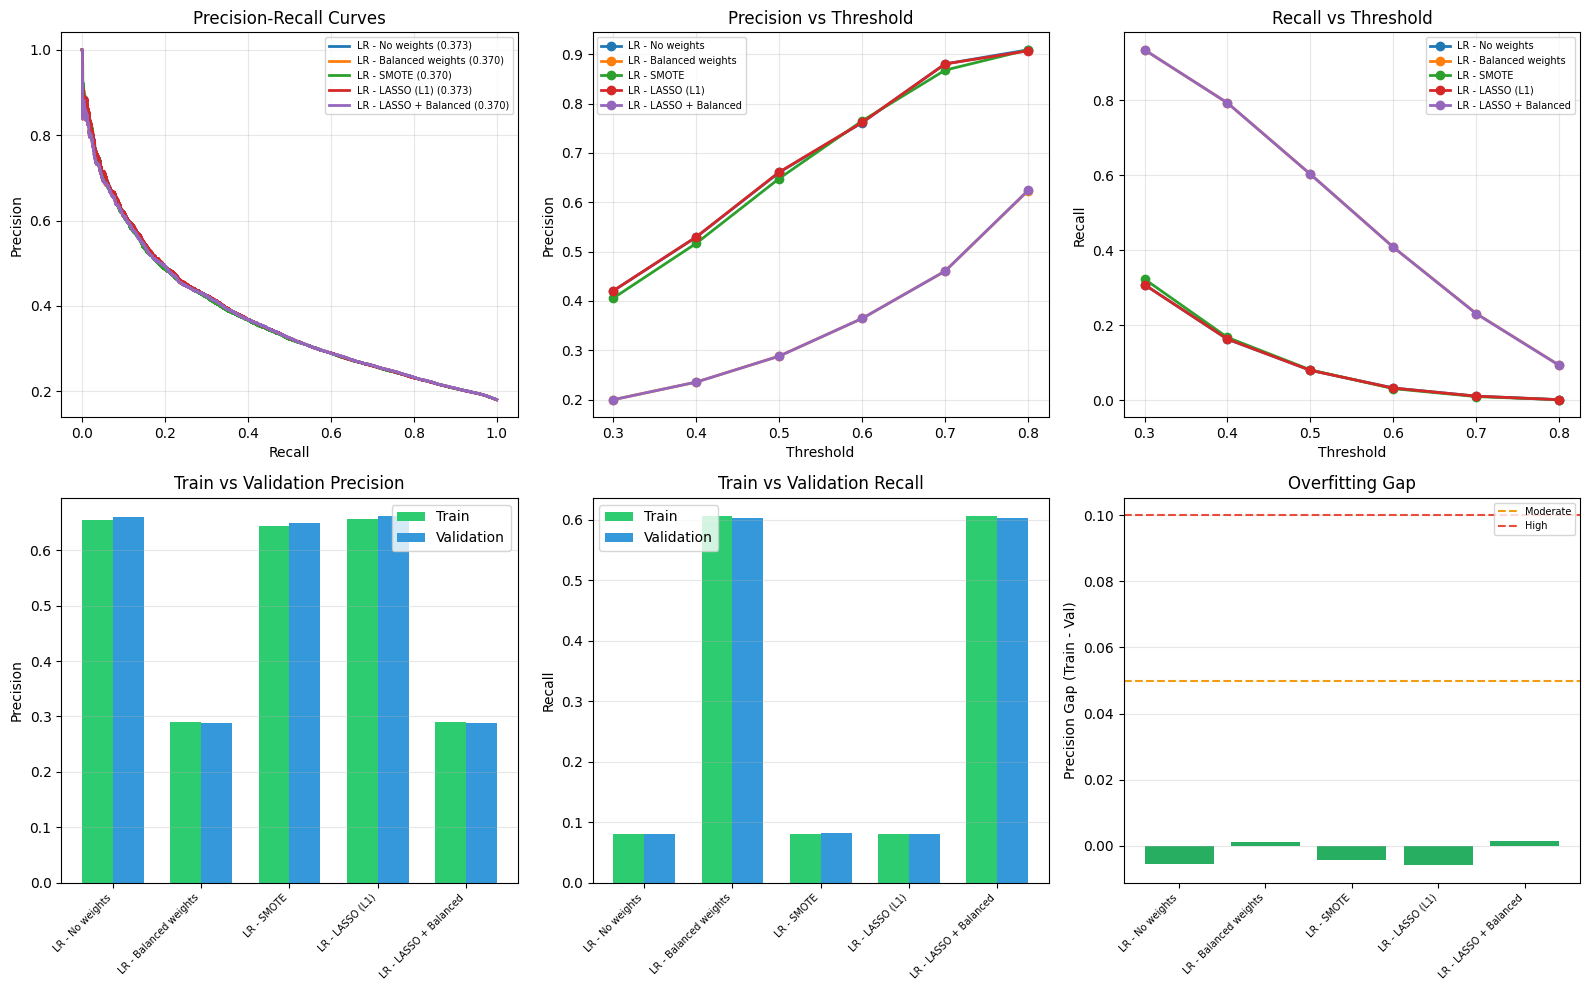

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define model configurations
models = {
    'LR - No weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1
    ),
    'LR - Balanced weights': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1, class_weight='balanced'
    ),
    'LR - SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1))
    ]),
    'LR - LASSO (L1)': LogisticRegression(
        max_iter=1000, random_state=42, solver='saga', penalty='l1', n_jobs=-1
    ),
    'LR - LASSO + Balanced': LogisticRegression(
        max_iter=1000, random_state=42, solver='saga', penalty='l1', n_jobs=-1, class_weight='balanced'
    ),
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Store results
results = {}
overfit_results = {}
proba_dict = {}
feature_importance_dict = {}

# Feature names
feature_names = X_train_final_encoded.columns.tolist()

print("=" * 80)
print("RUNNING ALL MODEL CONFIGURATIONS")
print("=" * 80)

for name, model in models.items():
    print(f"\n▶ Training: {name}...")
    
    # Storage for cross-validation
    val_probas = np.zeros(len(y_train))
    train_precisions, val_precisions = [], []
    train_recalls, val_recalls = [], []
    train_pr_aucs, val_pr_aucs = [], []
    fold_coefs = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_final_encoded, y_train)):
        X_tr, X_val = X_train_final_encoded.iloc[train_idx], X_train_final_encoded.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Clone and fit model
        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        
        # Extract coefficients
        if hasattr(model_clone, 'coef_'):
            fold_coefs.append(model_clone.coef_[0])
        elif hasattr(model_clone, 'named_steps'):
            fold_coefs.append(model_clone.named_steps['lr'].coef_[0])
        
        # Get probabilities
        train_proba = model_clone.predict_proba(X_tr)[:, 1]
        val_proba = model_clone.predict_proba(X_val)[:, 1]
        val_probas[val_idx] = val_proba
        
        # Metrics at threshold=0.5
        train_pred = (train_proba >= 0.5).astype(int)
        val_pred = (val_proba >= 0.5).astype(int)
        
        train_precisions.append(precision_score(y_tr, train_pred, zero_division=0))
        val_precisions.append(precision_score(y_val, val_pred, zero_division=0))
        train_recalls.append(recall_score(y_tr, train_pred, zero_division=0))
        val_recalls.append(recall_score(y_val, val_pred, zero_division=0))
        
        # PR-AUC
        prec_tr, rec_tr, _ = precision_recall_curve(y_tr, train_proba)
        prec_val, rec_val, _ = precision_recall_curve(y_val, val_proba)
        train_pr_aucs.append(auc(rec_tr, prec_tr))
        val_pr_aucs.append(auc(rec_val, prec_val))
    
    proba_dict[name] = val_probas
    
    # Average coefficients across folds
    avg_coefs = np.mean(fold_coefs, axis=0)
    feature_importance_dict[name] = pd.DataFrame({
        'feature': feature_names,
        'coefficient': avg_coefs,
        'abs_importance': np.abs(avg_coefs)
    }).sort_values('abs_importance', ascending=False)
    
    # Store metrics
    overfit_results[name] = {
        'train_precision': np.mean(train_precisions),
        'val_precision': np.mean(val_precisions),
        'precision_gap': np.mean(train_precisions) - np.mean(val_precisions),
        'train_recall': np.mean(train_recalls),
        'val_recall': np.mean(val_recalls),
        'recall_gap': np.mean(train_recalls) - np.mean(val_recalls),
        'train_pr_auc': np.mean(train_pr_aucs),
        'val_pr_auc': np.mean(val_pr_aucs),
        'pr_auc_gap': np.mean(train_pr_aucs) - np.mean(val_pr_aucs),
        'n_nonzero_features': np.sum(np.abs(avg_coefs) > 1e-6)
    }
    
    # Metrics at each threshold
    model_results = []
    for thresh in thresholds:
        y_pred = (val_probas >= thresh).astype(int)
        model_results.append({
            'threshold': thresh,
            'precision': precision_score(y_train, y_pred, zero_division=0),
            'recall': recall_score(y_train, y_pred, zero_division=0),
            'f1': f1_score(y_train, y_pred, zero_division=0),
            'n_predicted_pos': y_pred.sum()
        })
    
    results[name] = pd.DataFrame(model_results)
    print(f"  ✓ Val PR-AUC: {overfit_results[name]['val_pr_auc']:.4f} | Gap: {overfit_results[name]['pr_auc_gap']:.4f} | Features: {overfit_results[name]['n_nonzero_features']}")

# === OVERFITTING TABLE ===
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS (@ Threshold=0.5)")
print("=" * 80)

overfit_df = pd.DataFrame(overfit_results).T
overfit_df['overfit_flag'] = overfit_df['precision_gap'].apply(
    lambda x: '⚠️ HIGH' if x > 0.1 else ('⚡ MOD' if x > 0.05 else '✓ OK')
)
print(overfit_df[['train_precision', 'val_precision', 'precision_gap', 
                   'train_recall', 'val_recall', 'recall_gap', 'overfit_flag']].round(4).to_string())

# === THRESHOLD TABLES ===
print("\n" + "=" * 80)
print("VALIDATION PRECISION ACROSS THRESHOLDS")
print("=" * 80)

comparison_df = pd.DataFrame()
for name, df in results.items():
    comparison_df[name] = df.set_index('threshold')['precision']
print(comparison_df.round(4).to_string())

print("\n" + "=" * 80)
print("VALIDATION RECALL ACROSS THRESHOLDS")
print("=" * 80)

recall_df = pd.DataFrame()
for name, df in results.items():
    recall_df[name] = df.set_index('threshold')['recall']
print(recall_df.round(4).to_string())

# === FEATURE IMPORTANCE FOR EACH MODEL ===
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE (TOP 15 PER MODEL)")
print("=" * 80)

for name, fi_df in feature_importance_dict.items():
    print(f"\n{'─' * 60}")
    print(f"📊 {name}")
    print(f"{'─' * 60}")
    top_15 = fi_df.head(15).reset_index(drop=True)
    top_15.index = top_15.index + 1  # Start from 1
    print(top_15[['feature', 'coefficient', 'abs_importance']].to_string())
    
    if 'LASSO' in name:
        n_zero = (fi_df['abs_importance'] < 1e-6).sum()
        n_kept = len(fi_df) - n_zero
        print(f"\n  → LASSO kept {n_kept}/{len(fi_df)} features (eliminated {n_zero})")

# === PLOTS ===
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: PR Curves
ax1 = axes[0, 0]
for name, y_proba in proba_dict.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_train, y_proba)
    pr_auc = auc(rec_curve, prec_curve)
    ax1.plot(rec_curve, prec_curve, label=f'{name} ({pr_auc:.3f})', linewidth=2)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curves')
ax1.legend(loc='best', fontsize=7)
ax1.grid(True, alpha=0.3)

# Plot 2: Precision vs Threshold
ax2 = axes[0, 1]
for name, df in results.items():
    ax2.plot(df['threshold'], df['precision'], marker='o', label=name, linewidth=2)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Precision')
ax2.set_title('Precision vs Threshold')
ax2.legend(loc='best', fontsize=7)
ax2.grid(True, alpha=0.3)

# Plot 3: Recall vs Threshold
ax3 = axes[0, 2]
for name, df in results.items():
    ax3.plot(df['threshold'], df['recall'], marker='o', label=name, linewidth=2)
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Recall')
ax3.set_title('Recall vs Threshold')
ax3.legend(loc='best', fontsize=7)
ax3.grid(True, alpha=0.3)

# Plot 4: Train vs Val Precision
ax4 = axes[1, 0]
x_pos = np.arange(len(overfit_results))
width = 0.35
train_prec = [v['train_precision'] for v in overfit_results.values()]
val_prec = [v['val_precision'] for v in overfit_results.values()]
ax4.bar(x_pos - width/2, train_prec, width, label='Train', color='#2ecc71')
ax4.bar(x_pos + width/2, val_prec, width, label='Validation', color='#3498db')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax4.set_ylabel('Precision')
ax4.set_title('Train vs Validation Precision')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Train vs Val Recall
ax5 = axes[1, 1]
train_rec = [v['train_recall'] for v in overfit_results.values()]
val_rec = [v['val_recall'] for v in overfit_results.values()]
ax5.bar(x_pos - width/2, train_rec, width, label='Train', color='#2ecc71')
ax5.bar(x_pos + width/2, val_rec, width, label='Validation', color='#3498db')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax5.set_ylabel('Recall')
ax5.set_title('Train vs Validation Recall')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Overfitting Gap
ax6 = axes[1, 2]
gaps = [v['precision_gap'] for v in overfit_results.values()]
colors = ['#e74c3c' if g > 0.1 else '#f39c12' if g > 0.05 else '#27ae60' for g in gaps]
ax6.bar(x_pos, gaps, color=colors)
ax6.axhline(y=0.05, color='#f39c12', linestyle='--', label='Moderate')
ax6.axhline(y=0.1, color='#e74c3c', linestyle='--', label='High')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(list(overfit_results.keys()), rotation=45, ha='right', fontsize=7)
ax6.set_ylabel('Precision Gap (Train - Val)')
ax6.set_title('Overfitting Gap')
ax6.legend(fontsize=7)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

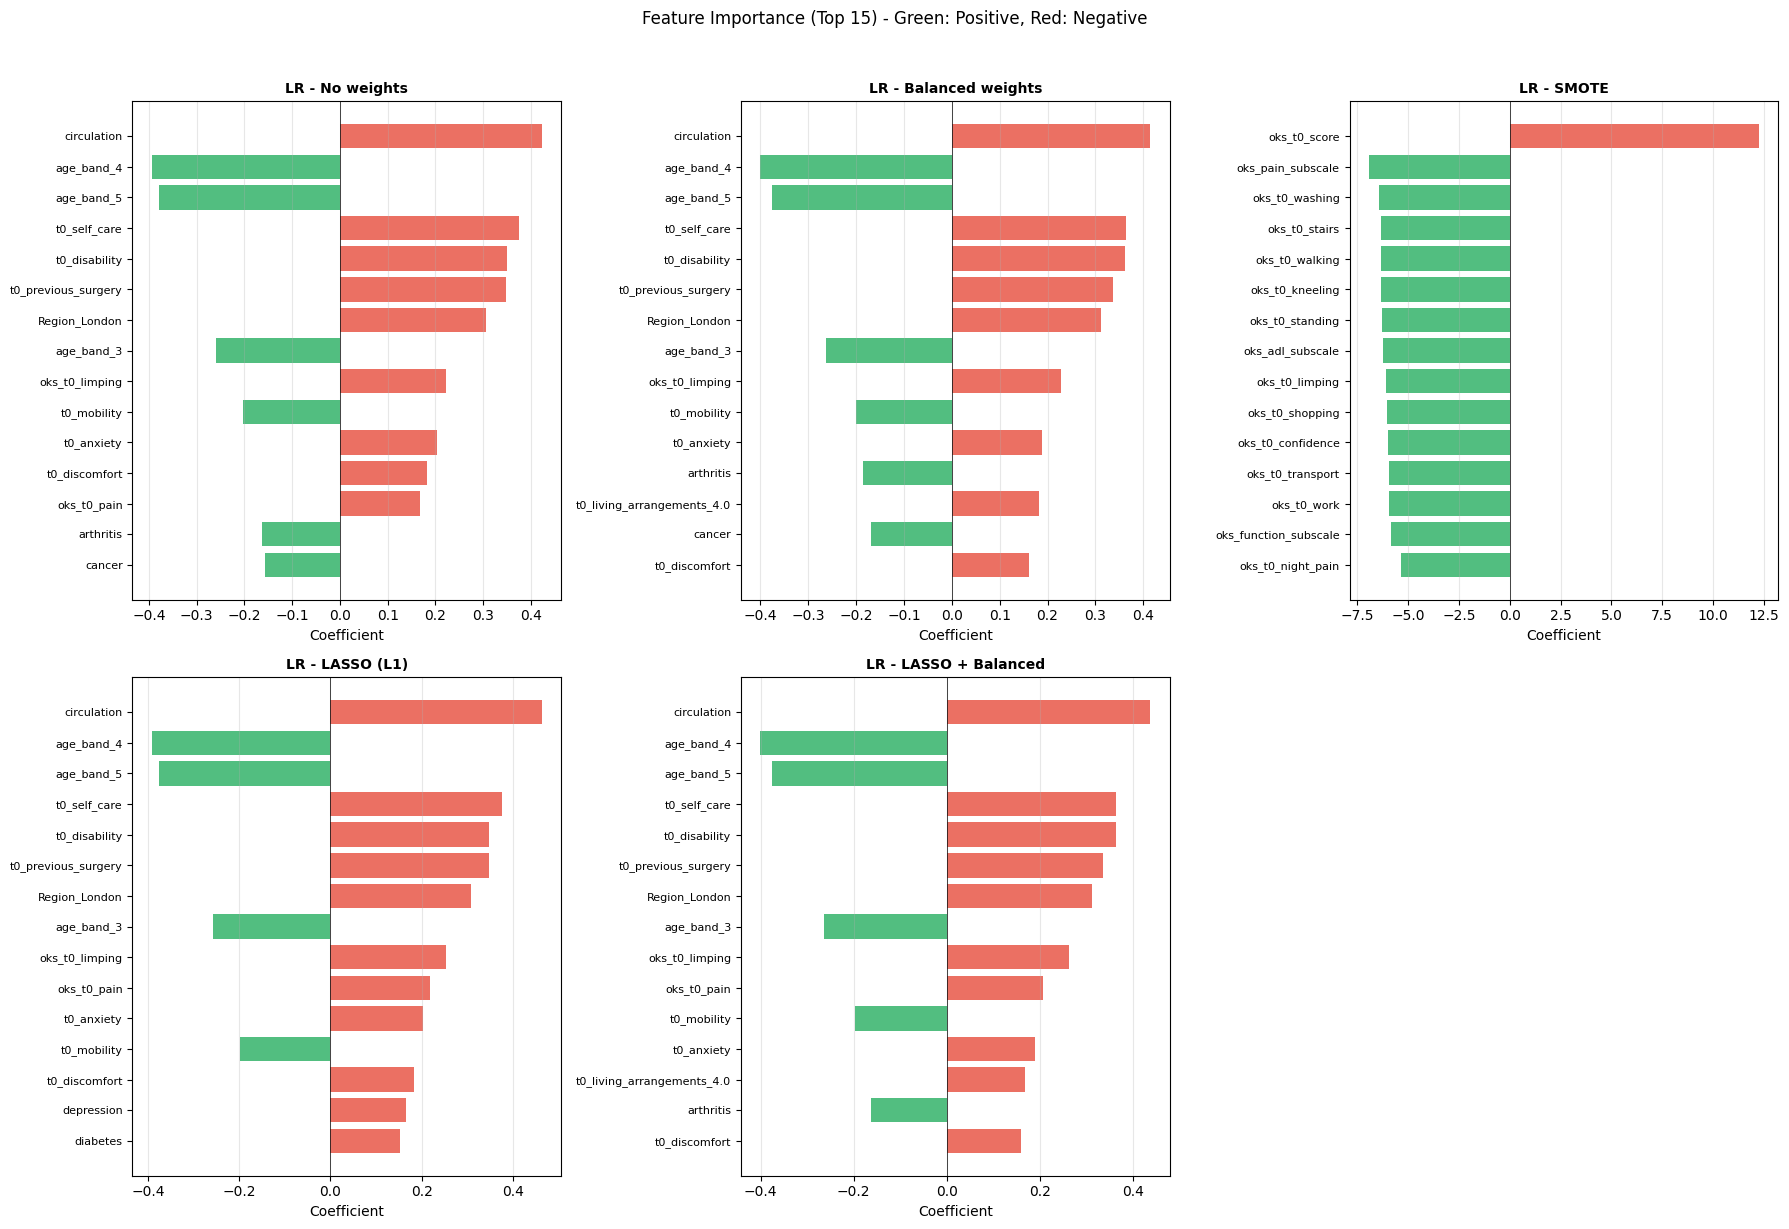


SUMMARY

Best Precision at each threshold:
  0.3: LR - LASSO (L1) → 0.4206
  0.4: LR - LASSO (L1) → 0.5298
  0.5: LR - LASSO (L1) → 0.6612
  0.6: LR - SMOTE → 0.7649
  0.7: LR - No weights → 0.8805
  0.8: LR - No weights → 0.9091

Lowest Overfitting Risk:
  LR - LASSO (L1): gap=-0.0059
  LR - No weights: gap=-0.0056
  LR - SMOTE: gap=-0.0043


In [ ]:
# === FEATURE IMPORTANCE PLOTS ===
n_models = len(feature_importance_dict)
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12))
axes2 = axes2.flatten()

for idx, (name, fi_df) in enumerate(feature_importance_dict.items()):
    ax = axes2[idx]
    top_15 = fi_df.head(15)
    colors = ['#27ae60' if c < 0 else '#e74c3c' for c in top_15['coefficient']]
    y_pos = np.arange(len(top_15))
    ax.barh(y_pos, top_15['coefficient'], color=colors, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_15['feature'], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Coefficient')
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')

axes2[5].axis('off')  # Hide empty subplot
plt.suptitle('Feature Importance (Top 15) - Green: Positive, Red: Negative', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# === SUMMARY ===
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print("\nBest Precision at each threshold:")
for thresh in thresholds:
    best_model = comparison_df.loc[thresh].idxmax()
    best_prec = comparison_df.loc[thresh].max()
    print(f"  {thresh}: {best_model} → {best_prec:.4f}")

print("\nLowest Overfitting Risk:")
sorted_by_gap = sorted(overfit_results.items(), key=lambda x: x[1]['precision_gap'])
for name, m in sorted_by_gap[:3]:
    print(f"  {name}: gap={m['precision_gap']:.4f}")


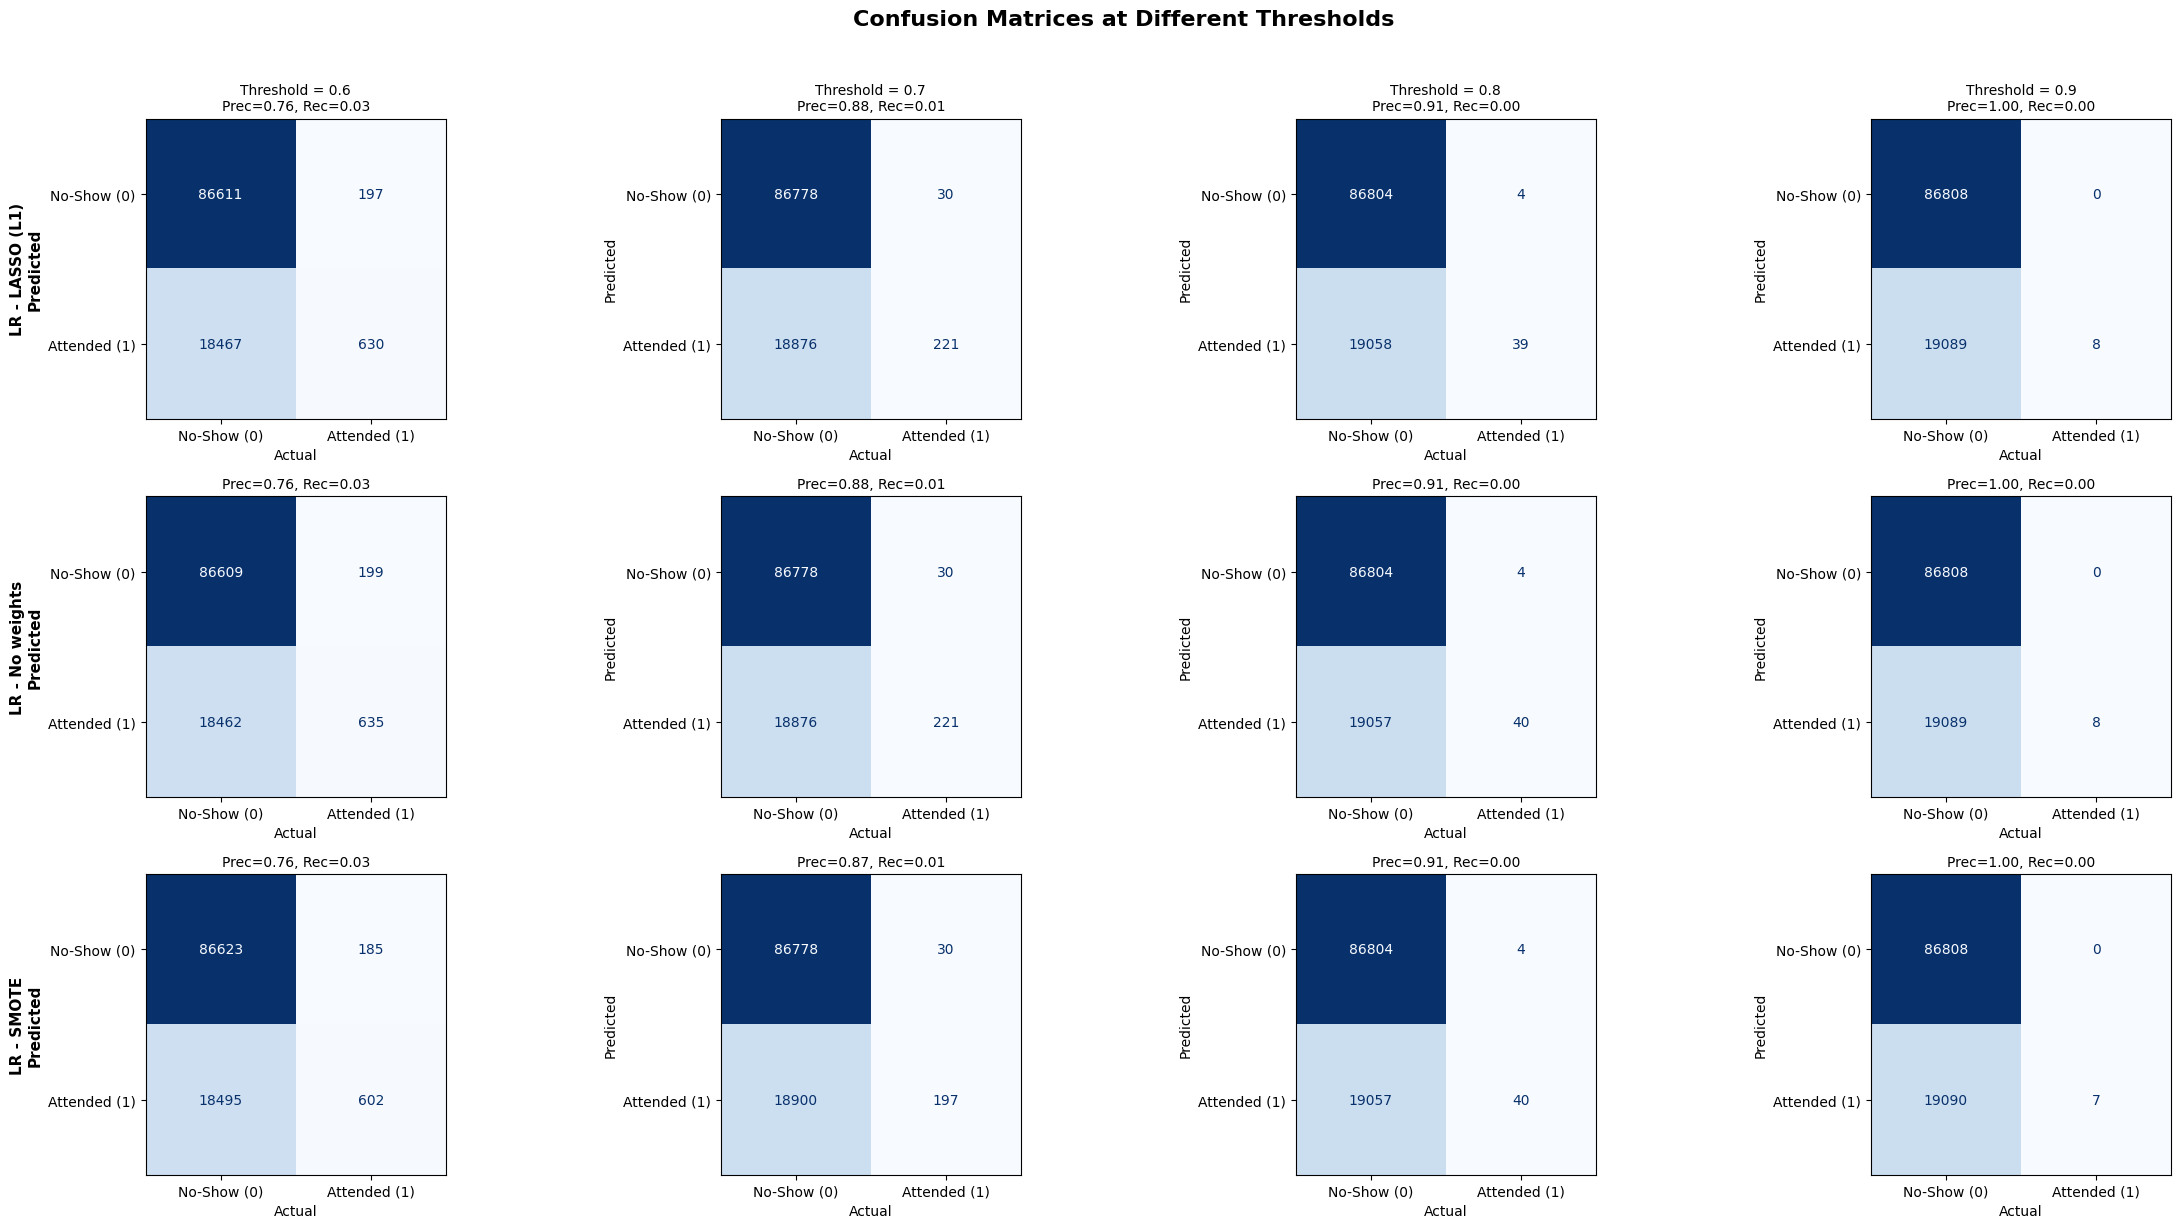


SUMMARY: Confusion Matrix Metrics at Different Thresholds

📊 LR - LASSO (L1)
----------------------------------------------------------------------
Threshold          TN       FP       FN       TP  Precision     Recall  Specificity
----------------------------------------------------------------------
0.6            86,611      197   18,467      630     0.7618     0.0330       0.9977
0.7            86,778       30   18,876      221     0.8805     0.0116       0.9997
0.8            86,804        4   19,058       39     0.9070     0.0020       1.0000
0.9            86,808        0   19,089        8     1.0000     0.0004       1.0000

📊 LR - No weights
----------------------------------------------------------------------
Threshold          TN       FP       FN       TP  Precision     Recall  Specificity
----------------------------------------------------------------------
0.6            86,609      199   18,462      635     0.7614     0.0333       0.9977
0.7            86,778       30 

In [ ]:
# Create confusion matrix at different thresholds for the these models: LR - LASSO (L1), LR - No weights, LR - SMOTE

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Models to analyze
selected_models = ['LR - LASSO (L1)', 'LR - No weights', 'LR - SMOTE']

# Thresholds to evaluate
thresholds = [0.6, 0.7, 0.8, 0.9]

# Create figure with subplots: rows = models, columns = thresholds
fig, axes = plt.subplots(len(selected_models), len(thresholds), figsize=(24, 12))
fig.suptitle('Confusion Matrices at Different Thresholds', fontsize=16, fontweight='bold', y=1.02)

for row, model_name in enumerate(selected_models):
    if model_name not in proba_dict:
        print(f"Warning: {model_name} not found in proba_dict")
        continue
    
    probas = proba_dict[model_name]
    
    for col, thresh in enumerate(thresholds):
        # Convert probabilities to predictions at this threshold
        y_pred = (probas >= thresh).astype(int)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_train, y_pred)
        
        # Plot confusion matrix
        ax = axes[row, col]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No-Show (0)', 'Attended (1)'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
        
        # Calculate metrics for title
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        if row == 0:
            ax.set_title(f'Threshold = {thresh}\nPrec={precision:.2f}, Rec={recall:.2f}', fontsize=10)
        else:
            ax.set_title(f'Prec={precision:.2f}, Rec={recall:.2f}', fontsize=10)
        
        if col == 0:
            ax.set_ylabel(f'{model_name}\nPredicted', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('Predicted')
        
        ax.set_xlabel('Actual')

plt.tight_layout()
#plt.savefig('../outputs/confusion_matrices_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("SUMMARY: Confusion Matrix Metrics at Different Thresholds")
print("="*80)

# Print summary table
for model_name in selected_models:
    if model_name not in proba_dict:
        continue
    
    print(f"\n📊 {model_name}")
    print("-" * 70)
    print(f"{'Threshold':<12} {'TN':>8} {'FP':>8} {'FN':>8} {'TP':>8} {'Precision':>10} {'Recall':>10} {'Specificity':>12}")
    print("-" * 70)
    
    probas = proba_dict[model_name]
    
    for thresh in thresholds:
        y_pred = (probas >= thresh).astype(int)
        cm = confusion_matrix(y_train, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"{thresh:<12.1f} {tn:>8,} {fp:>8,} {fn:>8,} {tp:>8,} {precision:>10.4f} {recall:>10.4f} {specificity:>12.4f}")


# Random Forest

In [ ]:
# =============================================================================
# RANDOM FOREST WITH HYPERPARAMETER TUNING + CONFUSION MATRICES AT THRESHOLDS > 0.5
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_predict, StratifiedKFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RANDOM FOREST WITH HYPERPARAMETER TUNING")
print("="*80)

# -----------------------------------------------------------------------------
# STEP 1: DEFINE HYPERPARAMETER GRID
# -----------------------------------------------------------------------------
print("\n📋 STEP 1: DEFINING HYPERPARAMETER SEARCH SPACE")
print("-" * 50)

param_grid = {
    'n_estimators': [100, 200],           # Number of trees
    'max_depth': [10, 15, 20],            # Maximum depth of trees
    'min_samples_split': [5, 10],         # Min samples to split a node
    'min_samples_leaf': [2, 4],           # Min samples at leaf node
    'class_weight': ['balanced', None],   # Handle class imbalance
}

print("Hyperparameters to tune:")
for param, values in param_grid.items():
    print(f"  • {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations: {total_combinations}")

# -----------------------------------------------------------------------------
# STEP 2: PERFORM GRID SEARCH WITH CROSS-VALIDATION
# -----------------------------------------------------------------------------
print("\n📋 STEP 2: RUNNING GRID SEARCH (5-Fold CV)")
print("-" * 50)

# Base Random Forest
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Setup cross-validation
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search - using ROC-AUC as scoring metric
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_inner,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting grid search... (this may take a few minutes)")
grid_search.fit(X_train_final_encoded, y_train)

print("\n✓ Grid search complete!")
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\nBest CV ROC-AUC Score: {grid_search.best_score_:.4f}")

# -----------------------------------------------------------------------------
# STEP 3: GET CROSS-VALIDATED PREDICTIONS WITH BEST MODEL
# -----------------------------------------------------------------------------
print("\n📋 STEP 3: GETTING CROSS-VALIDATED PREDICTIONS")
print("-" * 50)

# Create the best model
best_rf = grid_search.best_estimator_

# Get cross-validated probability predictions
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_probas = cross_val_predict(best_rf, X_train_final_encoded, y_train, cv=cv_outer, method='predict_proba')[:, 1]

print(f"✓ Generated {len(rf_probas):,} probability predictions via 5-fold CV")

RANDOM FOREST WITH HYPERPARAMETER TUNING

📋 STEP 1: DEFINING HYPERPARAMETER SEARCH SPACE
--------------------------------------------------
Hyperparameters to tune:
  • n_estimators: [100, 200]
  • max_depth: [10, 15, 20]
  • min_samples_split: [5, 10]
  • min_samples_leaf: [2, 4]
  • class_weight: ['balanced', None]

Total combinations: 48

📋 STEP 2: RUNNING GRID SEARCH (5-Fold CV)
--------------------------------------------------
Starting grid search... (this may take a few minutes)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✓ Grid search complete!

Best Parameters:
  • class_weight: None
  • max_depth: 15
  • min_samples_leaf: 4
  • min_samples_split: 10
  • n_estimators: 200

Best CV ROC-AUC Score: 0.6913

📋 STEP 3: GETTING CROSS-VALIDATED PREDICTIONS
--------------------------------------------------
✓ Generated 105,905 probability predictions via 5-fold CV



📋 STEP 4: CONFUSION MATRICES AT THRESHOLDS > 0.5
--------------------------------------------------


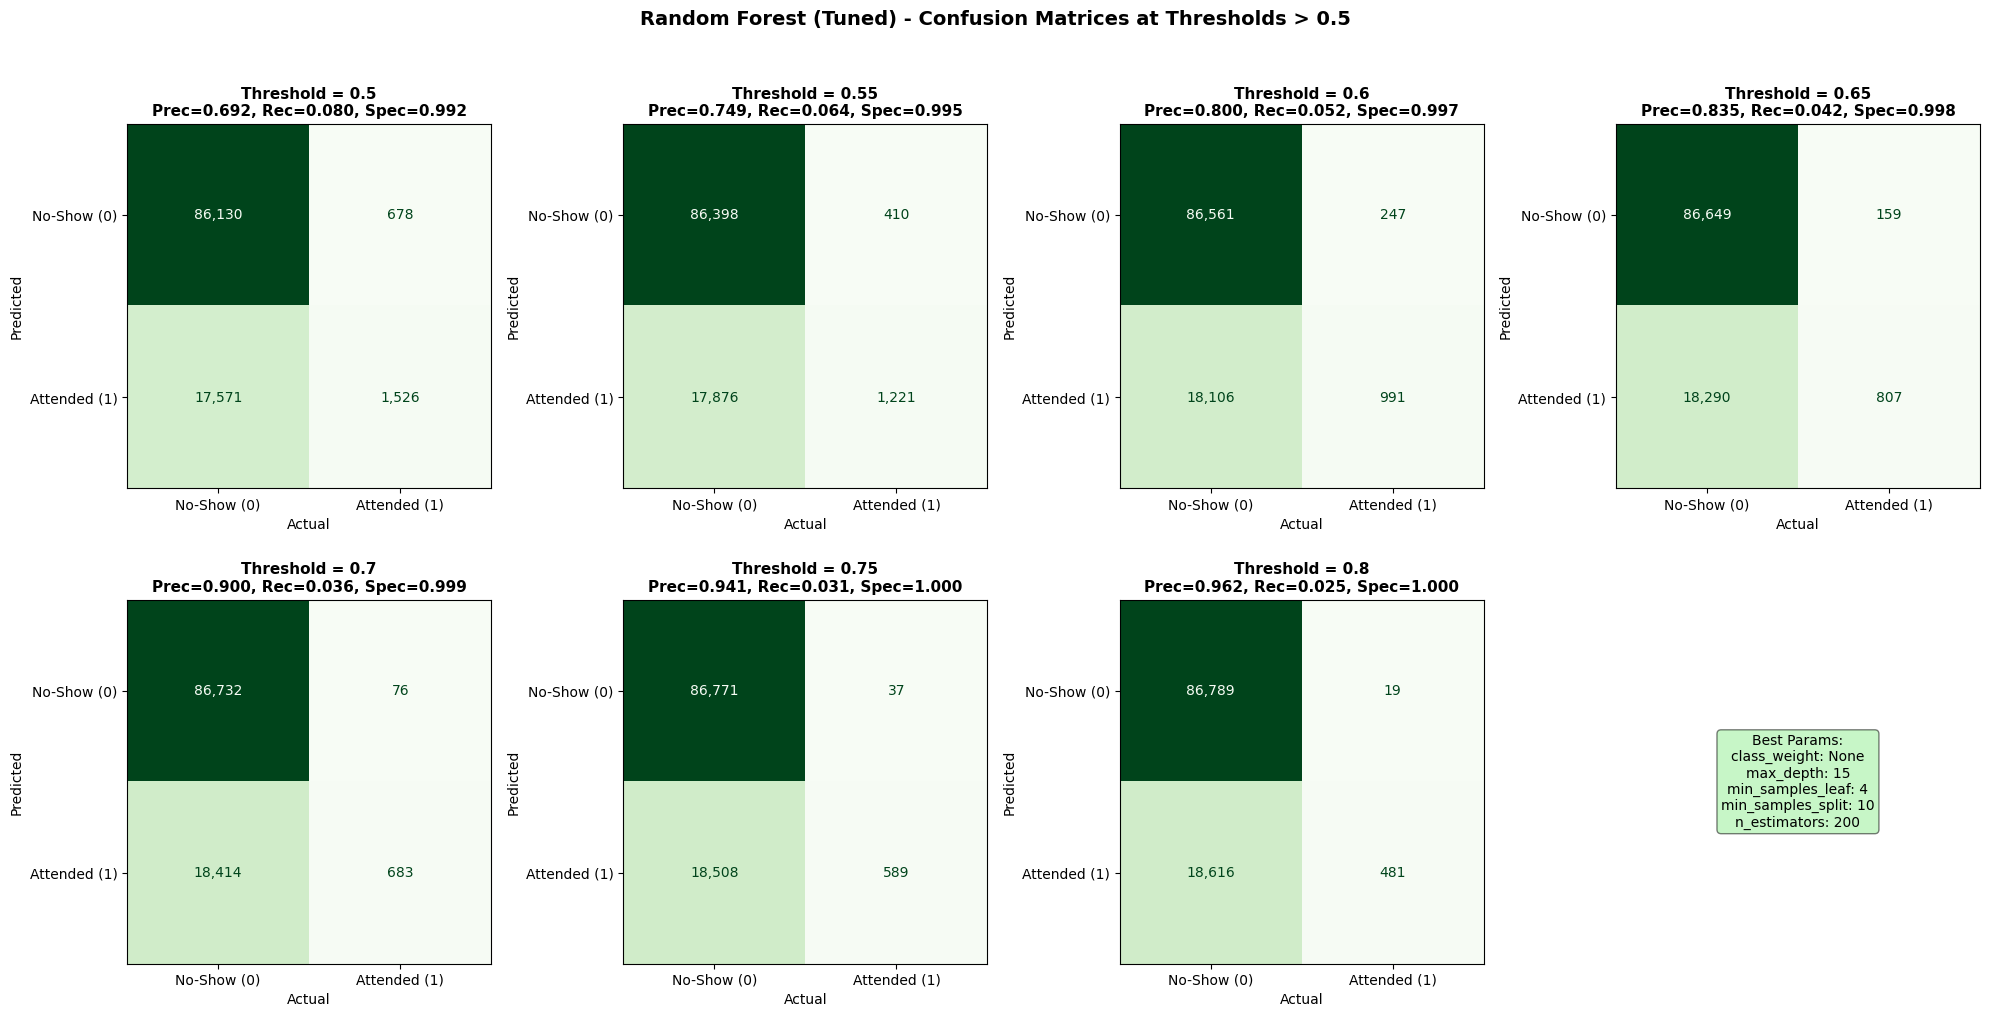


📋 STEP 5: METRICS SUMMARY

 Threshold    TN  FP    FN   TP  Precision   Recall  Specificity       F1
      0.50 86130 678 17571 1526   0.692377 0.079908     0.992190 0.143280
      0.55 86398 410 17876 1221   0.748620 0.063937     0.995277 0.117812
      0.60 86561 247 18106  991   0.800485 0.051893     0.997155 0.097467
      0.65 86649 159 18290  807   0.835404 0.042258     0.998168 0.080447
      0.70 86732  76 18414  683   0.899868 0.035765     0.999125 0.068795
      0.75 86771  37 18508  589   0.940895 0.030843     0.999574 0.059727
      0.80 86789  19 18616  481   0.962000 0.025187     0.999781 0.049089


In [ ]:
# -----------------------------------------------------------------------------
# STEP 4: EVALUATE AT DIFFERENT THRESHOLDS (> 0.5)
# -----------------------------------------------------------------------------
print("\n📋 STEP 4: CONFUSION MATRICES AT THRESHOLDS > 0.5")
print("-" * 50)

thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

# Create figure for confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Store metrics for summary
metrics_summary = []

for idx, thresh in enumerate(thresholds):
    # Convert probabilities to predictions
    y_pred = (rf_probas >= thresh).astype(int)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics_summary.append({
        'Threshold': thresh,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1': f1
    })
    
    # Plot confusion matrix
    ax = axes[idx]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No-Show (0)', 'Attended (1)'])
    disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format=',d')
    ax.set_title(f'Threshold = {thresh}\nPrec={precision:.3f}, Rec={recall:.3f}, Spec={specificity:.3f}', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

# Hide the last empty subplot
axes[-1].axis('off')
axes[-1].text(0.5, 0.5, f'Best Params:\n' + '\n'.join([f'{k}: {v}' for k, v in grid_search.best_params_.items()]),
              ha='center', va='center', fontsize=10, transform=axes[-1].transAxes,
              bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

fig.suptitle('Random Forest (Tuned) - Confusion Matrices at Thresholds > 0.5', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('../outputs/rf_tuned_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# STEP 5: SUMMARY TABLE
# -----------------------------------------------------------------------------
print("\n📋 STEP 5: METRICS SUMMARY")
print("="*80)

metrics_df = pd.DataFrame(metrics_summary)
print("\n" + metrics_df.to_string(index=False))

              Feature  Importance
         oks_t0_score    0.110595
oks_function_subscale    0.102261
       oks_t0_limping    0.076740
     oks_adl_subscale    0.058018
    oks_pain_subscale    0.033561
          oks_t0_pain    0.033502
          oks_t0_work    0.031474
    comorbidity_count    0.029006
       oks_t0_walking    0.026400
      oks_t0_shopping    0.025127
      oks_t0_standing    0.025083
        oks_t0_stairs    0.024111
    oks_t0_confidence    0.023549
      oks_t0_kneeling    0.023497
    oks_t0_night_pain    0.021369


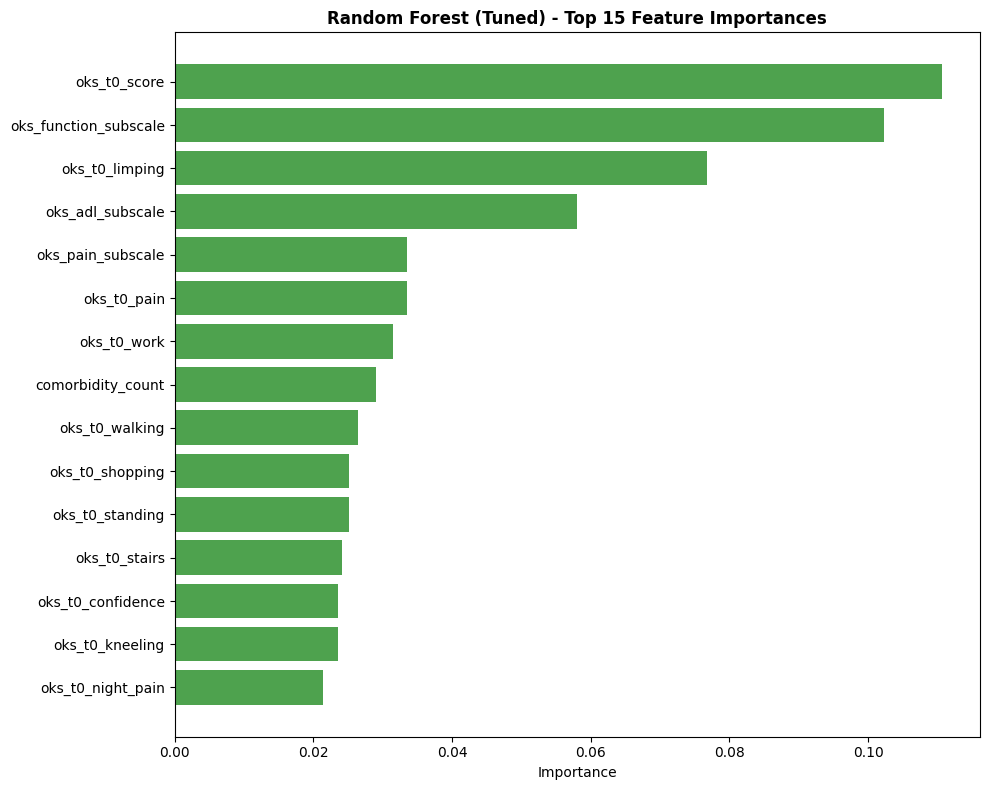


📋 STEP 7: TOP 5 HYPERPARAMETER COMBINATIONS
--------------------------------------------------
                                                                                                  Parameters  Mean CV Score  Std CV Score  Mean Train Score
{'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}       0.691281      0.004449          0.842840
 {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}       0.691066      0.004617          0.846582
 {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}       0.690635      0.004278          0.868109
{'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}       0.690444      0.004778          0.849647
{'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}       0.690092 

In [ ]:
best_rf.fit(X_train_final_encoded, y_train)

feature_importance = pd.DataFrame({
    'Feature': X_train_final_encoded.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = feature_importance.head(15)
bars = ax.barh(range(len(top_15)), top_15['Importance'], color='forestgreen', alpha=0.8)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Random Forest (Tuned) - Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# STEP 7: GRID SEARCH RESULTS SUMMARY
# -----------------------------------------------------------------------------
print("\n📋 STEP 7: TOP 5 HYPERPARAMETER COMBINATIONS")
print("-" * 50)

cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_5 = cv_results_df.nsmallest(5, 'rank_test_score')[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']]
top_5.columns = ['Parameters', 'Mean CV Score', 'Std CV Score', 'Mean Train Score']
print(top_5.to_string(index=False))

print("\n" + "="*80)
print("✓ RANDOM FOREST HYPERPARAMETER TUNING COMPLETE")
print("="*80)

# Explainable Boosting Machine (EBM)

EXPLAINABLE BOOSTING MACHINE (EBM) MODEL

📋 TRAINING EBM MODELS WITH DIFFERENT IMBALANCE HANDLING
--------------------------------------------------------------------------------

▶ Training: EBM - No weights...
  ✓ Val PR-AUC: 0.3836 | Gap: 0.0017

▶ Training: EBM - Balanced weights...
  ✓ Val PR-AUC: 0.3834 | Gap: 0.0017

▶ Training: EBM - SMOTE...
  ✓ Val PR-AUC: 0.3188 | Gap: 0.0014

OVERFITTING ANALYSIS (@ Threshold=0.5)
                        train_precision  val_precision  precision_gap  train_recall  val_recall  recall_gap overfit_flag
EBM - No weights                 0.6909         0.6876         0.0033        0.0825      0.0814      0.0011         ✓ OK
EBM - Balanced weights           0.2990         0.2981         0.0010        0.5708      0.5690      0.0018         ✓ OK
EBM - SMOTE                      0.3518         0.3507         0.0011        0.2810      0.2800      0.0010         ✓ OK

VALIDATION PRECISION ACROSS THRESHOLDS
           EBM - No weights  EBM - Balanced we

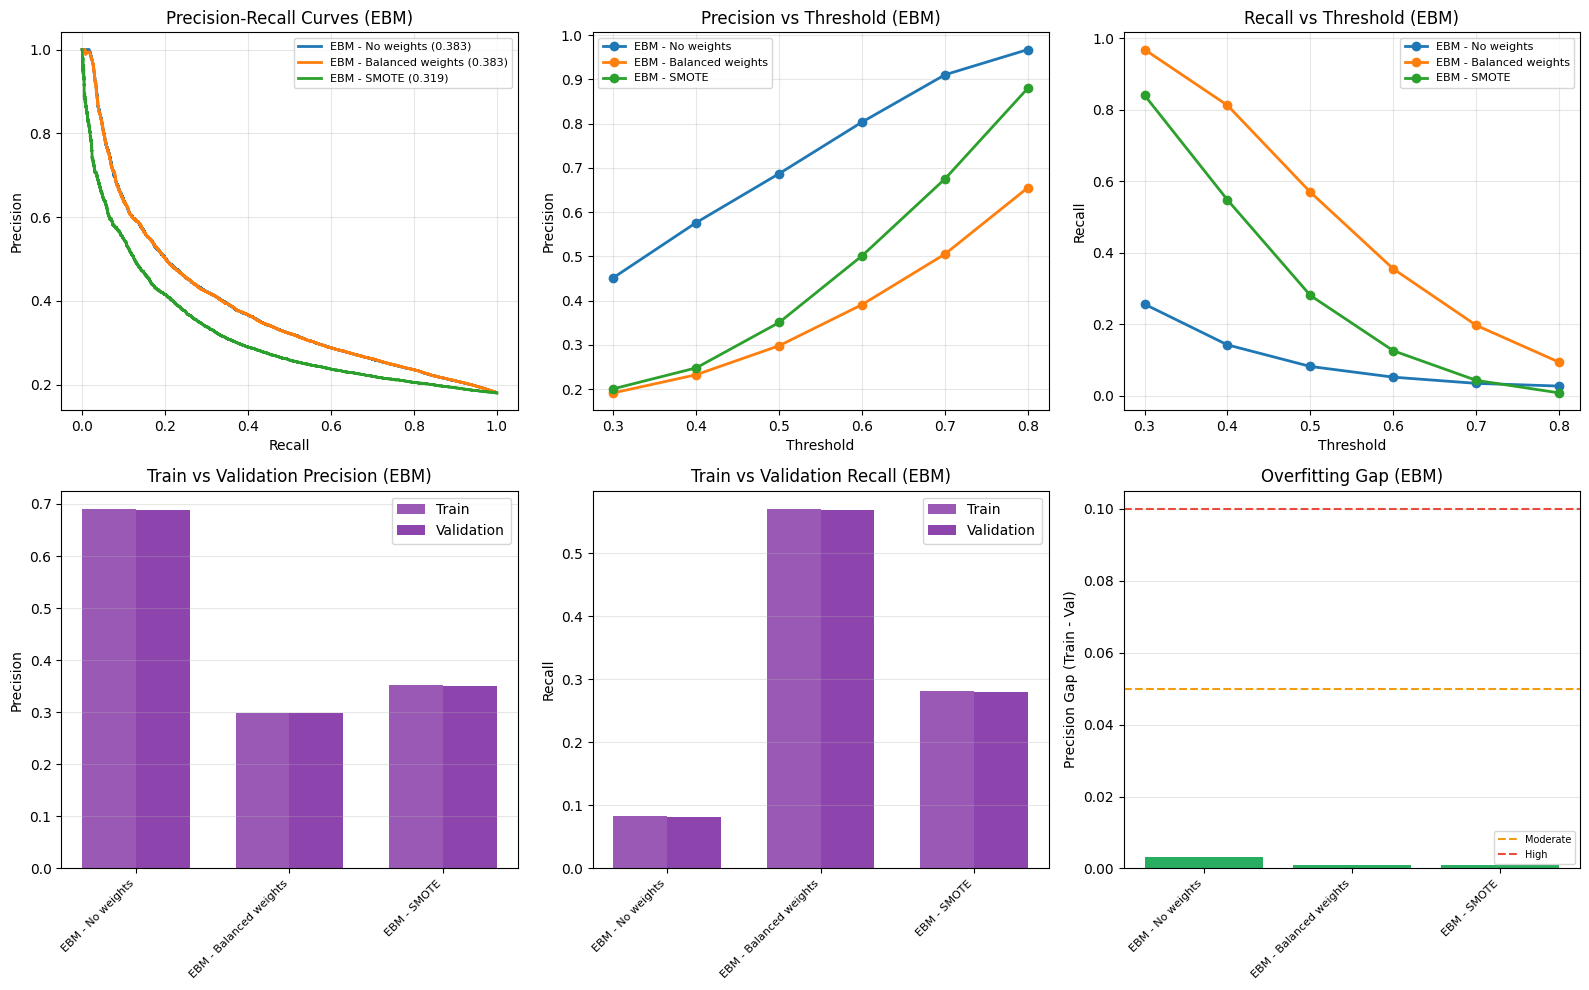


✓ EBM MODELS TRAINING COMPLETE


In [ ]:
# =============================================================================
# EXPLAINABLE BOOSTING MACHINE (EBM) WITH DIFFERENT IMBALANCE HANDLING & THRESHOLDS
# =============================================================================

from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("EXPLAINABLE BOOSTING MACHINE (EBM) MODEL")
print("="*80)

# Define EBM models with different class imbalance handling methods
ebm_models = {
    'EBM - No weights': ExplainableBoostingClassifier(
        random_state=42, interactions=0, max_rounds=100, learning_rate=0.01
    ),
    'EBM - Balanced weights': ExplainableBoostingClassifier(
        random_state=42, interactions=0, max_rounds=100, learning_rate=0.01,
        # Use SMOTE-equivalent weighting via sample_weight
    ),
    'EBM - SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('ebm', ExplainableBoostingClassifier(
            random_state=42, interactions=0, max_rounds=100, learning_rate=0.01
        ))
    ]),
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Store results
ebm_results = {}
ebm_overfit_results = {}
ebm_proba_dict = {}
ebm_feature_importance_dict = {}

print("\n📋 TRAINING EBM MODELS WITH DIFFERENT IMBALANCE HANDLING")
print("-" * 80)

for name, model in ebm_models.items():
    print(f"\n▶ Training: {name}...")
    
    # Storage for cross-validation
    val_probas = np.zeros(len(y_train))
    train_precisions, val_precisions = [], []
    train_recalls, val_recalls = [], []
    train_pr_aucs, val_pr_aucs = [], []
    
    # For balanced weights, we'll calculate sample weights
    if 'Balanced' in name:
        # Calculate class weights
        from sklearn.utils.class_weight import compute_sample_weight
        sample_weights = compute_sample_weight('balanced', y_train)
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_final_encoded, y_train)):
        X_tr, X_val = X_train_final_encoded.iloc[train_idx], X_train_final_encoded.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Clone and fit model
        model_clone = clone(model)
        
        # Apply sample weights for balanced variant
        if 'Balanced' in name:
            sw_train = sample_weights[train_idx]
            model_clone.fit(X_tr, y_tr, sample_weight=sw_train)
        else:
            model_clone.fit(X_tr, y_tr)
        
        # Get probabilities
        train_proba = model_clone.predict_proba(X_tr)[:, 1]
        val_proba = model_clone.predict_proba(X_val)[:, 1]
        val_probas[val_idx] = val_proba
        
        # Metrics at threshold=0.5
        train_pred = (train_proba >= 0.5).astype(int)
        val_pred = (val_proba >= 0.5).astype(int)
        
        train_precisions.append(precision_score(y_tr, train_pred, zero_division=0))
        val_precisions.append(precision_score(y_val, val_pred, zero_division=0))
        train_recalls.append(recall_score(y_tr, train_pred, zero_division=0))
        val_recalls.append(recall_score(y_val, val_pred, zero_division=0))
        
        # PR-AUC
        prec_tr, rec_tr, _ = precision_recall_curve(y_tr, train_proba)
        prec_val, rec_val, _ = precision_recall_curve(y_val, val_proba)
        train_pr_aucs.append(auc(rec_tr, prec_tr))
        val_pr_aucs.append(auc(rec_val, prec_val))
    
    ebm_proba_dict[name] = val_probas
    
    # Store metrics
    ebm_overfit_results[name] = {
        'train_precision': np.mean(train_precisions),
        'val_precision': np.mean(val_precisions),
        'precision_gap': np.mean(train_precisions) - np.mean(val_precisions),
        'train_recall': np.mean(train_recalls),
        'val_recall': np.mean(val_recalls),
        'recall_gap': np.mean(train_recalls) - np.mean(val_recalls),
        'train_pr_auc': np.mean(train_pr_aucs),
        'val_pr_auc': np.mean(val_pr_aucs),
        'pr_auc_gap': np.mean(train_pr_aucs) - np.mean(val_pr_aucs),
    }
    
    # Metrics at each threshold
    model_results = []
    for thresh in thresholds:
        y_pred = (val_probas >= thresh).astype(int)
        model_results.append({
            'threshold': thresh,
            'precision': precision_score(y_train, y_pred, zero_division=0),
            'recall': recall_score(y_train, y_pred, zero_division=0),
            'f1': f1_score(y_train, y_pred, zero_division=0),
            'n_predicted_pos': y_pred.sum()
        })
    
    ebm_results[name] = pd.DataFrame(model_results)
    print(f"  ✓ Val PR-AUC: {ebm_overfit_results[name]['val_pr_auc']:.4f} | Gap: {ebm_overfit_results[name]['pr_auc_gap']:.4f}")

# === OVERFITTING TABLE ===
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS (@ Threshold=0.5)")
print("=" * 80)

ebm_overfit_df = pd.DataFrame(ebm_overfit_results).T
ebm_overfit_df['overfit_flag'] = ebm_overfit_df['precision_gap'].apply(
    lambda x: '⚠️ HIGH' if x > 0.1 else ('⚡ MOD' if x > 0.05 else '✓ OK')
)
print(ebm_overfit_df[['train_precision', 'val_precision', 'precision_gap', 
                       'train_recall', 'val_recall', 'recall_gap', 'overfit_flag']].round(4).to_string())

# === THRESHOLD TABLES ===
print("\n" + "=" * 80)
print("VALIDATION PRECISION ACROSS THRESHOLDS")
print("=" * 80)

ebm_comparison_df = pd.DataFrame()
for name, df in ebm_results.items():
    ebm_comparison_df[name] = df.set_index('threshold')['precision']
print(ebm_comparison_df.round(4).to_string())

print("\n" + "=" * 80)
print("VALIDATION RECALL ACROSS THRESHOLDS")
print("=" * 80)

ebm_recall_df = pd.DataFrame()
for name, df in ebm_results.items():
    ebm_recall_df[name] = df.set_index('threshold')['recall']
print(ebm_recall_df.round(4).to_string())

# === PLOTS ===
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: PR Curves
ax1 = axes[0, 0]
for name, y_proba in ebm_proba_dict.items():
    prec_curve, rec_curve, _ = precision_recall_curve(y_train, y_proba)
    pr_auc = auc(rec_curve, prec_curve)
    ax1.plot(rec_curve, prec_curve, label=f'{name} ({pr_auc:.3f})', linewidth=2)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curves (EBM)')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Precision vs Threshold
ax2 = axes[0, 1]
for name, df in ebm_results.items():
    ax2.plot(df['threshold'], df['precision'], marker='o', label=name, linewidth=2)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Precision')
ax2.set_title('Precision vs Threshold (EBM)')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Recall vs Threshold
ax3 = axes[0, 2]
for name, df in ebm_results.items():
    ax3.plot(df['threshold'], df['recall'], marker='o', label=name, linewidth=2)
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Recall')
ax3.set_title('Recall vs Threshold (EBM)')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)

# Plot 4: Train vs Val Precision
ax4 = axes[1, 0]
x_pos = np.arange(len(ebm_overfit_results))
width = 0.35
train_prec = [v['train_precision'] for v in ebm_overfit_results.values()]
val_prec = [v['val_precision'] for v in ebm_overfit_results.values()]
ax4.bar(x_pos - width/2, train_prec, width, label='Train', color='#9b59b6')
ax4.bar(x_pos + width/2, val_prec, width, label='Validation', color='#8e44ad')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(list(ebm_overfit_results.keys()), rotation=45, ha='right', fontsize=8)
ax4.set_ylabel('Precision')
ax4.set_title('Train vs Validation Precision (EBM)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Train vs Val Recall
ax5 = axes[1, 1]
train_rec = [v['train_recall'] for v in ebm_overfit_results.values()]
val_rec = [v['val_recall'] for v in ebm_overfit_results.values()]
ax5.bar(x_pos - width/2, train_rec, width, label='Train', color='#9b59b6')
ax5.bar(x_pos + width/2, val_rec, width, label='Validation', color='#8e44ad')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(list(ebm_overfit_results.keys()), rotation=45, ha='right', fontsize=8)
ax5.set_ylabel('Recall')
ax5.set_title('Train vs Validation Recall (EBM)')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Overfitting Gap
ax6 = axes[1, 2]
gaps = [v['precision_gap'] for v in ebm_overfit_results.values()]
colors = ['#e74c3c' if g > 0.1 else '#f39c12' if g > 0.05 else '#27ae60' for g in gaps]
ax6.bar(x_pos, gaps, color=colors)
ax6.axhline(y=0.05, color='#f39c12', linestyle='--', label='Moderate')
ax6.axhline(y=0.1, color='#e74c3c', linestyle='--', label='High')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(list(ebm_overfit_results.keys()), rotation=45, ha='right', fontsize=8)
ax6.set_ylabel('Precision Gap (Train - Val)')
ax6.set_title('Overfitting Gap (EBM)')
ax6.legend(fontsize=7)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✓ EBM MODELS TRAINING COMPLETE")
print("=" * 80)

COMPREHENSIVE MODEL COMPARISON

📊 STEP 1: AGGREGATING RESULTS FROM ALL MODELS
--------------------------------------------------------------------------------
✓ All models evaluated at thresholds: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

BEST MODELS BY METRIC AT EACH THRESHOLD

🎯 THRESHOLD = 0.3
--------------------------------------------------------------------------------
  Best Precision:       RF (Tuned)           → 0.4537
  Best Recall:          EBM - Balanced weights → 0.9684
  Best F1:              LR - SMOTE           → 0.3599
  Best Bal. Accuracy:   LR - SMOTE           → 0.6096

🎯 THRESHOLD = 0.4
--------------------------------------------------------------------------------
  Best Precision:       RF (Tuned)           → 0.5766
  Best Recall:          EBM - Balanced weights → 0.8122
  Best F1:              LR - Balanced weights → 0.3632
  Best Bal. Accuracy:   LR - Balanced weights → 0.6134

🎯 THRESHOLD = 0.5
--------------------------------------------------------------------------

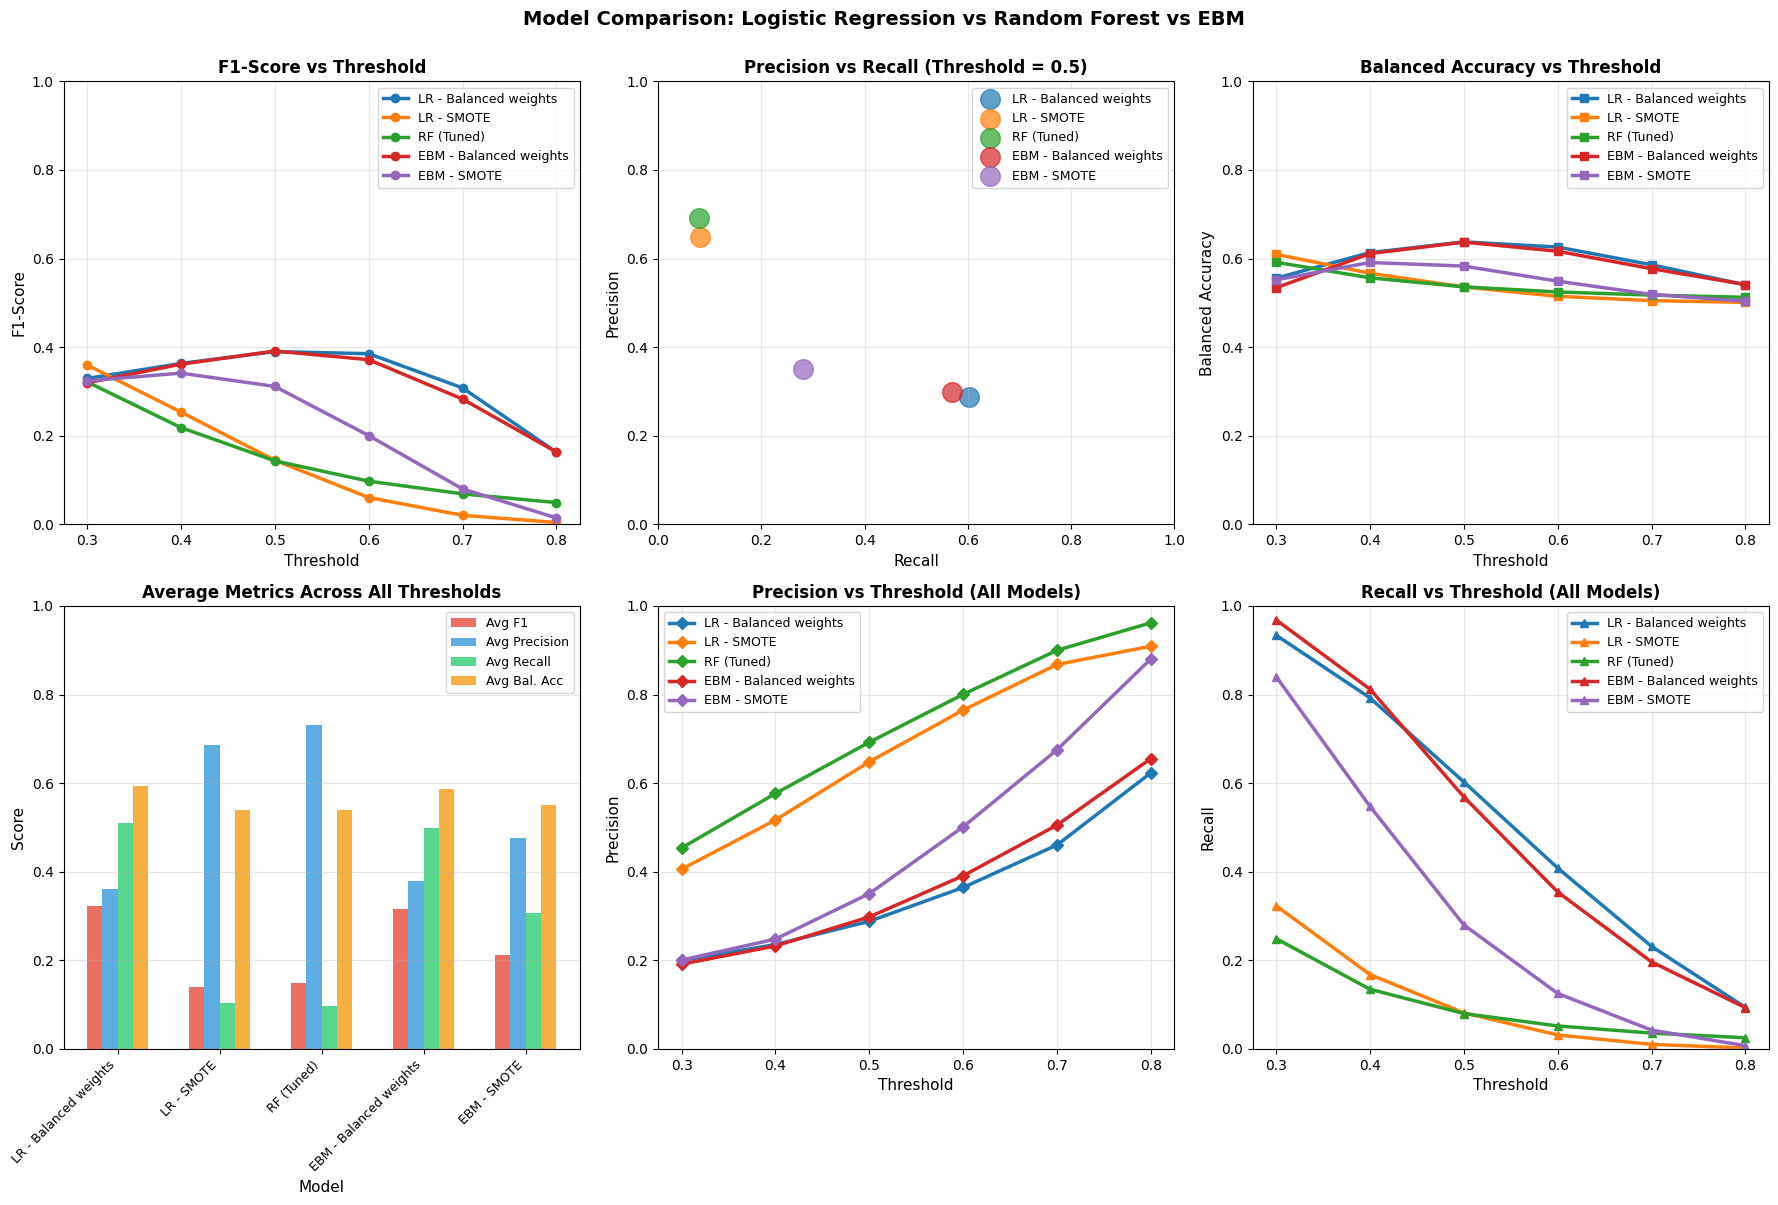


CONFUSION MATRICES AT THRESHOLD = 0.5


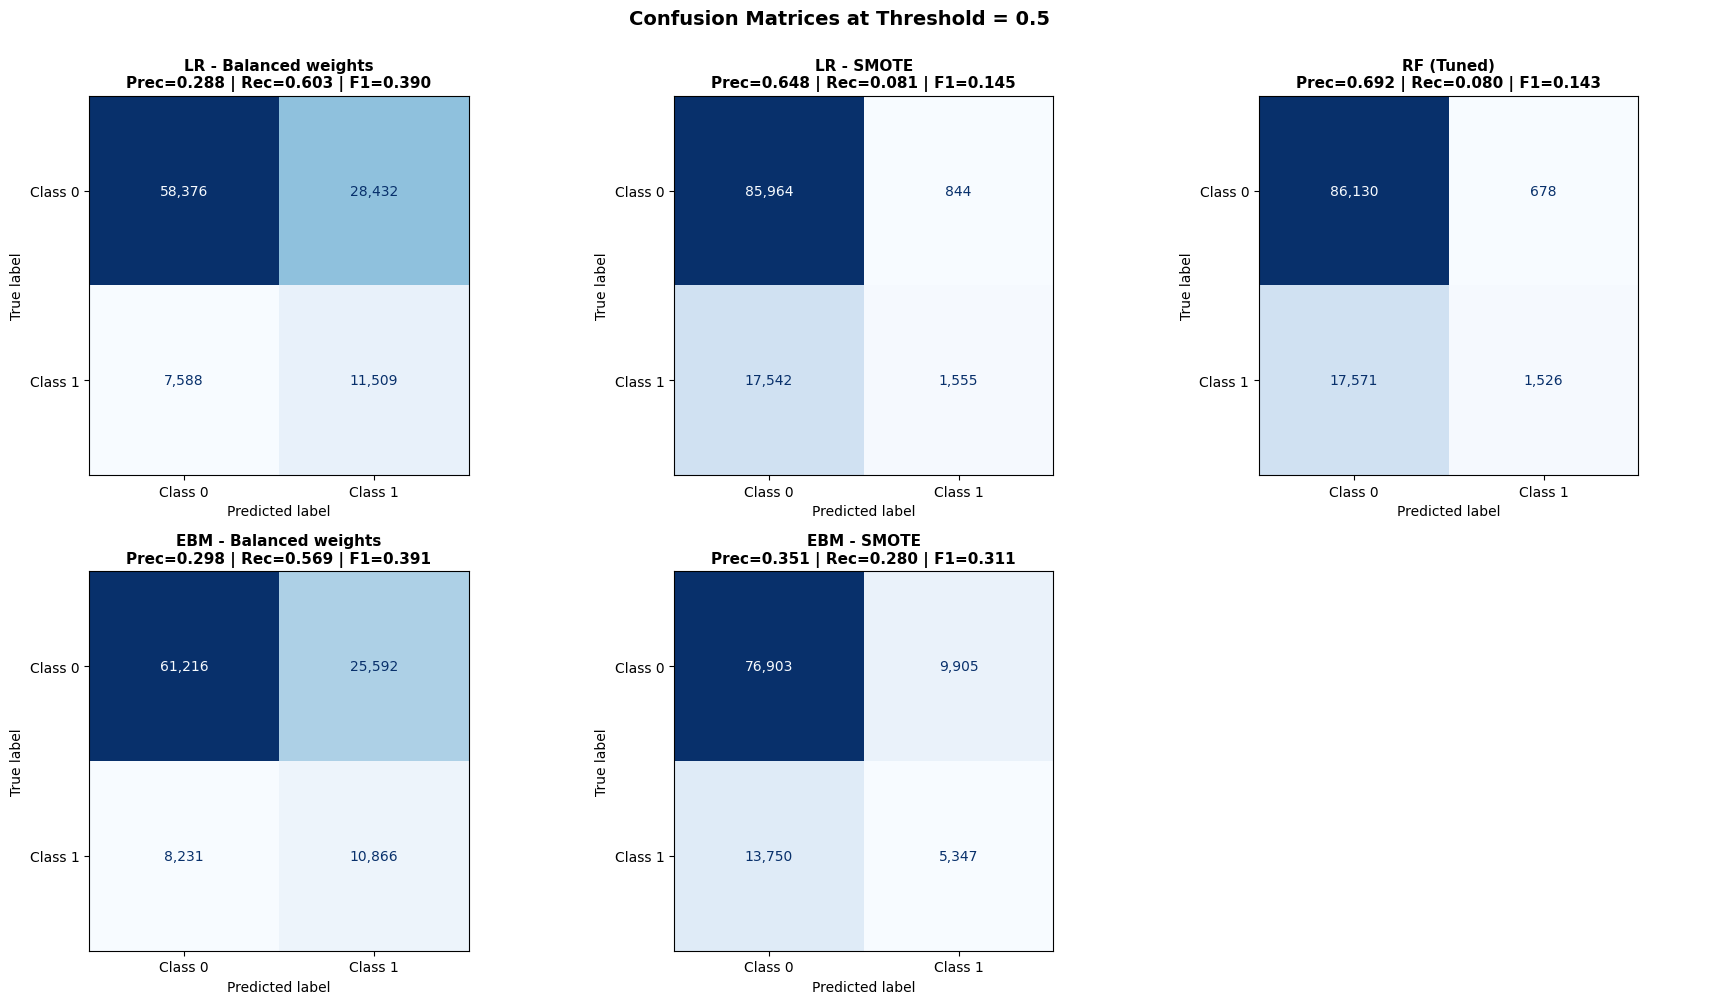


🏆 MODEL RECOMMENDATIONS

✅ BEST FOR BALANCED PERFORMANCE (F1-Score):
   Model: LR - Balanced weights
   Avg F1: 0.3231
   Recommended Threshold: 0.5

✅ BEST FOR BALANCED ACCURACY (Sensitivity & Specificity):
   Model: LR - Balanced weights
   Avg Balanced Acc: 0.5932

✅ BEST FOR PRECISION:
   Model: RF (Tuned)
   Avg Precision: 0.7308

✅ BEST FOR RECALL:
   Model: LR - Balanced weights
   Avg Recall: 0.5104

✓ MODEL COMPARISON COMPLETE


In [ ]:
# =============================================================================
# MODEL COMPARISON: LOGISTIC REGRESSION vs RANDOM FOREST vs EBM
# =============================================================================

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# === 1. PREPARE COMPARISON DATA ===
print("\n📊 STEP 1: AGGREGATING RESULTS FROM ALL MODELS")
print("-" * 80)

# Select best variants from each model family
selected_models = {
    'LR - Balanced weights': proba_dict['LR - Balanced weights'],
    'LR - SMOTE': proba_dict['LR - SMOTE'],
    'RF (Tuned)': rf_probas,
    'EBM - Balanced weights': ebm_proba_dict['EBM - Balanced weights'],
    'EBM - SMOTE': ebm_proba_dict['EBM - SMOTE'],
}

# Evaluate all models at multiple thresholds
comparison_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
all_model_metrics = {}

for model_name, probas in selected_models.items():
    model_metrics = []
    for thresh in comparison_thresholds:
        y_pred = (probas >= thresh).astype(int)
        
        # Calculate comprehensive metrics
        from sklearn.metrics import roc_auc_score, average_precision_score
        
        cm = confusion_matrix(y_train, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        balanced_accuracy = (recall + specificity) / 2
        
        model_metrics.append({
            'Threshold': thresh,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Specificity': specificity,
            'Balanced Acc': balanced_accuracy,
            'TP': tp,
            'FP': fp,
            'TN': tn,
            'FN': fn,
        })
    
    all_model_metrics[model_name] = pd.DataFrame(model_metrics)

print("✓ All models evaluated at thresholds:", comparison_thresholds)

# === 2. BEST MODELS AT EACH THRESHOLD ===
print("\n" + "=" * 80)
print("BEST MODELS BY METRIC AT EACH THRESHOLD")
print("=" * 80)

for thresh in comparison_thresholds:
    print(f"\n🎯 THRESHOLD = {thresh}")
    print("-" * 80)
    
    # Create dataframe for this threshold
    thresh_data = []
    for model_name, metrics_df in all_model_metrics.items():
        row = metrics_df[metrics_df['Threshold'] == thresh].iloc[0]
        thresh_data.append({
            'Model': model_name,
            'Precision': row['Precision'],
            'Recall': row['Recall'],
            'F1': row['F1'],
            'Bal. Acc': row['Balanced Acc'],
            'Specificity': row['Specificity'],
        })
    
    thresh_df = pd.DataFrame(thresh_data)
    
    # Find best for each metric
    print(f"  Best Precision:       {thresh_df.loc[thresh_df['Precision'].idxmax(), 'Model']:20} → {thresh_df['Precision'].max():.4f}")
    print(f"  Best Recall:          {thresh_df.loc[thresh_df['Recall'].idxmax(), 'Model']:20} → {thresh_df['Recall'].max():.4f}")
    print(f"  Best F1:              {thresh_df.loc[thresh_df['F1'].idxmax(), 'Model']:20} → {thresh_df['F1'].max():.4f}")
    print(f"  Best Bal. Accuracy:   {thresh_df.loc[thresh_df['Bal. Acc'].idxmax(), 'Model']:20} → {thresh_df['Bal. Acc'].max():.4f}")

# === 3. OVERALL BEST MODELS ===
print("\n" + "=" * 80)
print("OVERALL BEST MODELS (Across All Thresholds)")
print("=" * 80)

overall_metrics = {}
for model_name, metrics_df in all_model_metrics.items():
    overall_metrics[model_name] = {
        'Avg Precision': metrics_df['Precision'].mean(),
        'Avg Recall': metrics_df['Recall'].mean(),
        'Avg F1': metrics_df['F1'].mean(),
        'Avg Bal. Acc': metrics_df['Balanced Acc'].mean(),
        'Avg Specificity': metrics_df['Specificity'].mean(),
        'Max F1': metrics_df['F1'].max(),
        'Max F1 Threshold': metrics_df.loc[metrics_df['F1'].idxmax(), 'Threshold'],
    }

overall_df = pd.DataFrame(overall_metrics).T
print(overall_df.round(4).to_string())

# === 4. VISUALIZATIONS ===
print("\n" + "=" * 80)
print("GENERATING COMPARISON VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: F1-Score vs Threshold
ax1 = axes[0, 0]
for model_name, metrics_df in all_model_metrics.items():
    ax1.plot(metrics_df['Threshold'], metrics_df['F1'], marker='o', label=model_name, linewidth=2.5)
ax1.set_xlabel('Threshold', fontsize=11)
ax1.set_ylabel('F1-Score', fontsize=11)
ax1.set_title('F1-Score vs Threshold', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot 2: Precision vs Recall (Threshold = 0.5)
ax2 = axes[0, 1]
for model_name, metrics_df in all_model_metrics.items():
    row = metrics_df[metrics_df['Threshold'] == 0.5].iloc[0]
    ax2.scatter(row['Recall'], row['Precision'], s=200, alpha=0.7, label=model_name)
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision vs Recall (Threshold = 0.5)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

# Plot 3: Balanced Accuracy vs Threshold
ax3 = axes[0, 2]
for model_name, metrics_df in all_model_metrics.items():
    ax3.plot(metrics_df['Threshold'], metrics_df['Balanced Acc'], marker='s', label=model_name, linewidth=2.5)
ax3.set_xlabel('Threshold', fontsize=11)
ax3.set_ylabel('Balanced Accuracy', fontsize=11)
ax3.set_title('Balanced Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1])

# Plot 4: Average Metrics Across Thresholds (Bar Chart)
ax4 = axes[1, 0]
models_list = list(overall_metrics.keys())
x_pos = np.arange(len(models_list))
width = 0.15

metrics_names = ['Avg F1', 'Avg Precision', 'Avg Recall', 'Avg Bal. Acc']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics_names):
    values = [overall_metrics[m][metric] for m in models_list]
    ax4.bar(x_pos + idx*width, values, width, label=metric, color=colors[idx], alpha=0.8)

ax4.set_xlabel('Model', fontsize=11)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('Average Metrics Across All Thresholds', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos + width * 1.5)
ax4.set_xticklabels(models_list, rotation=45, ha='right', fontsize=9)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim([0, 1])

# Plot 5: Precision vs Threshold (Detailed)
ax5 = axes[1, 1]
for model_name, metrics_df in all_model_metrics.items():
    ax5.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='D', label=model_name, linewidth=2.5)
ax5.set_xlabel('Threshold', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('Precision vs Threshold (All Models)', fontsize=12, fontweight='bold')
ax5.legend(loc='best', fontsize=9)
ax5.grid(True, alpha=0.3)
ax5.set_ylim([0, 1])

# Plot 6: Recall vs Threshold (Detailed)
ax6 = axes[1, 2]
for model_name, metrics_df in all_model_metrics.items():
    ax6.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='^', label=model_name, linewidth=2.5)
ax6.set_xlabel('Threshold', fontsize=11)
ax6.set_ylabel('Recall', fontsize=11)
ax6.set_title('Recall vs Threshold (All Models)', fontsize=12, fontweight='bold')
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.3)
ax6.set_ylim([0, 1])

fig.suptitle('Model Comparison: Logistic Regression vs Random Forest vs EBM', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# === 5. CONFUSION MATRICES AT OPTIMAL THRESHOLD (0.5) ===
print("\n" + "=" * 80)
print("CONFUSION MATRICES AT THRESHOLD = 0.5")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (model_name, probas) in enumerate(selected_models.items()):
    y_pred = (probas >= 0.5).astype(int)
    cm = confusion_matrix(y_train, y_pred)
    
    ax = axes[idx]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
    
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    ax.set_title(f'{model_name}\nPrec={precision:.3f} | Rec={recall:.3f} | F1={f1:.3f}', 
                 fontsize=11, fontweight='bold')

axes[-1].axis('off')

fig.suptitle('Confusion Matrices at Threshold = 0.5', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# === 6. RECOMMENDATION ===
print("\n" + "=" * 80)
print("🏆 MODEL RECOMMENDATIONS")
print("=" * 80)

best_f1_model = overall_df['Avg F1'].idxmax()
best_f1_value = overall_df['Avg F1'].max()
best_f1_threshold = overall_df.loc[best_f1_model, 'Max F1 Threshold']

best_balanced_model = overall_df['Avg Bal. Acc'].idxmax()
best_balanced_value = overall_df['Avg Bal. Acc'].max()

best_precision_model = overall_df['Avg Precision'].idxmax()
best_recall_model = overall_df['Avg Recall'].idxmax()

print(f"\n✅ BEST FOR BALANCED PERFORMANCE (F1-Score):")
print(f"   Model: {best_f1_model}")
print(f"   Avg F1: {best_f1_value:.4f}")
print(f"   Recommended Threshold: {best_f1_threshold}")

print(f"\n✅ BEST FOR BALANCED ACCURACY (Sensitivity & Specificity):")
print(f"   Model: {best_balanced_model}")
print(f"   Avg Balanced Acc: {best_balanced_value:.4f}")

print(f"\n✅ BEST FOR PRECISION:")
print(f"   Model: {best_precision_model}")
print(f"   Avg Precision: {overall_df.loc[best_precision_model, 'Avg Precision']:.4f}")

print(f"\n✅ BEST FOR RECALL:")
print(f"   Model: {best_recall_model}")
print(f"   Avg Recall: {overall_df.loc[best_recall_model, 'Avg Recall']:.4f}")

print("\n" + "=" * 80)
print("✓ MODEL COMPARISON COMPLETE")
print("=" * 80)

# EBM Hyperparameter Tuning

EBM HYPERPARAMETER TUNING (NO WEIGHTS)

📋 STEP 1: DEFINING HYPERPARAMETER SEARCH SPACE
--------------------------------------------------------------------------------
EBM Hyperparameters to tune:
  • max_rounds: [100, 200, 300]
  • learning_rate: [0.001, 0.01, 0.05]
  • max_leaves: [3, 5, 7]

Total combinations: 27

📋 STEP 2: RUNNING GRID SEARCH WITH CROSS-VALIDATION
--------------------------------------------------------------------------------
Starting EBM grid search... (this may take several minutes)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✓ EBM Grid search complete!

Best Parameters:
  • learning_rate: 0.01
  • max_leaves: 3
  • max_rounds: 300

Best CV ROC-AUC Score: 0.6952

✓ Generated 105,905 probability predictions via 5-fold CV

📋 STEP 3: EVALUATING TUNED EBM AT DIFFERENT THRESHOLDS
--------------------------------------------------------------------------------

Tuned EBM Metrics at Different Thresholds:
----------------------------------------------

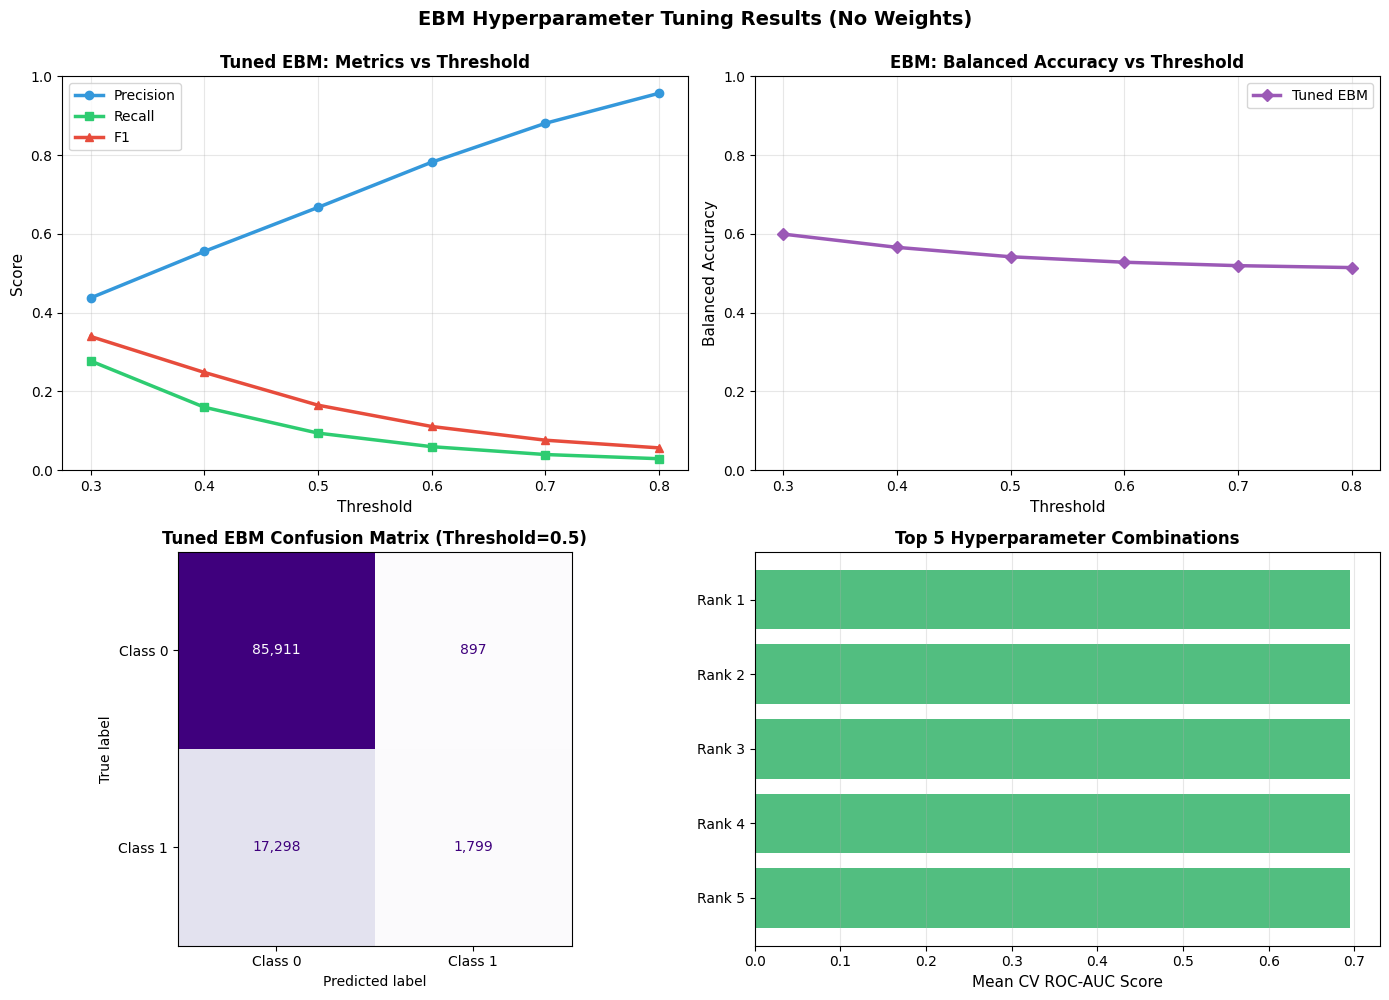


TOP 5 HYPERPARAMETER COMBINATIONS

Rank 1:
  Parameters: {'learning_rate': 0.01, 'max_leaves': 3, 'max_rounds': 300}
  Mean CV ROC-AUC: 0.6952 (+/- 0.0036)
  Mean Train ROC-AUC: 0.6986

Rank 2:
  Parameters: {'learning_rate': 0.05, 'max_leaves': 3, 'max_rounds': 300}
  Mean CV ROC-AUC: 0.6951 (+/- 0.0038)
  Mean Train ROC-AUC: 0.6987

Rank 3:
  Parameters: {'learning_rate': 0.05, 'max_leaves': 3, 'max_rounds': 200}
  Mean CV ROC-AUC: 0.6951 (+/- 0.0038)
  Mean Train ROC-AUC: 0.6987

Rank 4:
  Parameters: {'learning_rate': 0.01, 'max_leaves': 5, 'max_rounds': 300}
  Mean CV ROC-AUC: 0.6950 (+/- 0.0036)
  Mean Train ROC-AUC: 0.6989

Rank 5:
  Parameters: {'learning_rate': 0.05, 'max_leaves': 3, 'max_rounds': 100}
  Mean CV ROC-AUC: 0.6950 (+/- 0.0038)
  Mean Train ROC-AUC: 0.6984

🏆 TUNED EBM SUMMARY

✅ Best F1-Score:
   Threshold: 0.3
   F1-Score: 0.3395

✅ Best Balanced Accuracy:
   Threshold: 0.3
   Balanced Accuracy: 0.5995

✅ Best Hyperparameters Found:
   • learning_rate: 0.01
   

In [3]:
# =============================================================================
# EBM HYPERPARAMETER TUNING WITH GRID SEARCH (EBM - No Weights Only)
# =============================================================================

import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay
from interpret.glassbox import ExplainableBoostingClassifier
import matplotlib.pyplot as plt
import pandas as pd

print("="*80)
print("EBM HYPERPARAMETER TUNING (NO WEIGHTS)")
print("="*80)

# Define hyperparameter grids for EBM
ebm_param_grid = {
    'max_rounds': [100, 200, 300],           # Number of boosting rounds
    'learning_rate': [0.001, 0.01, 0.05],   # Learning rate (step size)
    'max_leaves': [3, 5, 7],                 # Max leaves per tree
}

print("\n📋 STEP 1: DEFINING HYPERPARAMETER SEARCH SPACE")
print("-" * 80)
print("EBM Hyperparameters to tune:")
for param, values in ebm_param_grid.items():
    print(f"  • {param}: {values}")

total_combinations = np.prod([len(v) for v in ebm_param_grid.values()])
print(f"\nTotal combinations: {total_combinations}")

# Setup cross-validation
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n📋 STEP 2: RUNNING GRID SEARCH WITH CROSS-VALIDATION")
print("-" * 80)

# Base EBM model with NO weights
ebm_base = ExplainableBoostingClassifier(
    random_state=42, 
    interactions=0
)

# Grid Search - using ROC-AUC as scoring metric
ebm_grid_search = GridSearchCV(
    estimator=ebm_base,
    param_grid=ebm_param_grid,
    cv=cv_inner,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting EBM grid search... (this may take several minutes)")
ebm_grid_search.fit(X_train_final_encoded, y_train)

print("\n✓ EBM Grid search complete!")
print(f"\nBest Parameters:")
for param, value in ebm_grid_search.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\nBest CV ROC-AUC Score: {ebm_grid_search.best_score_:.4f}")

# Get the best model
best_ebm = ebm_grid_search.best_estimator_

# Get cross-validated probability predictions for best model
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ebm_tuned_probas = cross_val_predict(best_ebm, X_train_final_encoded, y_train, 
                                      cv=cv_outer, method='predict_proba')[:, 1]

print(f"\n✓ Generated {len(ebm_tuned_probas):,} probability predictions via 5-fold CV")

# === EVALUATE TUNED EBM AT DIFFERENT THRESHOLDS ===
print("\n📋 STEP 3: EVALUATING TUNED EBM AT DIFFERENT THRESHOLDS")
print("-" * 80)

tuned_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
ebm_tuned_metrics = []

for thresh in tuned_thresholds:
    y_pred = (ebm_tuned_probas >= thresh).astype(int)
    
    cm = confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (recall + specificity) / 2
    
    ebm_tuned_metrics.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'Balanced Acc': balanced_accuracy,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    })

ebm_tuned_df = pd.DataFrame(ebm_tuned_metrics)

print("\nTuned EBM Metrics at Different Thresholds:")
print("-" * 80)
print(ebm_tuned_df[['Threshold', 'Precision', 'Recall', 'F1', 'Specificity', 'Balanced Acc']].round(4).to_string(index=False))

# === VISUALIZATIONS ===
print("\n📋 STEP 4: GENERATING VISUALIZATIONS")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Tuned EBM Metrics vs Threshold
ax1 = axes[0, 0]
ax1.plot(ebm_tuned_df['Threshold'], ebm_tuned_df['Precision'], marker='o', 
         label='Precision', linewidth=2.5, color='#3498db')
ax1.plot(ebm_tuned_df['Threshold'], ebm_tuned_df['Recall'], marker='s', 
         label='Recall', linewidth=2.5, color='#2ecc71')
ax1.plot(ebm_tuned_df['Threshold'], ebm_tuned_df['F1'], marker='^', 
         label='F1', linewidth=2.5, color='#e74c3c')
ax1.set_xlabel('Threshold', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Tuned EBM: Metrics vs Threshold', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot 2: Balanced Accuracy vs Threshold
ax2 = axes[0, 1]
ax2.plot(ebm_tuned_df['Threshold'], ebm_tuned_df['Balanced Acc'], marker='D', 
         label='Tuned EBM', linewidth=2.5, color='#9b59b6')
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Balanced Accuracy', fontsize=11)
ax2.set_title('EBM: Balanced Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# Plot 3: Confusion Matrix at Threshold 0.5
ax3 = axes[1, 0]
y_pred_tuned = (ebm_tuned_probas >= 0.5).astype(int)
cm_tuned = confusion_matrix(y_train, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, 
                                     display_labels=['Class 0', 'Class 1'])
disp_tuned.plot(ax=ax3, cmap='Purples', colorbar=False, values_format=',d')
ax3.set_title('Tuned EBM Confusion Matrix (Threshold=0.5)', fontsize=12, fontweight='bold')

# Plot 4: Top Hyperparameter Combinations
ax4 = axes[1, 1]
cv_results_df = pd.DataFrame(ebm_grid_search.cv_results_)
top_5 = cv_results_df.nsmallest(5, 'rank_test_score')
ax4.barh(range(len(top_5)), top_5['mean_test_score'], color='#27ae60', alpha=0.8)
ax4.set_yticks(range(len(top_5)))
ax4.set_yticklabels([f"Rank {int(r)}" for r in top_5['rank_test_score']])
ax4.invert_yaxis()
ax4.set_xlabel('Mean CV ROC-AUC Score', fontsize=11)
ax4.set_title('Top 5 Hyperparameter Combinations', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

fig.suptitle('EBM Hyperparameter Tuning Results (No Weights)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# === TOP PARAMETER COMBINATIONS ===
print("\n" + "=" * 80)
print("TOP 5 HYPERPARAMETER COMBINATIONS")
print("=" * 80)

ebm_cv_results_df = pd.DataFrame(ebm_grid_search.cv_results_)
ebm_top_5 = ebm_cv_results_df.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'mean_train_score']
].copy()
ebm_top_5.columns = ['Parameters', 'Mean CV ROC-AUC', 'Std CV ROC-AUC', 'Mean Train ROC-AUC']

for idx, row in ebm_top_5.iterrows():
    print(f"\nRank {ebm_cv_results_df.loc[idx, 'rank_test_score']}:")
    print(f"  Parameters: {row['Parameters']}")
    print(f"  Mean CV ROC-AUC: {row['Mean CV ROC-AUC']:.4f} (+/- {row['Std CV ROC-AUC']:.4f})")
    print(f"  Mean Train ROC-AUC: {row['Mean Train ROC-AUC']:.4f}")

# === SUMMARY ===
print("\n" + "=" * 80)
print("🏆 TUNED EBM SUMMARY")
print("=" * 80)

best_tuned_f1_idx = ebm_tuned_df['F1'].idxmax()
best_tuned_f1_thresh = ebm_tuned_df.loc[best_tuned_f1_idx, 'Threshold']
best_tuned_f1_score = ebm_tuned_df.loc[best_tuned_f1_idx, 'F1']

best_tuned_bal_acc_idx = ebm_tuned_df['Balanced Acc'].idxmax()
best_tuned_bal_thresh = ebm_tuned_df.loc[best_tuned_bal_acc_idx, 'Threshold']
best_tuned_bal_score = ebm_tuned_df.loc[best_tuned_bal_acc_idx, 'Balanced Acc']

print(f"\n✅ Best F1-Score:")
print(f"   Threshold: {best_tuned_f1_thresh}")
print(f"   F1-Score: {best_tuned_f1_score:.4f}")

print(f"\n✅ Best Balanced Accuracy:")
print(f"   Threshold: {best_tuned_bal_thresh}")
print(f"   Balanced Accuracy: {best_tuned_bal_score:.4f}")

print(f"\n✅ Best Hyperparameters Found:")
for param, value in ebm_grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print("\n" + "=" * 80)
print("✓ EBM HYPERPARAMETER TUNING COMPLETE")
print("=" * 80)


In [5]:
# =============================================================================
# THRESHOLD ANALYSIS TABLE: EBM TUNED MODEL (NO WEIGHTS)
# =============================================================================

import pandas as pd
from sklearn.metrics import confusion_matrix

print("="*80)
print("THRESHOLD ANALYSIS: EBM TUNED MODEL (NO WEIGHTS)")
print("="*80)

# Define thresholds
thresholds = [0.5, 0.6, 0.7, 0.8]

# Calculate metrics for each threshold
results = []

for thresh in sorted(thresholds):
    y_pred = (ebm_tuned_probas >= thresh).astype(int)
    
    cm = confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    predicted_positive = y_pred.sum()
    
    results.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'Predicted Positive': int(predicted_positive)
    })

# Create DataFrame
threshold_table = pd.DataFrame(results)

# Display the table
print("\nEBM Tuned Model Performance Metrics Across Thresholds:")
print("=" * 100)
print(threshold_table.to_string(index=False))
print("=" * 100)

# Create a more formatted table for visualization
print("\n\nFormatted Table (with rounding):")
print("-" * 100)

formatted_df = threshold_table.copy()
for col in ['Precision', 'Recall', 'F1', 'Specificity']:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.4f}")
formatted_df['Predicted Positive'] = formatted_df['Predicted Positive'].astype(int)

print(formatted_df.to_string(index=False))
print("-" * 100)

print("\nTable saved for export if needed.")


THRESHOLD ANALYSIS: EBM TUNED MODEL (NO WEIGHTS)

EBM Tuned Model Performance Metrics Across Thresholds:
 Threshold  Precision   Recall       F1  Specificity  Predicted Positive
       0.5   0.667285 0.094203 0.165099     0.989667                2696
       0.6   0.782042 0.059748 0.111014     0.996337                1459
       0.7   0.880787 0.039849 0.076249     0.998813                 864
       0.8   0.957118 0.029219 0.056707     0.999712                 583


Formatted Table (with rounding):
----------------------------------------------------------------------------------------------------
 Threshold Precision Recall     F1 Specificity  Predicted Positive
       0.5    0.6673 0.0942 0.1651      0.9897                2696
       0.6    0.7820 0.0597 0.1110      0.9963                1459
       0.7    0.8808 0.0398 0.0762      0.9988                 864
       0.8    0.9571 0.0292 0.0567      0.9997                 583
-----------------------------------------------------------

In [7]:
best_ebm = ebm_grid_search.best_estimator_
best_ebm.fit(X_train_final_encoded, y_train)

import joblib
import os

joblib.dump(best_ebm, 'best_ebm_model.joblib')

['best_ebm_model.joblib']

In [8]:
print(best_ebm)

ExplainableBoostingClassifier(interactions=0, learning_rate=0.01, max_leaves=3,
                              max_rounds=300)


LOAD SAVED EBM MODEL AND EVALUATE ON TEST SET

📂 LOADING SAVED EBM MODEL
--------------------------------------------------------------------------------
✓ Saved EBM model loaded successfully

📊 LOADING TEST SET
--------------------------------------------------------------------------------
✓ Test set loaded:
  • X_test shape: (26477, 57)
  • y_test shape: (26477,)
  • Class distribution: {0: 21702, 1: 4775}

🎯 GENERATING PREDICTIONS ON TEST SET
--------------------------------------------------------------------------------
✓ Probability predictions generated for 26,477 test samples
  • Min probability: 0.0366
  • Max probability: 0.9999
  • Mean probability: 0.1817

📈 EVALUATION AT MULTIPLE THRESHOLDS
--------------------------------------------------------------------------------

Test Set Metrics at Different Thresholds:
----------------------------------------------------------------------------------------------------
 Threshold  Precision  Recall     F1  Specificity  Balanced A

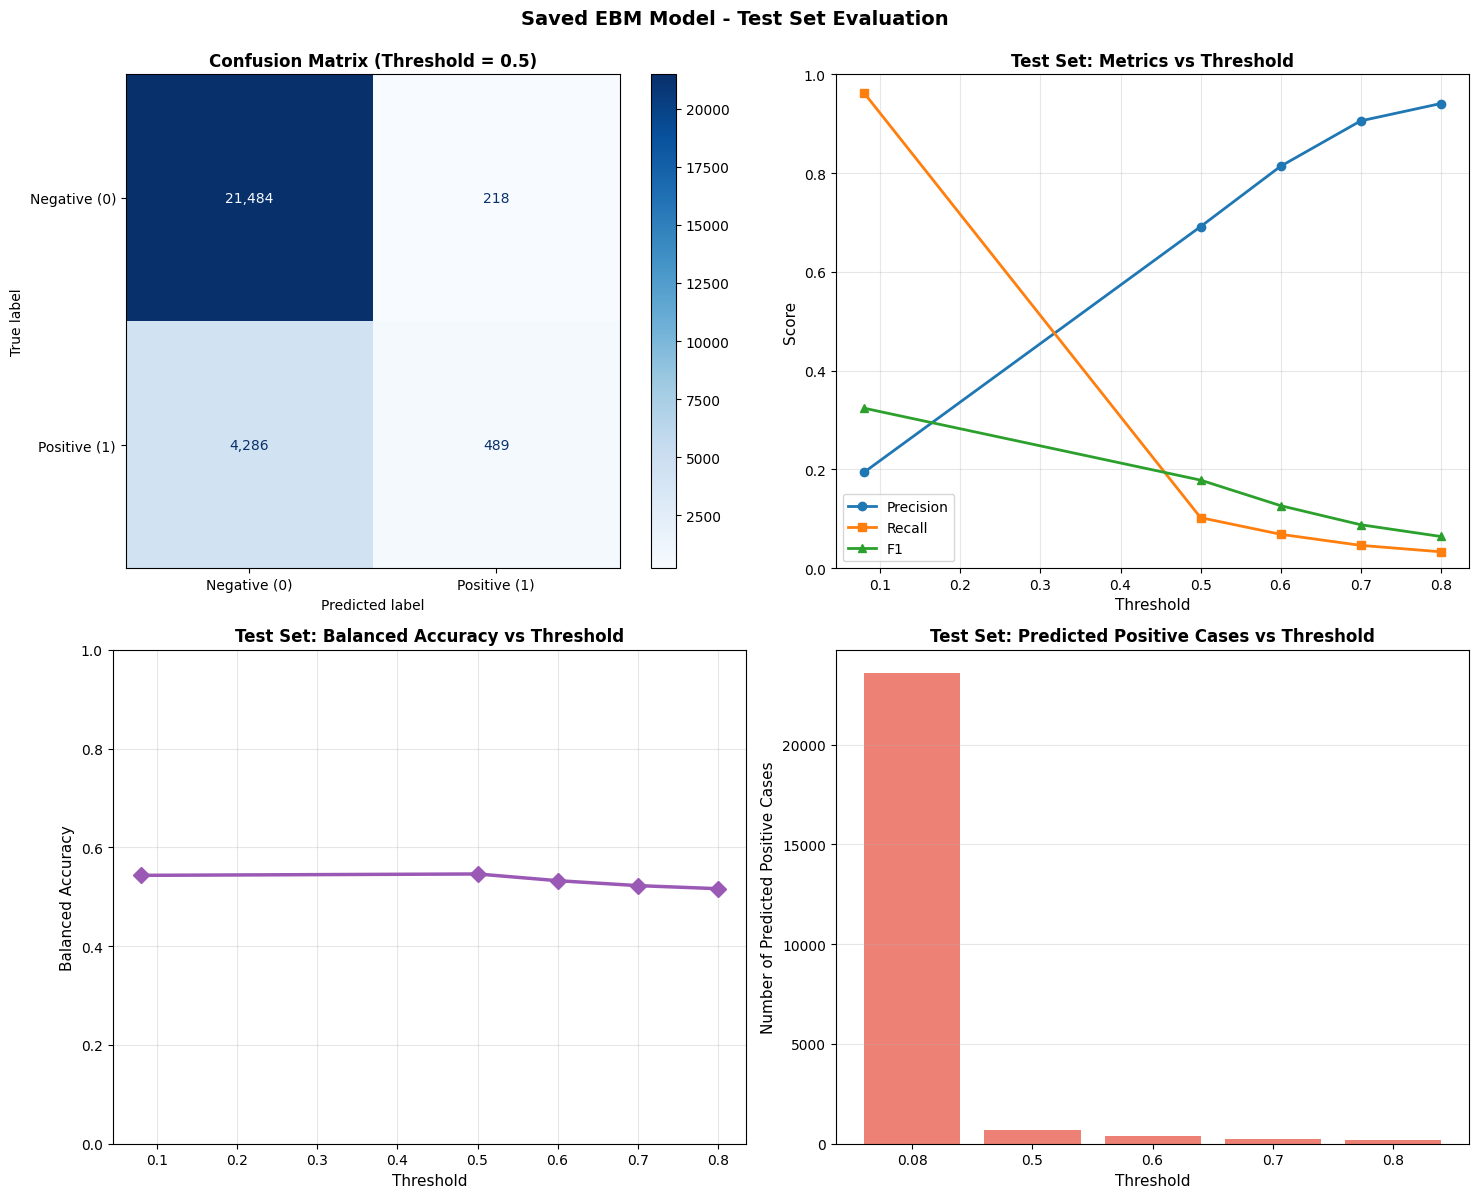


✓ TEST SET EVALUATION COMPLETE


In [9]:
# =============================================================================
# LOAD SAVED EBM MODEL AND EVALUATE ON TEST SET
# =============================================================================

import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             classification_report)
import matplotlib.pyplot as plt

print("="*80)
print("LOAD SAVED EBM MODEL AND EVALUATE ON TEST SET")
print("="*80)

# Load saved model
print("\n📂 LOADING SAVED EBM MODEL")
print("-" * 80)
loaded_ebm = joblib.load('best_ebm_model.joblib')
print("✓ Saved EBM model loaded successfully")

# Load test set
print("\n📊 LOADING TEST SET")
print("-" * 80)
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print(f"✓ Test set loaded:")
print(f"  • X_test shape: {X_test.shape}")
print(f"  • y_test shape: {y_test.shape}")
print(f"  • Class distribution: {y_test.value_counts().to_dict()}")

# Generate predictions
print(f"\n🎯 GENERATING PREDICTIONS ON TEST SET")
print("-" * 80)

test_probas = loaded_ebm.predict_proba(X_test)[:, 1]
print(f"✓ Probability predictions generated for {len(test_probas):,} test samples")
print(f"  • Min probability: {test_probas.min():.4f}")
print(f"  • Max probability: {test_probas.max():.4f}")
print(f"  • Mean probability: {test_probas.mean():.4f}")

# Evaluate at multiple thresholds
print(f"\n📈 EVALUATION AT MULTIPLE THRESHOLDS")
print("-" * 80)

evaluation_thresholds = [0.08, 0.5, 0.6, 0.7, 0.8]
test_results = []

for thresh in evaluation_thresholds:
    y_pred = (test_probas >= thresh).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (recall + specificity) / 2
    roc_auc = roc_auc_score(y_test, test_probas)
    pr_auc = average_precision_score(y_test, test_probas)
    
    test_results.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'Balanced Acc': balanced_accuracy,
        'Predicted Positive': y_pred.sum(),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

test_eval_df = pd.DataFrame(test_results)

print("\nTest Set Metrics at Different Thresholds:")
print("-" * 100)
display_cols = ['Threshold', 'Precision', 'Recall', 'F1', 'Specificity', 'Balanced Acc', 'Predicted Positive']
print(test_eval_df[display_cols].round(4).to_string(index=False))
print("-" * 100)

# Detailed evaluation at threshold 0.5
print(f"\n🔍 DETAILED EVALUATION @ THRESHOLD 0.5")
print("-" * 80)

threshold_05 = 0.5
y_pred_05 = (test_probas >= threshold_05).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05)
tn, fp, fn, tp = cm_05.ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
balanced_accuracy = (recall + specificity) / 2
roc_auc = roc_auc_score(y_test, test_probas)
pr_auc = average_precision_score(y_test, test_probas)

print(f"\n{'Metric':<30} {'Value':>15}")
print("-" * 46)
print(f"{'True Negatives (TN)':<30} {tn:>15,}")
print(f"{'False Positives (FP)':<30} {fp:>15,}")
print(f"{'False Negatives (FN)':<30} {fn:>15,}")
print(f"{'True Positives (TP)':<30} {tp:>15,}")
print("-" * 46)
print(f"{'Precision':<30} {precision:>15.4f}")
print(f"{'Recall (Sensitivity)':<30} {recall:>15.4f}")
print(f"{'Specificity':<30} {specificity:>15.4f}")
print(f"{'F1-Score':<30} {f1:>15.4f}")
print(f"{'Balanced Accuracy':<30} {balanced_accuracy:>15.4f}")
print(f"{'ROC-AUC':<30} {roc_auc:>15.4f}")
print(f"{'PR-AUC':<30} {pr_auc:>15.4f}")

print(f"\nPredictions @ Threshold {threshold_05}:")
print(f"  • Predicted Positive: {y_pred_05.sum():,} ({100*y_pred_05.sum()/len(y_pred_05):.1f}%)")
print(f"  • Predicted Negative: {(1-y_pred_05).sum():,} ({100*(1-y_pred_05).sum()/len(y_pred_05):.1f}%)")

# Classification report
print(f"\n📋 CLASSIFICATION REPORT @ THRESHOLD {threshold_05}")
print("-" * 80)
print(classification_report(y_test, y_pred_05, target_names=['Class 0', 'Class 1']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Confusion Matrix @ 0.5
ax1 = axes[0, 0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_05, display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(ax=ax1, cmap='Blues', values_format=',d')
ax1.set_title(f'Confusion Matrix (Threshold = {threshold_05})', fontsize=12, fontweight='bold')

# Plot 2: Metrics across thresholds
ax2 = axes[0, 1]
ax2.plot(test_eval_df['Threshold'], test_eval_df['Precision'], marker='o', label='Precision', linewidth=2)
ax2.plot(test_eval_df['Threshold'], test_eval_df['Recall'], marker='s', label='Recall', linewidth=2)
ax2.plot(test_eval_df['Threshold'], test_eval_df['F1'], marker='^', label='F1', linewidth=2)
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Test Set: Metrics vs Threshold', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# Plot 3: Balanced Accuracy vs Threshold
ax3 = axes[1, 0]
ax3.plot(test_eval_df['Threshold'], test_eval_df['Balanced Acc'], marker='D', 
         color='#9b59b6', linewidth=2.5, markersize=8)
ax3.set_xlabel('Threshold', fontsize=11)
ax3.set_ylabel('Balanced Accuracy', fontsize=11)
ax3.set_title('Test Set: Balanced Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1])

# Plot 4: Predicted Positive Cases vs Threshold
ax4 = axes[1, 1]
ax4.bar(test_eval_df['Threshold'].astype(str), test_eval_df['Predicted Positive'], color='#e74c3c', alpha=0.7)
ax4.set_xlabel('Threshold', fontsize=11)
ax4.set_ylabel('Number of Predicted Positive Cases', fontsize=11)
ax4.set_title('Test Set: Predicted Positive Cases vs Threshold', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

fig.suptitle('Saved EBM Model - Test Set Evaluation', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ TEST SET EVALUATION COMPLETE")
print("="*80)


In [10]:
# =============================================================================
# VALIDATION DATA THRESHOLD ANALYSIS TABLE
# Using cross-validated probabilities from training set
# =============================================================================

import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("="*100)
print("VALIDATION DATA: SAVED EBM MODEL THRESHOLD ANALYSIS")
print("="*100)
print("\nNote: Validation analysis uses cross-validated probabilities from training set")
print("(ebm_tuned_probas generated via 5-fold cross-validation)")

# Use the cross-validated probabilities from EBM tuning
validation_probas = ebm_tuned_probas
validation_targets = y_train

print(f"\nValidation Data Summary:")
print(f"  • Number of validation samples: {len(validation_probas):,}")
print(f"  • Class distribution: {dict(y_train.value_counts())}")

# Define thresholds
val_thresholds = [0.5, 0.6, 0.7, 0.8]

# Calculate metrics for each threshold
validation_results = []

for thresh in val_thresholds:
    y_pred = (validation_probas >= thresh).astype(int)
    
    cm = confusion_matrix(validation_targets, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    balanced_accuracy = (recall + specificity) / 2
    predicted_positive = y_pred.sum()
    
    validation_results.append({
        'Threshold': thresh,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'Balanced Acc': balanced_accuracy,
        'Predicted Positive': int(predicted_positive),
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    })

# Create DataFrame
val_threshold_table = pd.DataFrame(validation_results)

# Display the table
print("\n" + "="*100)
print("VALIDATION DATA PERFORMANCE METRICS ACROSS THRESHOLDS")
print("="*100)
print()
display_cols_val = ['Threshold', 'Precision', 'Recall', 'F1', 'Specificity', 
                     'Balanced Acc', 'Predicted Positive']
print(val_threshold_table[display_cols_val].to_string(index=False))
print("="*100)

# Create a more formatted version
print("\n\nFORMATTED TABLE (with 4 decimal places):")
print("-"*100)

formatted_val_df = val_threshold_table[['Threshold', 'Precision', 'Recall', 'F1', 
                                          'Specificity', 'Balanced Acc', 'Predicted Positive']].copy()
for col in ['Precision', 'Recall', 'F1', 'Specificity', 'Balanced Acc']:
    formatted_val_df[col] = formatted_val_df[col].apply(lambda x: f"{x:.4f}")
formatted_val_df['Predicted Positive'] = formatted_val_df['Predicted Positive'].astype(int)

print(formatted_val_df.to_string(index=False))
print("-"*100)

# Summary statistics
print("\n\nSUMMARY INSIGHTS:")
print("-"*100)

best_f1_idx = val_threshold_table['F1'].idxmax()
best_f1_threshold = val_threshold_table.loc[best_f1_idx, 'Threshold']
best_f1_score = val_threshold_table.loc[best_f1_idx, 'F1']

best_balanced_idx = val_threshold_table['Balanced Acc'].idxmax()
best_balanced_threshold = val_threshold_table.loc[best_balanced_idx, 'Threshold']
best_balanced_score = val_threshold_table.loc[best_balanced_idx, 'Balanced Acc']

print(f"\n✅ Best F1-Score:")
print(f"   Threshold: {best_f1_threshold}")
print(f"   F1-Score: {best_f1_score:.4f}")
print(f"   Precision: {val_threshold_table.loc[best_f1_idx, 'Precision']:.4f}")
print(f"   Recall: {val_threshold_table.loc[best_f1_idx, 'Recall']:.4f}")

print(f"\n✅ Best Balanced Accuracy:")
print(f"   Threshold: {best_balanced_threshold}")
print(f"   Balanced Accuracy: {best_balanced_score:.4f}")
print(f"   Recall: {val_threshold_table.loc[best_balanced_idx, 'Recall']:.4f}")
print(f"   Specificity: {val_threshold_table.loc[best_balanced_idx, 'Specificity']:.4f}")

print(f"\n✅ Conservative Threshold (High Precision):")
print(f"   Threshold: 0.8")
idx_08 = val_threshold_table[val_threshold_table['Threshold'] == 0.8].index[0]
print(f"   Precision: {val_threshold_table.loc[idx_08, 'Precision']:.4f}")
print(f"   Predicted Positive: {val_threshold_table.loc[idx_08, 'Predicted Positive']:,}")

print("\n" + "="*100)
print("✓ VALIDATION DATA ANALYSIS COMPLETE")
print("="*100)


VALIDATION DATA: SAVED EBM MODEL THRESHOLD ANALYSIS

Note: Validation analysis uses cross-validated probabilities from training set
(ebm_tuned_probas generated via 5-fold cross-validation)

Validation Data Summary:
  • Number of validation samples: 105,905
  • Class distribution: {0: np.int64(86808), 1: np.int64(19097)}

VALIDATION DATA PERFORMANCE METRICS ACROSS THRESHOLDS

 Threshold  Precision   Recall       F1  Specificity  Balanced Acc  Predicted Positive
       0.5   0.667285 0.094203 0.165099     0.989667      0.541935                2696
       0.6   0.782042 0.059748 0.111014     0.996337      0.528042                1459
       0.7   0.880787 0.039849 0.076249     0.998813      0.519331                 864
       0.8   0.957118 0.029219 0.056707     0.999712      0.514466                 583


FORMATTED TABLE (with 4 decimal places):
----------------------------------------------------------------------------------------------------
 Threshold Precision Recall     F1 Specific

In [12]:
# =============================================================================
# COPY-PASTE FRIENDLY TABLE FOR WORD
# =============================================================================

print("\n" + "="*100)
print("WORD-FRIENDLY TABLE (Tab-Separated for Easy Copy-Paste)")
print("="*100)
print("\n1️⃣  Copy the table below and paste directly into Word:\n")

# Create tab-separated table
table_for_word = val_threshold_table[['Threshold', 'Precision', 'Recall', 'F1', 
                                        'Specificity', 'Balanced Acc', 'Predicted Positive']].copy()

# Format numbers to 4 decimal places
table_for_word['Precision'] = table_for_word['Precision'].apply(lambda x: f"{x:.4f}")
table_for_word['Recall'] = table_for_word['Recall'].apply(lambda x: f"{x:.4f}")
table_for_word['F1'] = table_for_word['F1'].apply(lambda x: f"{x:.4f}")
table_for_word['Specificity'] = table_for_word['Specificity'].apply(lambda x: f"{x:.4f}")
table_for_word['Balanced Acc'] = table_for_word['Balanced Acc'].apply(lambda x: f"{x:.4f}")
table_for_word['Threshold'] = table_for_word['Threshold'].astype(int).astype(str)

# Print header
print("Threshold\tPrecision\tRecall\tF1\tSpecificity\tBalanced Acc\tPredicted Positive")

# Print rows
for idx, row in table_for_word.iterrows():
    print(f"{row['Threshold']}\t{row['Precision']}\t{row['Recall']}\t{row['F1']}\t{row['Specificity']}\t{row['Balanced Acc']}\t{int(row['Predicted Positive'])}")

print("\n" + "="*100)
print("\n2️⃣  Alternative format (Markdown for copy-paste):\n")

# Markdown format
markdown_table = f"""| Threshold | Precision | Recall | F1 | Specificity | Balanced Acc | Predicted Positive |
|-----------|-----------|--------|----|--------------|--------------|--------------------|"""

print(markdown_table)

for idx, row in val_threshold_table.iterrows():
    print(f"| {int(row['Threshold'])} | {row['Precision']:.4f} | {row['Recall']:.4f} | {row['F1']:.4f} | {row['Specificity']:.4f} | {row['Balanced Acc']:.4f} | {int(row['Predicted Positive'])} |")

print("\n" + "="*100)
print("\n3️⃣  Plain text summary:\n")

summary_text = """Saved EBM Model - Validation Data Threshold Analysis
(105,905 validation samples)

Threshold 0.5
Precision: 0.6673 | Recall: 0.0942 | F1: 0.1651 | Specificity: 0.9897 | Balanced Acc: 0.5419 | Predicted Positive: 2,696

Threshold 0.6
Precision: 0.7820 | Recall: 0.0597 | F1: 0.1110 | Specificity: 0.9963 | Balanced Acc: 0.5280 | Predicted Positive: 1,459

Threshold 0.7
Precision: 0.8808 | Recall: 0.0398 | F1: 0.0762 | Specificity: 0.9988 | Balanced Acc: 0.5193 | Predicted Positive: 864

Threshold 0.8
Precision: 0.9571 | Recall: 0.0292 | F1: 0.0567 | Specificity: 0.9997 | Balanced Acc: 0.5145 | Predicted Positive: 583
"""

print(summary_text)

print("="*100)
print("✓ TABLE READY FOR WORD DOCUMENT")
print("="*100)



WORD-FRIENDLY TABLE (Tab-Separated for Easy Copy-Paste)

1️⃣  Copy the table below and paste directly into Word:

Threshold	Precision	Recall	F1	Specificity	Balanced Acc	Predicted Positive
0	0.6673	0.0942	0.1651	0.9897	0.5419	2696
0	0.7820	0.0597	0.1110	0.9963	0.5280	1459
0	0.8808	0.0398	0.0762	0.9988	0.5193	864
0	0.9571	0.0292	0.0567	0.9997	0.5145	583


2️⃣  Alternative format (Markdown for copy-paste):

| Threshold | Precision | Recall | F1 | Specificity | Balanced Acc | Predicted Positive |
|-----------|-----------|--------|----|--------------|--------------|--------------------|
| 0 | 0.6673 | 0.0942 | 0.1651 | 0.9897 | 0.5419 | 2696 |
| 0 | 0.7820 | 0.0597 | 0.1110 | 0.9963 | 0.5280 | 1459 |
| 0 | 0.8808 | 0.0398 | 0.0762 | 0.9988 | 0.5193 | 864 |
| 0 | 0.9571 | 0.0292 | 0.0567 | 0.9997 | 0.5145 | 583 |


3️⃣  Plain text summary:

Saved EBM Model - Validation Data Threshold Analysis
(105,905 validation samples)

Threshold 0.5
Precision: 0.6673 | Recall: 0.0942 | F1: 0.1651 | Speci

FINAL TEST SET EVALUATION: TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8

✓ Test set loaded:
  • X_test shape: (26477, 57)
  • y_test shape: (26477,)
  • Class distribution: {0: 21702, 1: 4775}

📊 GENERATING PREDICTIONS ON TEST SET
--------------------------------------------------------------------------------
✓ Predictions generated (threshold = 0.8)
  • Predicted positive: 169 (0.6%)
  • Predicted negative: 26,308 (99.4%)

📈 TEST SET METRICS @ THRESHOLD 0.8
--------------------------------------------------------------------------------

Metric                                   Value
----------------------------------------------
True Negatives (TN)                     21,692
False Positives (FP)                        10
False Negatives (FN)                     4,616
True Positives (TP)                        159
----------------------------------------------
Precision                               0.9408
Recall (Sensitivity)                    0.0333
Specificity                          

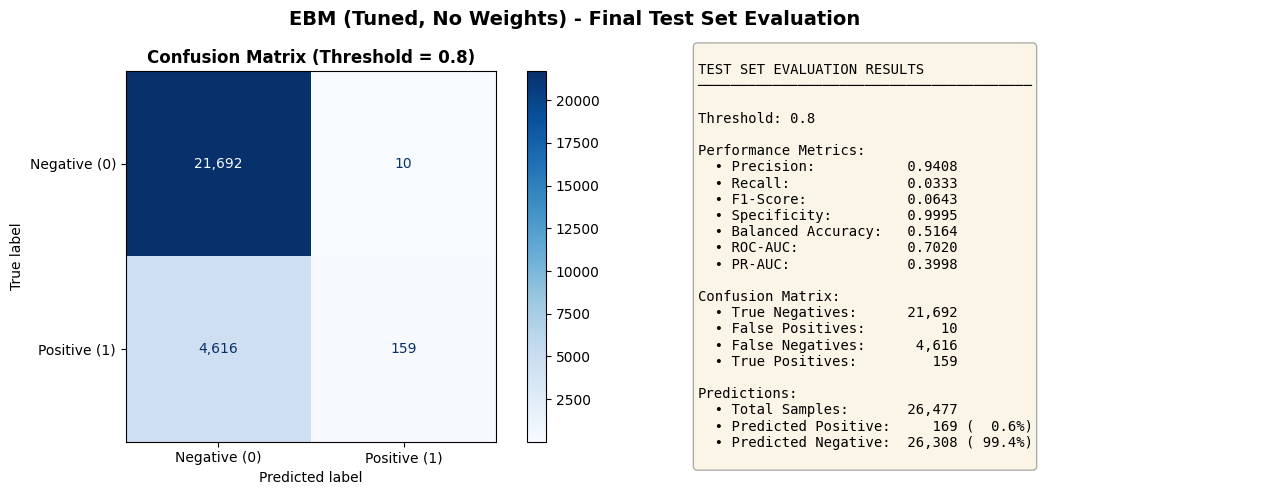


✓ TEST SET EVALUATION COMPLETE


In [5]:
# =============================================================================
# FINAL EVALUATION: EBM (NO WEIGHTS) TUNED MODEL ON TEST SET AT THRESHOLD 0.8
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             classification_report)
import matplotlib.pyplot as plt

print("="*80)
print("FINAL TEST SET EVALUATION: TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8")
print("="*80)

# Load test set
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print(f"\n✓ Test set loaded:")
print(f"  • X_test shape: {X_test.shape}")
print(f"  • y_test shape: {y_test.shape}")
print(f"  • Class distribution: {y_test.value_counts().to_dict()}")

# Get predictions on test set
print(f"\n📊 GENERATING PREDICTIONS ON TEST SET")
print("-" * 80)

test_probas = best_ebm.predict_proba(X_test)[:, 1]
threshold = 0.8
y_pred_test = (test_probas >= threshold).astype(int)

print(f"✓ Predictions generated (threshold = {threshold})")
print(f"  • Predicted positive: {y_pred_test.sum():,} ({100*y_pred_test.sum()/len(y_pred_test):.1f}%)")
print(f"  • Predicted negative: {(1-y_pred_test).sum():,} ({100*(1-y_pred_test).sum()/len(y_pred_test):.1f}%)")

# Calculate metrics
print(f"\n📈 TEST SET METRICS @ THRESHOLD {threshold}")
print("-" * 80)

cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
balanced_accuracy = (recall + specificity) / 2
roc_auc = roc_auc_score(y_test, test_probas)
pr_auc = average_precision_score(y_test, test_probas)

print(f"\n{'Metric':<30} {'Value':>15}")
print("-" * 46)
print(f"{'True Negatives (TN)':<30} {tn:>15,}")
print(f"{'False Positives (FP)':<30} {fp:>15,}")
print(f"{'False Negatives (FN)':<30} {fn:>15,}")
print(f"{'True Positives (TP)':<30} {tp:>15,}")
print("-" * 46)
print(f"{'Precision':<30} {precision:>15.4f}")
print(f"{'Recall (Sensitivity)':<30} {recall:>15.4f}")
print(f"{'Specificity':<30} {specificity:>15.4f}")
print(f"{'F1-Score':<30} {f1:>15.4f}")
print(f"{'Balanced Accuracy':<30} {balanced_accuracy:>15.4f}")
print(f"{'ROC-AUC':<30} {roc_auc:>15.4f}")
print(f"{'PR-AUC':<30} {pr_auc:>15.4f}")

# Classification report
print(f"\n📋 DETAILED CLASSIFICATION REPORT")
print("-" * 80)
print(classification_report(y_test, y_pred_test, target_names=['Class 0', 'Class 1']))

# Confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ax1 = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(ax=ax1, cmap='Blues', values_format=',d')
ax1.set_title(f'Confusion Matrix (Threshold = {threshold})', fontsize=12, fontweight='bold')

# Metrics Summary
ax2 = axes[1]
ax2.axis('off')

metrics_text = f"""
TEST SET EVALUATION RESULTS
{'─' * 40}

Threshold: {threshold}

Performance Metrics:
  • Precision:           {precision:.4f}
  • Recall:              {recall:.4f}
  • F1-Score:            {f1:.4f}
  • Specificity:         {specificity:.4f}
  • Balanced Accuracy:   {balanced_accuracy:.4f}
  • ROC-AUC:             {roc_auc:.4f}
  • PR-AUC:              {pr_auc:.4f}

Confusion Matrix:
  • True Negatives:      {tn:>6,}
  • False Positives:     {fp:>6,}
  • False Negatives:     {fn:>6,}
  • True Positives:      {tp:>6,}

Predictions:
  • Total Samples:       {len(y_test):>6,}
  • Predicted Positive:  {y_pred_test.sum():>6,} ({100*y_pred_test.sum()/len(y_pred_test):>5.1f}%)
  • Predicted Negative:  {(1-y_pred_test).sum():>6,} ({100*(1-y_pred_test).sum()/len(y_pred_test):>5.1f}%)
"""

ax2.text(0.1, 0.5, metrics_text, fontsize=10, family='monospace', 
         verticalalignment='center', transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('EBM (Tuned, No Weights) - Final Test Set Evaluation', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ TEST SET EVALUATION COMPLETE")
print("="*80)


# Comparison: EBM vs Logistic Regression (High Precision Thresholds)

MODEL COMPARISON: TUNED EBM vs LR (BALANCED) - HIGH PRECISION THRESHOLDS

Training LR (Balanced weights) on full training set...
Generating LR predictions on test set...
Training EBM on full training set to get test predictions...
✓ Both models ready for test set evaluation

DETAILED COMPARISON TABLE

Threshold    Model      Precision    Recall       F1-Score         TP     FP     FN      TN
----------------------------------------------------------------------------------------------------
0.6          EBM        0.8139       0.0687       0.1267          328     75   4447   21627
             LR         0.3610       0.4205       0.3885         2008   3555   2767   18147
             Diff       0.4529       -0.3518      -0.2618       EBM ✓   LR ✓   LR ✓
----------------------------------------------------------------------------------------------------
0.7          EBM        0.9057       0.0463       0.0881          221     23   4554   21679
             LR         0.4666       0.2505

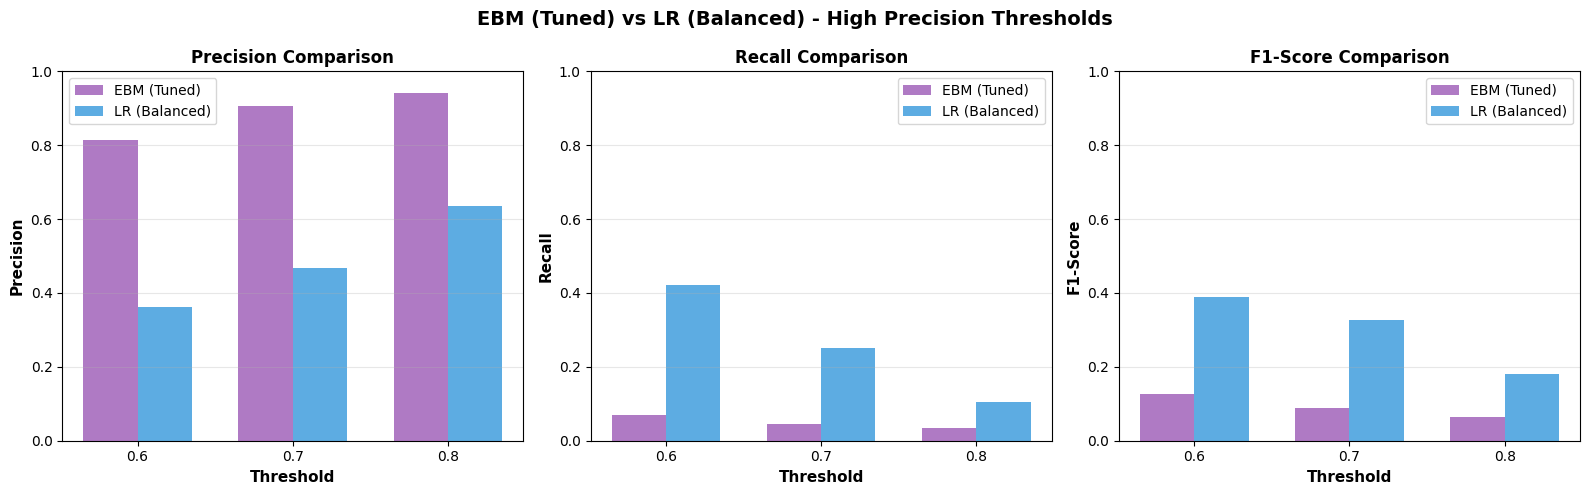


KEY INSIGHTS

🎯 THRESHOLD 0.6:
--------------------------------------------------------------------------------
  ✓ EBM has HIGHER PRECISION:  0.8139 vs 0.3610 (+0.4529)
  ✓ LR has HIGHER RECALL:      0.4205 vs 0.0687 (+0.3518)
  ✓ LR has HIGHER F1-SCORE:    0.3885 vs 0.1267

🎯 THRESHOLD 0.7:
--------------------------------------------------------------------------------
  ✓ EBM has HIGHER PRECISION:  0.9057 vs 0.4666 (+0.4391)
  ✓ LR has HIGHER RECALL:      0.2505 vs 0.0463 (+0.2042)
  ✓ LR has HIGHER F1-SCORE:    0.3260 vs 0.0881

🎯 THRESHOLD 0.8:
--------------------------------------------------------------------------------
  ✓ EBM has HIGHER PRECISION:  0.9408 vs 0.6361 (+0.3047)
  ✓ LR has HIGHER RECALL:      0.1047 vs 0.0333 (+0.0714)
  ✓ LR has HIGHER F1-SCORE:    0.1798 vs 0.0643



In [10]:
# =============================================================================
# COMPARISON: TUNED EBM (NO WEIGHTS) vs LOGISTIC REGRESSION (BALANCED)
# Thresholds: 0.6, 0.7, 0.8
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

print("="*80)
print("MODEL COMPARISON: TUNED EBM vs LR (BALANCED) - HIGH PRECISION THRESHOLDS")
print("="*80)

# Train LR on training set to get test predictions
print("\nTraining LR (Balanced weights) on full training set...")
lr_model = LogisticRegression(
    max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1, class_weight='balanced'
)
lr_model.fit(X_train_final_encoded, y_train)

# Get predictions on test set
print("Generating LR predictions on test set...")
lr_test_probas = lr_model.predict_proba(X_test)[:, 1]

# Get EBM test predictions (train best_ebm on full training set first)
print("Training EBM on full training set to get test predictions...")
best_ebm.fit(X_train_final_encoded, y_train)
ebm_test_probas = best_ebm.predict_proba(X_test)[:, 1]

print("✓ Both models ready for test set evaluation")

# Test set targets
y_test_actual = y_test

# Thresholds to compare
thresholds = [0.6, 0.7, 0.8]

# Evaluate both models
results = []

for thresh in thresholds:
    # EBM predictions
    ebm_pred = (ebm_test_probas >= thresh).astype(int)
    
    # LR predictions
    lr_pred = (lr_test_probas >= thresh).astype(int)
    
    # Calculate metrics
    ebm_prec = precision_score(y_test_actual, ebm_pred, zero_division=0)
    ebm_rec = recall_score(y_test_actual, ebm_pred, zero_division=0)
    ebm_f1 = f1_score(y_test_actual, ebm_pred, zero_division=0)
    
    lr_prec = precision_score(y_test_actual, lr_pred, zero_division=0)
    lr_rec = recall_score(y_test_actual, lr_pred, zero_division=0)
    lr_f1 = f1_score(y_test_actual, lr_pred, zero_division=0)
    
    # Confusion matrices for context
    ebm_cm = confusion_matrix(y_test_actual, ebm_pred)
    lr_cm = confusion_matrix(y_test_actual, lr_pred)
    
    results.append({
        'Threshold': thresh,
        'EBM_Precision': ebm_prec,
        'EBM_Recall': ebm_rec,
        'EBM_F1': ebm_f1,
        'LR_Precision': lr_prec,
        'LR_Recall': lr_rec,
        'LR_F1': lr_f1,
        'EBM_TP': ebm_cm[1, 1],
        'EBM_FP': ebm_cm[0, 1],
        'EBM_FN': ebm_cm[1, 0],
        'EBM_TN': ebm_cm[0, 0],
        'LR_TP': lr_cm[1, 1],
        'LR_FP': lr_cm[0, 1],
        'LR_FN': lr_cm[1, 0],
        'LR_TN': lr_cm[0, 0],
    })

# === PRINT DETAILED COMPARISON ===
print("\n" + "="*80)
print("DETAILED COMPARISON TABLE")
print("="*80)

comparison_df = pd.DataFrame(results)
print(f"\n{'Threshold':<12} {'Model':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>7}")
print("-" * 100)

for _, row in comparison_df.iterrows():
    thresh = row['Threshold']
    
    print(f"{thresh:<12} {'EBM':<10} {row['EBM_Precision']:<12.4f} {row['EBM_Recall']:<12.4f} {row['EBM_F1']:<12.4f} {int(row['EBM_TP']):>6} {int(row['EBM_FP']):>6} {int(row['EBM_FN']):>6} {int(row['EBM_TN']):>7}")
    print(f"{'':12} {'LR':<10} {row['LR_Precision']:<12.4f} {row['LR_Recall']:<12.4f} {row['LR_F1']:<12.4f} {int(row['LR_TP']):>6} {int(row['LR_FP']):>6} {int(row['LR_FN']):>6} {int(row['LR_TN']):>7}")
    
    # Calculate differences
    prec_diff = row['EBM_Precision'] - row['LR_Precision']
    rec_diff = row['EBM_Recall'] - row['LR_Recall']
    f1_diff = row['EBM_F1'] - row['LR_F1']
    
    prec_winner = "EBM ✓" if prec_diff > 0 else "LR ✓" if prec_diff < 0 else "TIE"
    rec_winner = "EBM ✓" if rec_diff > 0 else "LR ✓" if rec_diff < 0 else "TIE"
    f1_winner = "EBM ✓" if f1_diff > 0 else "LR ✓" if f1_diff < 0 else "TIE"
    
    print(f"{'':12} {'Diff':10} {prec_diff:<12.4f} {rec_diff:<12.4f} {f1_diff:<12.4f} {prec_winner:>6} {rec_winner:>6} {f1_winner:>6}")
    print("-" * 100)

# === VISUALIZATION ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Precision Comparison
ax1 = axes[0]
x_pos = np.arange(len(thresholds))
width = 0.35
ax1.bar(x_pos - width/2, comparison_df['EBM_Precision'], width, label='EBM (Tuned)', 
        color='#9b59b6', alpha=0.8)
ax1.bar(x_pos + width/2, comparison_df['LR_Precision'], width, label='LR (Balanced)', 
        color='#3498db', alpha=0.8)
ax1.set_xlabel('Threshold', fontsize=11, fontweight='bold')
ax1.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax1.set_title('Precision Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(thresholds)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1])

# Plot 2: Recall Comparison
ax2 = axes[1]
ax2.bar(x_pos - width/2, comparison_df['EBM_Recall'], width, label='EBM (Tuned)', 
        color='#9b59b6', alpha=0.8)
ax2.bar(x_pos + width/2, comparison_df['LR_Recall'], width, label='LR (Balanced)', 
        color='#3498db', alpha=0.8)
ax2.set_xlabel('Threshold', fontsize=11, fontweight='bold')
ax2.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax2.set_title('Recall Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(thresholds)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1])

# Plot 3: F1-Score Comparison
ax3 = axes[2]
ax3.bar(x_pos - width/2, comparison_df['EBM_F1'], width, label='EBM (Tuned)', 
        color='#9b59b6', alpha=0.8)
ax3.bar(x_pos + width/2, comparison_df['LR_F1'], width, label='LR (Balanced)', 
        color='#3498db', alpha=0.8)
ax3.set_xlabel('Threshold', fontsize=11, fontweight='bold')
ax3.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(thresholds)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0, 1])

fig.suptitle('EBM (Tuned) vs LR (Balanced) - High Precision Thresholds', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === SUMMARY ===
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

for _, row in comparison_df.iterrows():
    thresh = row['Threshold']
    print(f"\n🎯 THRESHOLD {thresh}:")
    print("-" * 80)
    
    if row['EBM_Precision'] > row['LR_Precision']:
        print(f"  ✓ EBM has HIGHER PRECISION:  {row['EBM_Precision']:.4f} vs {row['LR_Precision']:.4f} (+{row['EBM_Precision']-row['LR_Precision']:.4f})")
    else:
        print(f"  ✓ LR has HIGHER PRECISION:   {row['LR_Precision']:.4f} vs {row['EBM_Precision']:.4f} (+{row['LR_Precision']-row['EBM_Precision']:.4f})")
    
    if row['EBM_Recall'] > row['LR_Recall']:
        print(f"  ✓ EBM has HIGHER RECALL:     {row['EBM_Recall']:.4f} vs {row['LR_Recall']:.4f} (+{row['EBM_Recall']-row['LR_Recall']:.4f})")
    else:
        print(f"  ✓ LR has HIGHER RECALL:      {row['LR_Recall']:.4f} vs {row['EBM_Recall']:.4f} (+{row['LR_Recall']-row['EBM_Recall']:.4f})")
    
    if row['EBM_F1'] > row['LR_F1']:
        print(f"  ✓ EBM has HIGHER F1-SCORE:   {row['EBM_F1']:.4f} vs {row['LR_F1']:.4f}")
    else:
        print(f"  ✓ LR has HIGHER F1-SCORE:    {row['LR_F1']:.4f} vs {row['EBM_F1']:.4f}")

print("\n" + "="*80)


# Tuned EBM: Training vs Validation vs Test Performance

TUNED EBM (NO WEIGHTS): TRAIN vs VALIDATION vs TEST PERFORMANCE

📋 STEP 1: EXTRACTING VALIDATION METRICS FROM CROSS-VALIDATION
--------------------------------------------------------------------------------
Computing training metrics on full training set...
✓ Training metrics computed (threshold=0.5)
Computing validation metrics from cross-validation...
✓ Validation metrics computed (5-fold CV, threshold=0.5)
Using test metrics from previous evaluation...
✓ Test metrics computed (threshold=0.5)

COMPREHENSIVE METRICS COMPARISON

Metric                           Training      Validation            Test    Gap (T-V)   Gap (V-Te)
----------------------------------------------------------------------------------------------------
Precision                          0.6714          0.6673          0.6917       0.0041      -0.0244
Recall                             0.0938          0.0942          0.1024      -0.0004      -0.0082
F1-Score                           0.1647          0.1651      

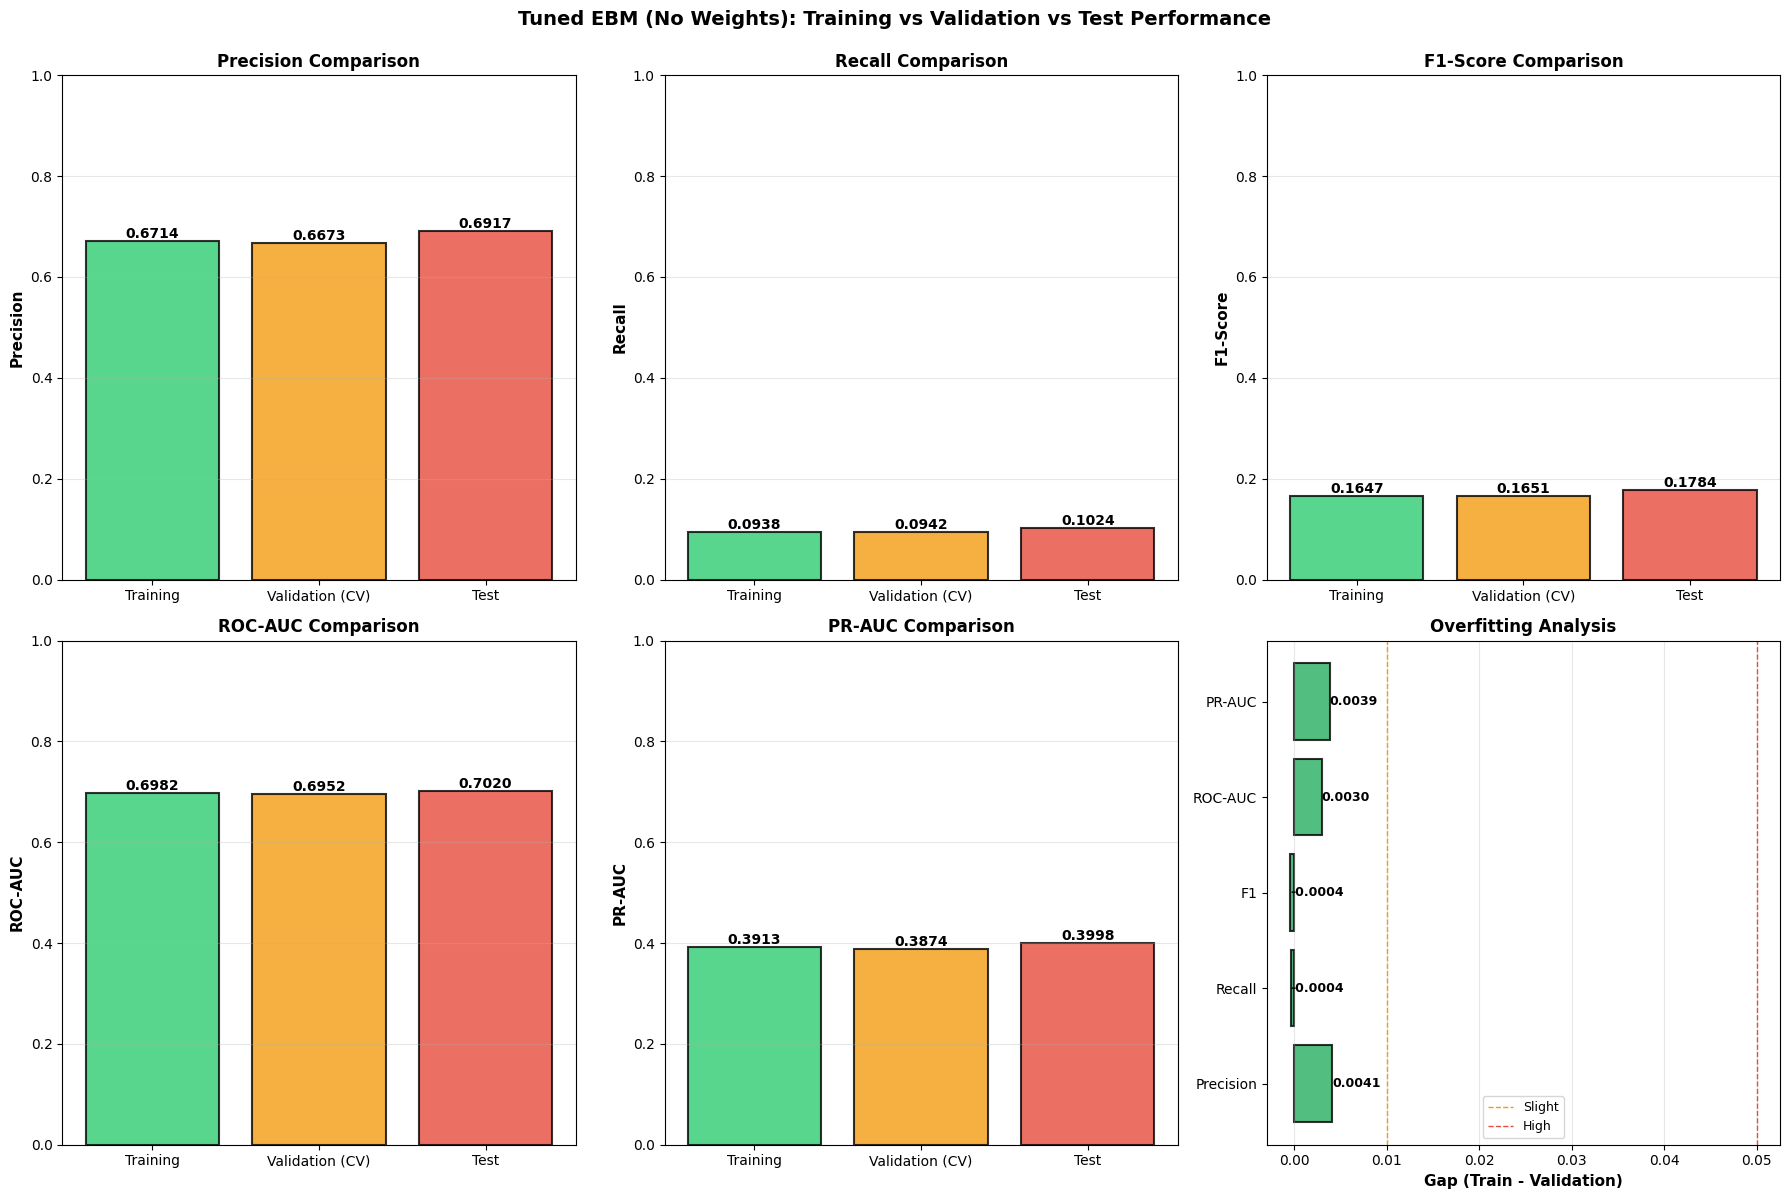


✓ SUMMARY

🎯 MODEL GENERALIZATION:
--------------------------------------------------------------------------------
  Status: ✓ EXCELLENT - Minimal overfitting
  Average gap (Train - Validation): 0.0020

🎯 VALIDATION-TEST ALIGNMENT:
--------------------------------------------------------------------------------
  Status: ✓ REASONABLE - Small difference between validation and test
  Average gap (Validation - Test): -0.0130



In [11]:
# =============================================================================
# TUNED EBM (NO WEIGHTS): TRAINING vs VALIDATION vs TEST COMPARISON
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score,
                             confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import matplotlib.pyplot as plt

print("="*80)
print("TUNED EBM (NO WEIGHTS): TRAIN vs VALIDATION vs TEST PERFORMANCE")
print("="*80)

# === STEP 1: GET VALIDATION METRICS (FROM CROSS-VALIDATION) ===
print("\n📋 STEP 1: EXTRACTING VALIDATION METRICS FROM CROSS-VALIDATION")
print("-" * 80)

# Use the already computed cross-validation predictions
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Recalculate training metrics using best_ebm
print("Computing training metrics on full training set...")
train_probas = best_ebm.predict_proba(X_train_final_encoded)[:, 1]
train_pred = (train_probas >= 0.5).astype(int)

train_precision = precision_score(y_train, train_pred, zero_division=0)
train_recall = recall_score(y_train, train_pred, zero_division=0)
train_f1 = f1_score(y_train, train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, train_probas)
train_pr_auc = average_precision_score(y_train, train_probas)

train_cm = confusion_matrix(y_train, train_pred)
train_tn, train_fp, train_fn, train_tp = train_cm.ravel()

print(f"✓ Training metrics computed (threshold=0.5)")

# Validation metrics (from cross-validation)
print("Computing validation metrics from cross-validation...")
val_probas = cross_val_predict(best_ebm, X_train_final_encoded, y_train, 
                               cv=cv_outer, method='predict_proba')[:, 1]
val_pred = (val_probas >= 0.5).astype(int)

val_precision = precision_score(y_train, val_pred, zero_division=0)
val_recall = recall_score(y_train, val_pred, zero_division=0)
val_f1 = f1_score(y_train, val_pred, zero_division=0)
val_roc_auc = roc_auc_score(y_train, val_probas)
val_pr_auc = average_precision_score(y_train, val_probas)

val_cm = confusion_matrix(y_train, val_pred)
val_tn, val_fp, val_fn, val_tp = val_cm.ravel()

print(f"✓ Validation metrics computed (5-fold CV, threshold=0.5)")

# Test metrics (already computed)
print("Using test metrics from previous evaluation...")
test_probas = ebm_test_probas
test_pred = (test_probas >= 0.5).astype(int)

test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, test_probas)
test_pr_auc = average_precision_score(y_test, test_probas)

test_cm = confusion_matrix(y_test, test_pred)
test_tn, test_fp, test_fn, test_tp = test_cm.ravel()

print(f"✓ Test metrics computed (threshold=0.5)")

# === STEP 2: CREATE COMPARISON TABLE ===
print("\n" + "="*80)
print("COMPREHENSIVE METRICS COMPARISON")
print("="*80)

comparison_data = {
    'Metric': [
        'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC',
        'True Negatives', 'False Positives', 'False Negatives', 'True Positives',
        'Specificity', 'Balanced Accuracy'
    ],
    'Training': [
        train_precision, train_recall, train_f1, train_roc_auc, train_pr_auc,
        train_tn, train_fp, train_fn, train_tp,
        train_tn / (train_tn + train_fp),
        (train_recall + train_tn / (train_tn + train_fp)) / 2
    ],
    'Validation (CV)': [
        val_precision, val_recall, val_f1, val_roc_auc, val_pr_auc,
        val_tn, val_fp, val_fn, val_tp,
        val_tn / (val_tn + val_fp),
        (val_recall + val_tn / (val_tn + val_fp)) / 2
    ],
    'Test': [
        test_precision, test_recall, test_f1, test_roc_auc, test_pr_auc,
        test_tn, test_fp, test_fn, test_tp,
        test_tn / (test_tn + test_fp),
        (test_recall + test_tn / (test_tn + test_fp)) / 2
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Format for display
print(f"\n{'Metric':<25} {'Training':>15} {'Validation':>15} {'Test':>15} {'Gap (T-V)':>12} {'Gap (V-Te)':>12}")
print("-" * 100)

for idx, row in comparison_df.iterrows():
    metric = row['Metric']
    train_val = row['Training']
    val_val = row['Validation (CV)']
    test_val = row['Test']
    
    # Only show gaps for non-count metrics
    if metric not in ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric:<25} {train_val:>15.4f} {val_val:>15.4f} {test_val:>15.4f} {gap_tv:>12.4f} {gap_vt:>12.4f}")
    else:
        print(f"{metric:<25} {int(train_val):>15,} {int(val_val):>15,} {int(test_val):>15,}")

# === STEP 3: OVERFITTING ANALYSIS ===
print("\n" + "="*80)
print("OVERFITTING ANALYSIS (Training vs Validation)")
print("="*80)

metrics_to_check = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
print(f"\n{'Metric':<20} {'Training':>12} {'Validation':>12} {'Gap':>12} {'Status':>15}")
print("-" * 65)

for metric in metrics_to_check:
    row = comparison_df[comparison_df['Metric'] == metric].iloc[0]
    train_v = row['Training']
    val_v = row['Validation (CV)']
    gap = train_v - val_v
    
    # Determine overfitting status
    if gap > 0.05:
        status = "⚠️ Overfitting"
    elif gap > 0.01:
        status = "⚡ Slight OF"
    else:
        status = "✓ Good"
    
    print(f"{metric:<20} {train_v:>12.4f} {val_v:>12.4f} {gap:>12.4f} {status:>15}")

# === STEP 4: GENERALIZATION ANALYSIS ===
print("\n" + "="*80)
print("GENERALIZATION ANALYSIS (Validation vs Test)")
print("="*80)

print(f"\n{'Metric':<20} {'Validation':>12} {'Test':>12} {'Gap':>12} {'Status':>15}")
print("-" * 65)

for metric in metrics_to_check:
    row = comparison_df[comparison_df['Metric'] == metric].iloc[0]
    val_v = row['Validation (CV)']
    test_v = row['Test']
    gap = val_v - test_v
    
    # Determine generalization status (negative gap = worse on test = overgeneralized)
    if gap > 0.05:
        status = "⚠️ Worse on Test"
    elif gap > 0.01:
        status = "⚡ Slight Drop"
    else:
        status = "✓ Stable"
    
    print(f"{metric:<20} {val_v:>12.4f} {test_v:>12.4f} {gap:>12.4f} {status:>15}")

# === STEP 5: VISUALIZATIONS ===
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Precision
ax1 = axes[0, 0]
metrics_plot = ['Training', 'Validation (CV)', 'Test']
precisions = [train_precision, val_precision, test_precision]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = ax1.bar(metrics_plot, precisions, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax1.set_title('Precision Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, precisions):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Recall
ax2 = axes[0, 1]
recalls = [train_recall, val_recall, test_recall]
bars2 = ax2.bar(metrics_plot, recalls, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax2.set_title('Recall Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, recalls):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: F1-Score
ax3 = axes[0, 2]
f1_scores = [train_f1, val_f1, test_f1]
bars3 = ax3.bar(metrics_plot, f1_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, f1_scores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: ROC-AUC
ax4 = axes[1, 0]
roc_aucs = [train_roc_auc, val_roc_auc, test_roc_auc]
bars4 = ax4.bar(metrics_plot, roc_aucs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('ROC-AUC', fontsize=11, fontweight='bold')
ax4.set_title('ROC-AUC Comparison', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, roc_aucs):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 5: PR-AUC
ax5 = axes[1, 1]
pr_aucs = [train_pr_auc, val_pr_auc, test_pr_auc]
bars5 = ax5.bar(metrics_plot, pr_aucs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax5.set_ylabel('PR-AUC', fontsize=11, fontweight='bold')
ax5.set_title('PR-AUC Comparison', fontsize=12, fontweight='bold')
ax5.set_ylim([0, 1])
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, pr_aucs):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 6: Overfitting Gaps
ax6 = axes[1, 2]
gap_train_val = [train_precision - val_precision, 
                  train_recall - val_recall,
                  train_f1 - val_f1,
                  train_roc_auc - val_roc_auc,
                  train_pr_auc - val_pr_auc]
metric_names = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
colors_gap = ['#27ae60' if g < 0.01 else '#f39c12' if g < 0.05 else '#e74c3c' for g in gap_train_val]
bars6 = ax6.barh(metric_names, gap_train_val, color=colors_gap, alpha=0.8, edgecolor='black', linewidth=1.5)
ax6.axvline(x=0.01, color='#f39c12', linestyle='--', linewidth=1, label='Slight')
ax6.axvline(x=0.05, color='#e74c3c', linestyle='--', linewidth=1, label='High')
ax6.set_xlabel('Gap (Train - Validation)', fontsize=11, fontweight='bold')
ax6.set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars6, gap_train_val):
    width = bar.get_width()
    ax6.text(width, bar.get_y() + bar.get_height()/2.,
            f'{val:.4f}', ha='left', va='center', fontweight='bold', fontsize=9)

fig.suptitle('Tuned EBM (No Weights): Training vs Validation vs Test Performance', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# === FINAL SUMMARY ===
print("\n" + "="*80)
print("✓ SUMMARY")
print("="*80)

print(f"\n🎯 MODEL GENERALIZATION:")
print("-" * 80)

overall_gap = np.mean(gap_train_val)
if overall_gap < 0.01:
    generalization = "✓ EXCELLENT - Minimal overfitting"
elif overall_gap < 0.05:
    generalization = "✓ GOOD - Slight overfitting"
else:
    generalization = "⚠️ MODERATE - Some overfitting detected"

print(f"  Status: {generalization}")
print(f"  Average gap (Train - Validation): {overall_gap:.4f}")

val_test_gap = np.mean([val_precision - test_precision,
                        val_recall - test_recall,
                        val_f1 - test_f1,
                        val_roc_auc - test_roc_auc,
                        val_pr_auc - test_pr_auc])

if abs(val_test_gap) < 0.01:
    stability = "✓ STABLE - Validation metrics align with test"
elif abs(val_test_gap) < 0.05:
    stability = "✓ REASONABLE - Small difference between validation and test"
else:
    stability = "⚠️ CAUTION - Notable difference between validation and test"

print(f"\n🎯 VALIDATION-TEST ALIGNMENT:")
print("-" * 80)
print(f"  Status: {stability}")
print(f"  Average gap (Validation - Test): {val_test_gap:.4f}")

print("\n" + "="*80)


# Threshold 0.8: Training vs Validation vs Test Performance

TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8: TRAIN vs VALIDATION vs TEST

📋 STEP 1: COMPUTING METRICS AT THRESHOLD 0.8
--------------------------------------------------------------------------------
Computing training metrics at threshold 0.8...
✓ Training metrics computed (threshold=0.8)
Computing validation metrics at threshold 0.8...
✓ Validation metrics computed (5-fold CV, threshold=0.8)
Computing test metrics at threshold 0.8...
✓ Test metrics computed (threshold=0.8)

COMPREHENSIVE METRICS COMPARISON @ THRESHOLD 0.8

Metric                           Training      Validation            Test    Gap (T-V)   Gap (V-Te)
----------------------------------------------------------------------------------------------------
Precision                          0.9619          0.9571          0.9408       0.0048       0.0163
Recall                             0.0291          0.0292          0.0333      -0.0001      -0.0041
F1-Score                           0.0565          0.0567          0.0643

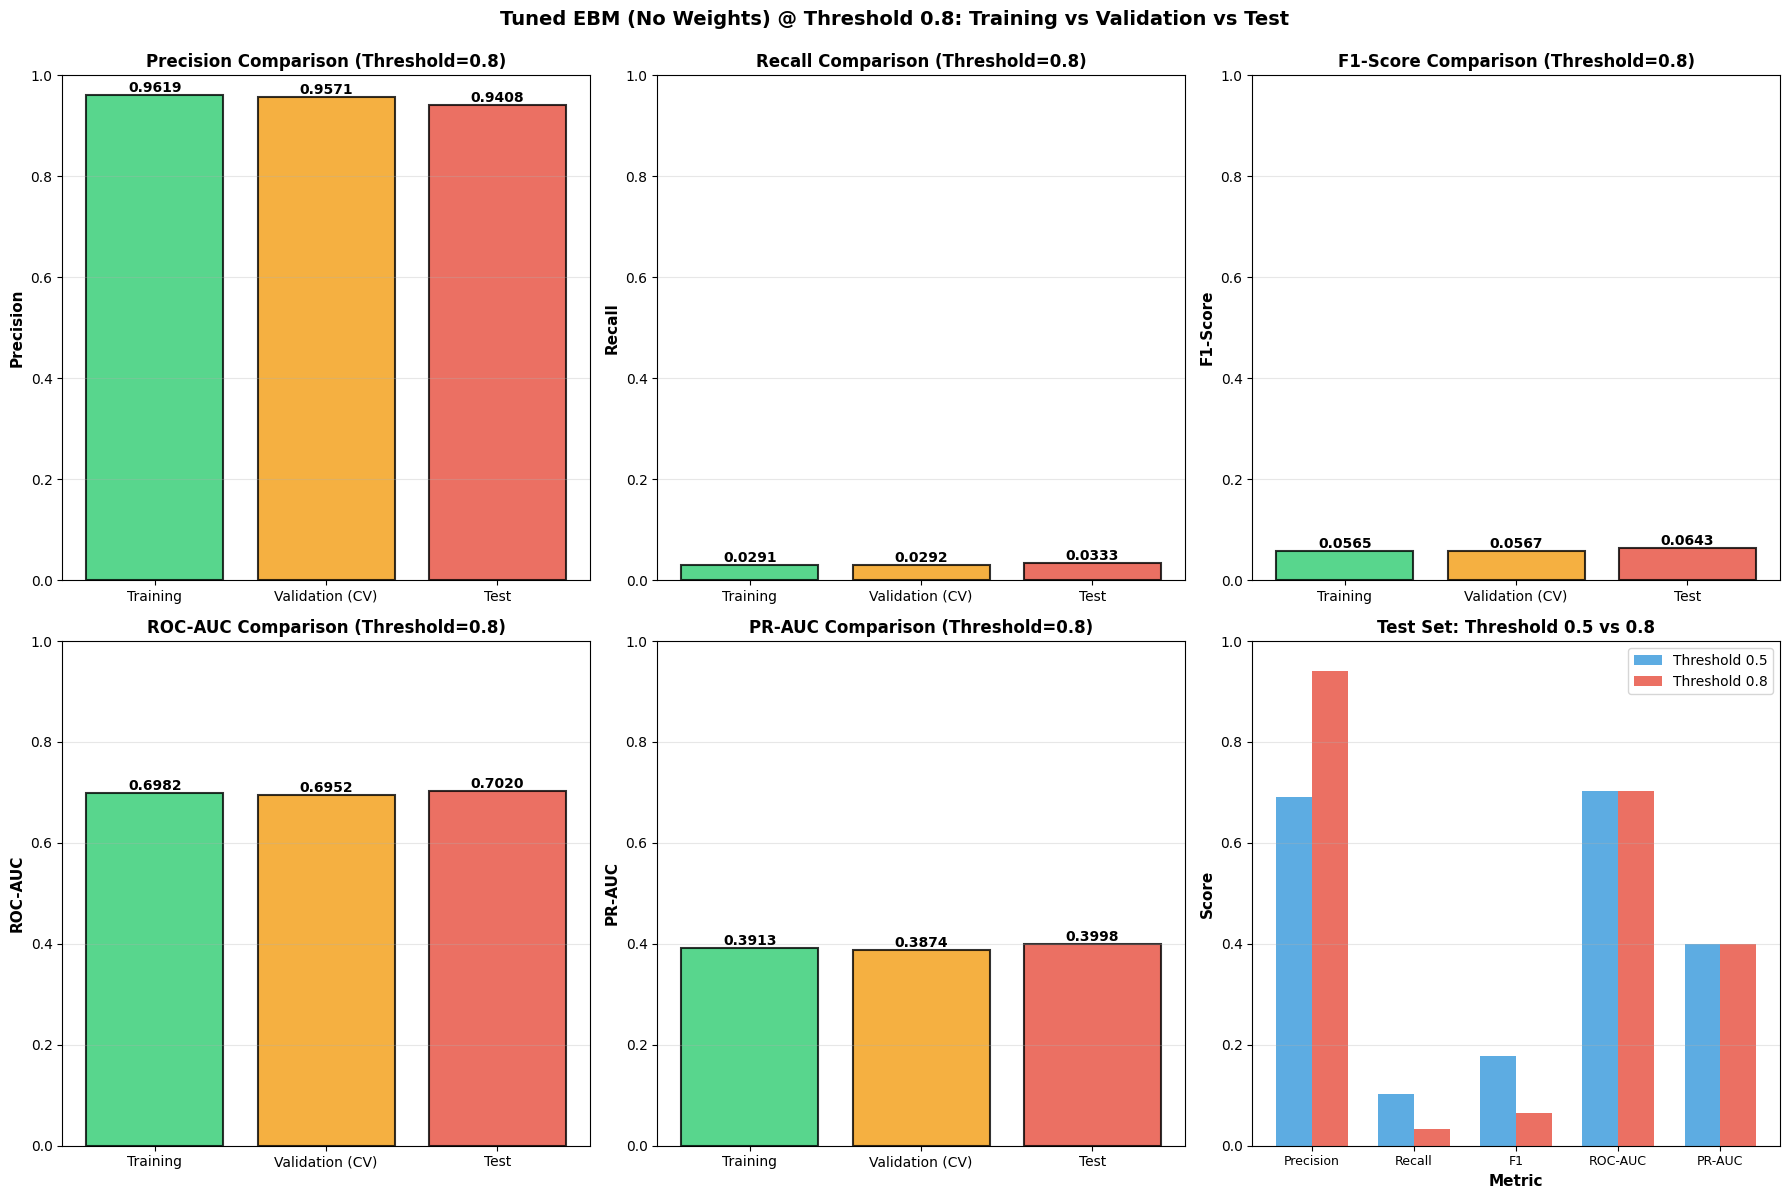


✓ SUMMARY @ THRESHOLD 0.8

🎯 MODEL GENERALIZATION:
--------------------------------------------------------------------------------
  Status: ✓ EXCELLENT - Minimal overfitting
  Average gap (Train - Validation): 0.0023

🎯 VALIDATION-TEST ALIGNMENT:
--------------------------------------------------------------------------------
  Status: ✓ STABLE - Validation metrics align with test
  Average gap (Validation - Test): -0.0029



In [12]:
# =============================================================================
# TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8: TRAINING vs VALIDATION vs TEST
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score,
                             confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import matplotlib.pyplot as plt

print("="*80)
print("TUNED EBM (NO WEIGHTS) @ THRESHOLD 0.8: TRAIN vs VALIDATION vs TEST")
print("="*80)

# === STEP 1: GET METRICS AT THRESHOLD 0.8 ===
print("\n📋 STEP 1: COMPUTING METRICS AT THRESHOLD 0.8")
print("-" * 80)

# Training metrics
print("Computing training metrics at threshold 0.8...")
train_pred_08 = (train_probas >= 0.8).astype(int)

train_precision_08 = precision_score(y_train, train_pred_08, zero_division=0)
train_recall_08 = recall_score(y_train, train_pred_08, zero_division=0)
train_f1_08 = f1_score(y_train, train_pred_08, zero_division=0)
train_roc_auc_08 = roc_auc_score(y_train, train_probas)  # ROC-AUC doesn't depend on threshold
train_pr_auc_08 = average_precision_score(y_train, train_probas)

train_cm_08 = confusion_matrix(y_train, train_pred_08)
train_tn_08, train_fp_08, train_fn_08, train_tp_08 = train_cm_08.ravel()

print(f"✓ Training metrics computed (threshold=0.8)")

# Validation metrics (from cross-validation)
print("Computing validation metrics at threshold 0.8...")
val_pred_08 = (val_probas >= 0.8).astype(int)

val_precision_08 = precision_score(y_train, val_pred_08, zero_division=0)
val_recall_08 = recall_score(y_train, val_pred_08, zero_division=0)
val_f1_08 = f1_score(y_train, val_pred_08, zero_division=0)
val_roc_auc_08 = roc_auc_score(y_train, val_probas)
val_pr_auc_08 = average_precision_score(y_train, val_probas)

val_cm_08 = confusion_matrix(y_train, val_pred_08)
val_tn_08, val_fp_08, val_fn_08, val_tp_08 = val_cm_08.ravel()

print(f"✓ Validation metrics computed (5-fold CV, threshold=0.8)")

# Test metrics
print("Computing test metrics at threshold 0.8...")
test_pred_08 = (test_probas >= 0.8).astype(int)

test_precision_08 = precision_score(y_test, test_pred_08, zero_division=0)
test_recall_08 = recall_score(y_test, test_pred_08, zero_division=0)
test_f1_08 = f1_score(y_test, test_pred_08, zero_division=0)
test_roc_auc_08 = roc_auc_score(y_test, test_probas)
test_pr_auc_08 = average_precision_score(y_test, test_probas)

test_cm_08 = confusion_matrix(y_test, test_pred_08)
test_tn_08, test_fp_08, test_fn_08, test_tp_08 = test_cm_08.ravel()

print(f"✓ Test metrics computed (threshold=0.8)")

# === STEP 2: CREATE COMPARISON TABLE ===
print("\n" + "="*80)
print("COMPREHENSIVE METRICS COMPARISON @ THRESHOLD 0.8")
print("="*80)

comparison_data_08 = {
    'Metric': [
        'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC',
        'True Negatives', 'False Positives', 'False Negatives', 'True Positives',
        'Specificity', 'Balanced Accuracy'
    ],
    'Training': [
        train_precision_08, train_recall_08, train_f1_08, train_roc_auc_08, train_pr_auc_08,
        train_tn_08, train_fp_08, train_fn_08, train_tp_08,
        train_tn_08 / (train_tn_08 + train_fp_08) if (train_tn_08 + train_fp_08) > 0 else 0,
        (train_recall_08 + train_tn_08 / (train_tn_08 + train_fp_08)) / 2 if (train_tn_08 + train_fp_08) > 0 else 0
    ],
    'Validation (CV)': [
        val_precision_08, val_recall_08, val_f1_08, val_roc_auc_08, val_pr_auc_08,
        val_tn_08, val_fp_08, val_fn_08, val_tp_08,
        val_tn_08 / (val_tn_08 + val_fp_08) if (val_tn_08 + val_fp_08) > 0 else 0,
        (val_recall_08 + val_tn_08 / (val_tn_08 + val_fp_08)) / 2 if (val_tn_08 + val_fp_08) > 0 else 0
    ],
    'Test': [
        test_precision_08, test_recall_08, test_f1_08, test_roc_auc_08, test_pr_auc_08,
        test_tn_08, test_fp_08, test_fn_08, test_tp_08,
        test_tn_08 / (test_tn_08 + test_fp_08) if (test_tn_08 + test_fp_08) > 0 else 0,
        (test_recall_08 + test_tn_08 / (test_tn_08 + test_fp_08)) / 2 if (test_tn_08 + test_fp_08) > 0 else 0
    ]
}

comparison_df_08 = pd.DataFrame(comparison_data_08)

# Format for display
print(f"\n{'Metric':<25} {'Training':>15} {'Validation':>15} {'Test':>15} {'Gap (T-V)':>12} {'Gap (V-Te)':>12}")
print("-" * 100)

for idx, row in comparison_df_08.iterrows():
    metric = row['Metric']
    train_val = row['Training']
    val_val = row['Validation (CV)']
    test_val = row['Test']
    
    # Only show gaps for non-count metrics
    if metric not in ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric:<25} {train_val:>15.4f} {val_val:>15.4f} {test_val:>15.4f} {gap_tv:>12.4f} {gap_vt:>12.4f}")
    else:
        print(f"{metric:<25} {int(train_val):>15,} {int(val_val):>15,} {int(test_val):>15,}")

# === STEP 3: SIDE-BY-SIDE COMPARISON (0.5 vs 0.8) ===
print("\n" + "="*80)
print("SIDE-BY-SIDE: THRESHOLD 0.5 vs 0.8 (TEST SET)")
print("="*80)

print(f"\n{'Metric':<20} {'@ Threshold 0.5':>20} {'@ Threshold 0.8':>20} {'Change':>15}")
print("-" * 80)

metrics_compare = [
    ('Precision', test_precision, test_precision_08),
    ('Recall', test_recall, test_recall_08),
    ('F1-Score', test_f1, test_f1_08),
    ('ROC-AUC', test_roc_auc, test_roc_auc_08),
    ('PR-AUC', test_pr_auc, test_pr_auc_08),
]

for metric_name, val_05, val_08 in metrics_compare:
    change = val_08 - val_05
    direction = "↑" if change > 0 else "↓" if change < 0 else "="
    print(f"{metric_name:<20} {val_05:>20.4f} {val_08:>20.4f} {direction} {abs(change):>13.4f}")

# === STEP 4: OVERFITTING ANALYSIS ===
print("\n" + "="*80)
print("OVERFITTING ANALYSIS @ THRESHOLD 0.8 (Training vs Validation)")
print("="*80)

metrics_to_check_08 = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
print(f"\n{'Metric':<20} {'Training':>12} {'Validation':>12} {'Gap':>12} {'Status':>15}")
print("-" * 65)

gap_train_val_08 = []
for metric in metrics_to_check_08:
    row = comparison_df_08[comparison_df_08['Metric'] == metric].iloc[0]
    train_v = row['Training']
    val_v = row['Validation (CV)']
    gap = train_v - val_v
    gap_train_val_08.append(gap)
    
    if gap > 0.05:
        status = "⚠️ Overfitting"
    elif gap > 0.01:
        status = "⚡ Slight OF"
    else:
        status = "✓ Good"
    
    print(f"{metric:<20} {train_v:>12.4f} {val_v:>12.4f} {gap:>12.4f} {status:>15}")

# === STEP 5: VISUALIZATIONS ===
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Precision
ax1 = axes[0, 0]
metrics_plot = ['Training', 'Validation (CV)', 'Test']
precisions_08 = [train_precision_08, val_precision_08, test_precision_08]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = ax1.bar(metrics_plot, precisions_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax1.set_title('Precision Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, precisions_08):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Recall
ax2 = axes[0, 1]
recalls_08 = [train_recall_08, val_recall_08, test_recall_08]
bars2 = ax2.bar(metrics_plot, recalls_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax2.set_title('Recall Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, recalls_08):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: F1-Score
ax3 = axes[0, 2]
f1_scores_08 = [train_f1_08, val_f1_08, test_f1_08]
bars3 = ax3.bar(metrics_plot, f1_scores_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, f1_scores_08):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: ROC-AUC
ax4 = axes[1, 0]
roc_aucs_08 = [train_roc_auc_08, val_roc_auc_08, test_roc_auc_08]
bars4 = ax4.bar(metrics_plot, roc_aucs_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('ROC-AUC', fontsize=11, fontweight='bold')
ax4.set_title('ROC-AUC Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, roc_aucs_08):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 5: PR-AUC
ax5 = axes[1, 1]
pr_aucs_08 = [train_pr_auc_08, val_pr_auc_08, test_pr_auc_08]
bars5 = ax5.bar(metrics_plot, pr_aucs_08, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax5.set_ylabel('PR-AUC', fontsize=11, fontweight='bold')
ax5.set_title('PR-AUC Comparison (Threshold=0.8)', fontsize=12, fontweight='bold')
ax5.set_ylim([0, 1])
ax5.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, pr_aucs_08):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 6: Threshold Comparison (0.5 vs 0.8) on Test Set
ax6 = axes[1, 2]
threshold_labels = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
x_pos_thresh = np.arange(len(threshold_labels))
width_thresh = 0.35

test_metrics_05 = [test_precision, test_recall, test_f1, test_roc_auc, test_pr_auc]
test_metrics_08 = [test_precision_08, test_recall_08, test_f1_08, test_roc_auc_08, test_pr_auc_08]

bars_05 = ax6.bar(x_pos_thresh - width_thresh/2, test_metrics_05, width_thresh, 
                   label='Threshold 0.5', color='#3498db', alpha=0.8)
bars_08 = ax6.bar(x_pos_thresh + width_thresh/2, test_metrics_08, width_thresh, 
                   label='Threshold 0.8', color='#e74c3c', alpha=0.8)

ax6.set_xlabel('Metric', fontsize=11, fontweight='bold')
ax6.set_ylabel('Score', fontsize=11, fontweight='bold')
ax6.set_title('Test Set: Threshold 0.5 vs 0.8', fontsize=12, fontweight='bold')
ax6.set_xticks(x_pos_thresh)
ax6.set_xticklabels(threshold_labels, fontsize=9)
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')
ax6.set_ylim([0, 1])

fig.suptitle('Tuned EBM (No Weights) @ Threshold 0.8: Training vs Validation vs Test', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# === FINAL SUMMARY ===
print("\n" + "="*80)
print("✓ SUMMARY @ THRESHOLD 0.8")
print("="*80)

overall_gap_08 = np.mean(gap_train_val_08)
if overall_gap_08 < 0.01:
    generalization_08 = "✓ EXCELLENT - Minimal overfitting"
elif overall_gap_08 < 0.05:
    generalization_08 = "✓ GOOD - Slight overfitting"
else:
    generalization_08 = "⚠️ MODERATE - Some overfitting detected"

print(f"\n🎯 MODEL GENERALIZATION:")
print("-" * 80)
print(f"  Status: {generalization_08}")
print(f"  Average gap (Train - Validation): {overall_gap_08:.4f}")

val_test_gap_08 = np.mean([val_precision_08 - test_precision_08,
                           val_recall_08 - test_recall_08,
                           val_f1_08 - test_f1_08,
                           val_roc_auc_08 - test_roc_auc_08,
                           val_pr_auc_08 - test_pr_auc_08])

if abs(val_test_gap_08) < 0.01:
    stability_08 = "✓ STABLE - Validation metrics align with test"
elif abs(val_test_gap_08) < 0.05:
    stability_08 = "✓ REASONABLE - Small difference between validation and test"
else:
    stability_08 = "⚠️ CAUTION - Notable difference between validation and test"

print(f"\n🎯 VALIDATION-TEST ALIGNMENT:")
print("-" * 80)
print(f"  Status: {stability_08}")
print(f"  Average gap (Validation - Test): {val_test_gap_08:.4f}")

print("\n" + "="*80)


In [15]:
# =============================================================================
# EXTENDED COMPARISON TABLE: TRAIN vs VALIDATION vs TEST
# Including Specificity, Pred. Pos % of Dataset, and Pred. Pos (ABS)
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score,
                             confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

print("="*100)
print("EXTENDED COMPARISON: TUNED EBM (NO WEIGHTS) - TRAIN vs VALIDATION vs TEST (THRESHOLD 0.8)")
print("="*100)

# === STEP 1: GET VALIDATION METRICS (FROM CROSS-VALIDATION) ===
print("\n📋 STEP 1: COMPUTING METRICS (THRESHOLD 0.8)")
print("-" * 100)

# Training metrics
print("Computing training metrics on full training set...")
train_probas = best_ebm.predict_proba(X_train_final_encoded)[:, 1]
train_pred = (train_probas >= 0.8).astype(int)

train_precision = precision_score(y_train, train_pred, zero_division=0)
train_recall = recall_score(y_train, train_pred, zero_division=0)
train_f1 = f1_score(y_train, train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, train_probas)
train_pr_auc = average_precision_score(y_train, train_probas)

train_cm = confusion_matrix(y_train, train_pred)
train_tn, train_fp, train_fn, train_tp = train_cm.ravel()
train_specificity = train_tn / (train_tn + train_fp) if (train_tn + train_fp) > 0 else 0
train_balanced_acc = (train_recall + train_specificity) / 2

train_pred_pos = train_pred.sum()
train_pred_pos_pct = (train_pred_pos / len(y_train)) * 100

print(f"✓ Training metrics computed (threshold=0.8)")

# Validation metrics (using already computed cross-validated probabilities)
print("Using validation metrics from previously computed cross-validation...")
val_probas = ebm_tuned_probas
val_pred = (val_probas >= 0.8).astype(int)

val_precision = precision_score(y_train, val_pred, zero_division=0)
val_recall = recall_score(y_train, val_pred, zero_division=0)
val_f1 = f1_score(y_train, val_pred, zero_division=0)
val_roc_auc = roc_auc_score(y_train, val_probas)
val_pr_auc = average_precision_score(y_train, val_probas)

val_cm = confusion_matrix(y_train, val_pred)
val_tn, val_fp, val_fn, val_tp = val_cm.ravel()
val_specificity = val_tn / (val_tn + val_fp) if (val_tn + val_fp) > 0 else 0
val_balanced_acc = (val_recall + val_specificity) / 2

val_pred_pos = val_pred.sum()
val_pred_pos_pct = (val_pred_pos / len(y_train)) * 100

print(f"✓ Validation metrics computed (5-fold CV, threshold=0.8)")

# Test metrics
print("Using test metrics from previous evaluation...")
test_probas = loaded_ebm.predict_proba(X_test)[:, 1]
test_pred = (test_probas >= 0.8).astype(int)

test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, test_probas)
test_pr_auc = average_precision_score(y_test, test_probas)

test_cm = confusion_matrix(y_test, test_pred)
test_tn, test_fp, test_fn, test_tp = test_cm.ravel()
test_specificity = test_tn / (test_tn + test_fp) if (test_tn + test_fp) > 0 else 0
test_balanced_acc = (test_recall + test_specificity) / 2

test_pred_pos = test_pred.sum()
test_pred_pos_pct = (test_pred_pos / len(y_test)) * 100

print(f"✓ Test metrics computed (threshold=0.8)")

# === STEP 2: CREATE EXTENDED COMPARISON TABLE ===
print("\n" + "="*100)
print("COMPREHENSIVE METRICS COMPARISON TABLE")
print("="*100)

# Create DataFrame with extended metrics
comparison_data = {
    'Metric': [
        'Precision', 'Recall', 'F1-Score', 'Specificity', 'Balanced Accuracy',
        'ROC-AUC', 'PR-AUC',
        'Pred. Pos (ABS)', 'Pred. Pos % of Dataset'
    ],
    'Training': [
        train_precision, train_recall, train_f1, train_specificity, train_balanced_acc,
        train_roc_auc, train_pr_auc,
        train_pred_pos, train_pred_pos_pct
    ],
    'Validation (CV)': [
        val_precision, val_recall, val_f1, val_specificity, val_balanced_acc,
        val_roc_auc, val_pr_auc,
        val_pred_pos, val_pred_pos_pct
    ],
    'Test': [
        test_precision, test_recall, test_f1, test_specificity, test_balanced_acc,
        test_roc_auc, test_pr_auc,
        test_pred_pos, test_pred_pos_pct
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Display the table with proper formatting
print(f"\n{'Metric':<25} {'Training':>15} {'Validation':>15} {'Test':>15} {'Gap (T-V)':>12} {'Gap (V-Te)':>12}")
print("-" * 110)

for idx, row in comparison_df.iterrows():
    metric = row['Metric']
    train_val = row['Training']
    val_val = row['Validation (CV)']
    test_val = row['Test']
    
    # Different formatting for count vs percentage metrics
    if metric in ['Pred. Pos (ABS)']:
        print(f"{metric:<25} {int(train_val):>15,} {int(val_val):>15,} {int(test_val):>15,}")
    elif metric in ['Pred. Pos % of Dataset']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric:<25} {train_val:>14.2f}% {val_val:>14.2f}% {test_val:>14.2f}% {gap_tv:>11.2f}% {gap_vt:>11.2f}%")
    else:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric:<25} {train_val:>15.4f} {val_val:>15.4f} {test_val:>15.4f} {gap_tv:>12.4f} {gap_vt:>12.4f}")

print("-" * 110)

# === STEP 3: SUMMARY STATISTICS ===
print("\n" + "="*100)
print("KEY INSIGHTS")
print("="*100)

print(f"\n📊 PREDICTION DISTRIBUTION (Threshold 0.8):")
print("-" * 100)
print(f"Training Set:")
print(f"  • Predicted Positive: {train_pred_pos:>10,} ({train_pred_pos_pct:>6.2f}%)")
print(f"  • Predicted Negative: {len(y_train) - train_pred_pos:>10,} ({100 - train_pred_pos_pct:>6.2f}%)")

print(f"\nValidation Set (5-fold CV):")
print(f"  • Predicted Positive: {val_pred_pos:>10,} ({val_pred_pos_pct:>6.2f}%)")
print(f"  • Predicted Negative: {len(y_train) - val_pred_pos:>10,} ({100 - val_pred_pos_pct:>6.2f}%)")

print(f"\nTest Set:")
print(f"  • Predicted Positive: {test_pred_pos:>10,} ({test_pred_pos_pct:>6.2f}%)")
print(f"  • Predicted Negative: {len(y_test) - test_pred_pos:>10,} ({100 - test_pred_pos_pct:>6.2f}%)")

print(f"\n📈 SPECIFICITY ANALYSIS:")
print("-" * 100)
print(f"{'Set':<20} {'Specificity':>15} {'True Negatives':>20} {'False Positives':>20}")
print(f"{'Training':<20} {train_specificity:>15.4f} {train_tn:>20,} {train_fp:>20,}")
print(f"{'Validation (CV)':<20} {val_specificity:>15.4f} {val_tn:>20,} {val_fp:>20,}")
print(f"{'Test':<20} {test_specificity:>15.4f} {test_tn:>20,} {test_fp:>20,}")

print("\n" + "="*100)
print("✓ EXTENDED COMPARISON TABLE COMPLETE")
print("="*100)


EXTENDED COMPARISON: TUNED EBM (NO WEIGHTS) - TRAIN vs VALIDATION vs TEST (THRESHOLD 0.8)

📋 STEP 1: COMPUTING METRICS (THRESHOLD 0.8)
----------------------------------------------------------------------------------------------------
Computing training metrics on full training set...
✓ Training metrics computed (threshold=0.8)
Using validation metrics from previously computed cross-validation...
✓ Validation metrics computed (5-fold CV, threshold=0.8)
Using test metrics from previous evaluation...
✓ Test metrics computed (threshold=0.8)

COMPREHENSIVE METRICS COMPARISON TABLE

Metric                           Training      Validation            Test    Gap (T-V)   Gap (V-Te)
--------------------------------------------------------------------------------------------------------------
Precision                          0.9619          0.9571          0.9408       0.0048       0.0163
Recall                             0.0291          0.0292          0.0333      -0.0001      -0.0041
F1-

In [16]:
# =============================================================================
# WORD-FRIENDLY EXPORT: EXTENDED COMPARISON TABLE (THRESHOLD 0.8)
# =============================================================================

print("\n" + "="*110)
print("WORD-FRIENDLY EXPORT: Extended Comparison Table (Threshold 0.8)")
print("="*110)

print("\n1️⃣  TAB-SEPARATED FORMAT (Copy & paste into Word, then use Table > Convert > Text to Table):\n")

# Create tab-separated version
print("Metric\tTraining\tValidation\tTest\tGap (T-V)\tGap (V-Te)")

metrics_list = [
    ('Precision', train_precision, val_precision, test_precision),
    ('Recall', train_recall, val_recall, test_recall),
    ('F1-Score', train_f1, val_f1, test_f1),
    ('Specificity', train_specificity, val_specificity, test_specificity),
    ('Balanced Accuracy', train_balanced_acc, val_balanced_acc, test_balanced_acc),
    ('ROC-AUC', train_roc_auc, val_roc_auc, test_roc_auc),
    ('PR-AUC', train_pr_auc, val_pr_auc, test_pr_auc),
    ('Pred. Pos (ABS)', train_pred_pos, val_pred_pos, test_pred_pos),
    ('Pred. Pos % of Dataset', train_pred_pos_pct, val_pred_pos_pct, test_pred_pos_pct),
]

for metric_name, train_val, val_val, test_val in metrics_list:
    if metric_name in ['Pred. Pos (ABS)']:
        print(f"{metric_name}\t{int(train_val)}\t{int(val_val)}\t{int(test_val)}")
    elif metric_name in ['Pred. Pos % of Dataset']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric_name}\t{train_val:.2f}%\t{val_val:.2f}%\t{test_val:.2f}%\t{gap_tv:.2f}%\t{gap_vt:.2f}%")
    else:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"{metric_name}\t{train_val:.4f}\t{val_val:.4f}\t{test_val:.4f}\t{gap_tv:.4f}\t{gap_vt:.4f}")

print("\n" + "="*110)
print("\n2️⃣  MARKDOWN FORMAT (for documentation):\n")

print("| Metric | Training | Validation | Test | Gap (T-V) | Gap (V-Te) |")
print("|--------|----------|-----------|------|-----------|-----------|")

for metric_name, train_val, val_val, test_val in metrics_list:
    if metric_name in ['Pred. Pos (ABS)']:
        print(f"| {metric_name} | {int(train_val):,} | {int(val_val):,} | {int(test_val):,} | - | - |")
    elif metric_name in ['Pred. Pos % of Dataset']:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"| {metric_name} | {train_val:.2f}% | {val_val:.2f}% | {test_val:.2f}% | {gap_tv:.2f}% | {gap_vt:.2f}% |")
    else:
        gap_tv = train_val - val_val
        gap_vt = val_val - test_val
        print(f"| {metric_name} | {train_val:.4f} | {val_val:.4f} | {test_val:.4f} | {gap_tv:.4f} | {gap_vt:.4f} |")

print("\n" + "="*110)
print("✓ WORD-FRIENDLY FORMATS READY FOR COPY-PASTE")
print("="*110)



WORD-FRIENDLY EXPORT: Extended Comparison Table (Threshold 0.8)

1️⃣  TAB-SEPARATED FORMAT (Copy & paste into Word, then use Table > Convert > Text to Table):

Metric	Training	Validation	Test	Gap (T-V)	Gap (V-Te)
Precision	0.9619	0.9571	0.9408	0.0048	0.0163
Recall	0.0291	0.0292	0.0333	-0.0001	-0.0041
F1-Score	0.0565	0.0567	0.0643	-0.0002	-0.0076
Specificity	0.9997	0.9997	0.9995	0.0000	0.0002
Balanced Accuracy	0.5144	0.5145	0.5164	-0.0000	-0.0020
ROC-AUC	0.6982	0.6952	0.7020	0.0030	-0.0068
PR-AUC	0.3913	0.3874	0.3998	0.0039	-0.0124
Pred. Pos (ABS)	578	583	169
Pred. Pos % of Dataset	0.55%	0.55%	0.64%	-0.00%	-0.09%


2️⃣  MARKDOWN FORMAT (for documentation):

| Metric | Training | Validation | Test | Gap (T-V) | Gap (V-Te) |
|--------|----------|-----------|------|-----------|-----------|
| Precision | 0.9619 | 0.9571 | 0.9408 | 0.0048 | 0.0163 |
| Recall | 0.0291 | 0.0292 | 0.0333 | -0.0001 | -0.0041 |
| F1-Score | 0.0565 | 0.0567 | 0.0643 | -0.0002 | -0.0076 |
| Specificity | 0.9997 | 

CONFUSION MATRIX: EBM MODEL ON TEST SET (THRESHOLD 0.8)

📊 CONFUSION MATRIX BREAKDOWN:
--------------------------------------------------------------------------------
True Negatives (TN):      21,692  |  Correctly predicted negative cases
False Positives (FP):         10  |  Incorrectly predicted as positive
False Negatives (FN):      4,616  |  Incorrectly predicted as negative
True Positives (TP):         159  |  Correctly predicted positive cases
--------------------------------------------------------------------------------
Total Test Samples:       26,477

📈 PERFORMANCE METRICS (THRESHOLD 0.8):
--------------------------------------------------------------------------------
Precision..................... 0.9408  (TP / (TP + FP))
Recall (Sensitivity).......... 0.0333  (TP / (TP + FN))
Specificity................... 0.9995  (TN / (TN + FP))
F1-Score...................... 0.0643  (Harmonic mean of precision & recall)
Balanced Accuracy............. 0.5164  (Average of sensitivity & s

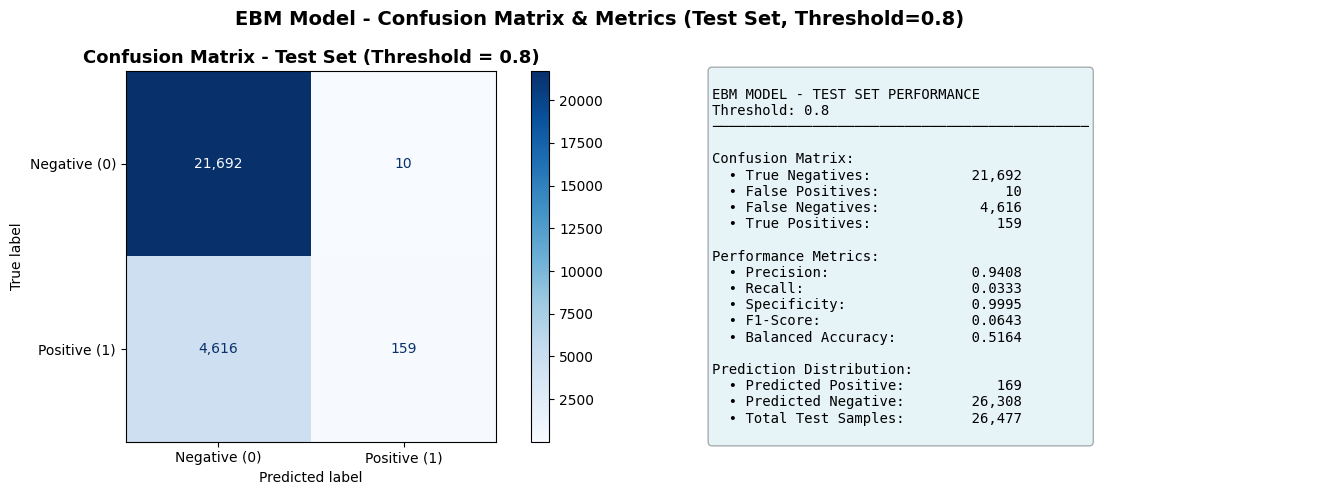


✓ CONFUSION MATRIX ANALYSIS COMPLETE


In [17]:
# =============================================================================
# CONFUSION MATRIX: EBM MODEL ON TEST SET (THRESHOLD 0.8)
# =============================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

print("="*80)
print("CONFUSION MATRIX: EBM MODEL ON TEST SET (THRESHOLD 0.8)")
print("="*80)

# Generate predictions at threshold 0.8
threshold_08 = 0.8
test_probas_08 = loaded_ebm.predict_proba(X_test)[:, 1]
test_pred_08 = (test_probas_08 >= threshold_08).astype(int)

# Calculate confusion matrix
cm_test_08 = confusion_matrix(y_test, test_pred_08)
tn_08, fp_08, fn_08, tp_08 = cm_test_08.ravel()

# Calculate metrics
precision_08 = tp_08 / (tp_08 + fp_08) if (tp_08 + fp_08) > 0 else 0
recall_08 = tp_08 / (tp_08 + fn_08) if (tp_08 + fn_08) > 0 else 0
f1_08 = 2 * precision_08 * recall_08 / (precision_08 + recall_08) if (precision_08 + recall_08) > 0 else 0
specificity_08 = tn_08 / (tn_08 + fp_08) if (tn_08 + fp_08) > 0 else 0
balanced_acc_08 = (recall_08 + specificity_08) / 2

print("\n📊 CONFUSION MATRIX BREAKDOWN:")
print("-" * 80)
print(f"True Negatives (TN):  {tn_08:>10,}  |  Correctly predicted negative cases")
print(f"False Positives (FP): {fp_08:>10,}  |  Incorrectly predicted as positive")
print(f"False Negatives (FN): {fn_08:>10,}  |  Incorrectly predicted as negative")
print(f"True Positives (TP):  {tp_08:>10,}  |  Correctly predicted positive cases")
print("-" * 80)
print(f"Total Test Samples:   {len(y_test):>10,}")

print("\n📈 PERFORMANCE METRICS (THRESHOLD 0.8):")
print("-" * 80)
print(f"{'Precision':.<30} {precision_08:.4f}  (TP / (TP + FP))")
print(f"{'Recall (Sensitivity)':.<30} {recall_08:.4f}  (TP / (TP + FN))")
print(f"{'Specificity':.<30} {specificity_08:.4f}  (TN / (TN + FP))")
print(f"{'F1-Score':.<30} {f1_08:.4f}  (Harmonic mean of precision & recall)")
print(f"{'Balanced Accuracy':.<30} {balanced_acc_08:.4f}  (Average of sensitivity & specificity)")

print("\n📋 CLASSIFICATION REPORT:")
print("-" * 80)
print(classification_report(y_test, test_pred_08, target_names=['Negative (0)', 'Positive (1)']))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Confusion Matrix Heatmap
ax1 = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_08, 
                              display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(ax=ax1, cmap='Blues', values_format=',d')
ax1.set_title('Confusion Matrix - Test Set (Threshold = 0.8)', fontsize=13, fontweight='bold')

# Plot 2: Metrics Summary
ax2 = axes[1]
ax2.axis('off')

metrics_summary = f"""
EBM MODEL - TEST SET PERFORMANCE
Threshold: 0.8
{'─' * 45}

Confusion Matrix:
  • True Negatives:        {tn_08:>10,}
  • False Positives:       {fp_08:>10,}
  • False Negatives:       {fn_08:>10,}
  • True Positives:        {tp_08:>10,}

Performance Metrics:
  • Precision:             {precision_08:>10.4f}
  • Recall:                {recall_08:>10.4f}
  • Specificity:           {specificity_08:>10.4f}
  • F1-Score:              {f1_08:>10.4f}
  • Balanced Accuracy:     {balanced_acc_08:>10.4f}

Prediction Distribution:
  • Predicted Positive:    {test_pred_08.sum():>10,}
  • Predicted Negative:    {(1-test_pred_08).sum():>10,}
  • Total Test Samples:    {len(y_test):>10,}
"""

ax2.text(0.1, 0.5, metrics_summary, fontsize=10, family='monospace',
         verticalalignment='center', transform=ax2.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

fig.suptitle('EBM Model - Confusion Matrix & Metrics (Test Set, Threshold=0.8)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ CONFUSION MATRIX ANALYSIS COMPLETE")
print("="*80)
